# EEG_16b — Subject Clustering v2: P022 rimosso, k=2 forzato

**Differenze rispetto a EEG_16**:
- **P022 escluso** (era singleton outlier in k=3 — distorce il clustering)
- **k=2 forzato** (confronto pulito C0 vs C1 sui 73 soggetti rimanenti)
- **§2 NUOVO**: perché P022 è un outlier (posizione PCA, distanza dai cluster, fingerprint feature)
- **§9 NUOVO**: PCA loadings → quali connessioni electrode-pair guidano la separazione C0/C1
- **§10 NUOVO**: mappa differenza aggregata per elettrodo → quale regione cerebrale distingue i due cluster

**Domanda scientifica**: perché i soggetti si dividono in due cluster distinti?
Cosa c'è di diverso nella topografia di connettività di C0 vs C1?

In [1]:
import json, logging, math, re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.stats import mannwhitneyu
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s %(levelname)-8s %(message)s',
                    datefmt='%H:%M:%S')
log = logging.getLogger('eeg16b')

project_root = next((p for p in [Path.cwd()] + list(Path.cwd().parents)
                     if (p / '.git').exists()), Path.cwd())
FIG_DIR  = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)
# Ckpt dir separato da eeg16 per non sovrascrivere cache esistente
CKPT_DIR = project_root / 'models' / 'eeg16'; CKPT_DIR.mkdir(parents=True, exist_ok=True)

ACC_FILE_12 = project_root / 'figures' / 'eeg12_subject_ranking.csv'
ACC_FILE_13 = project_root / 'figures' / 'eeg13b_subject_ranking.csv'

METRIC       = 'abs_pcc'
N_CHAN       = 61
N_TRIU       = N_CHAN * (N_CHAN - 1) // 2   # 1830
K_FORCED     = 2          # k=2 forzato — no grid search
EXCLUDE_SUBJ = [22, 23]   # P022/P023: segnali sporchi, esclusi
RANDOM_SEED  = 42

log.info(f'project_root = {project_root}')
log.info(f'Metrica: {METRIC} | N_TRIU: {N_TRIU} | k forzato: {K_FORCED}')
log.info(f'Soggetti esclusi: {[f"P{s:03d}" for s in EXCLUDE_SUBJ]}')

21:06:21 INFO     project_root = /home/daniele_u/miralis-hypergraph-imagined-speech
21:06:21 INFO     Metrica: abs_pcc | N_TRIU: 1830 | k forzato: 2
21:06:21 INFO     Soggetti esclusi: ['P022', 'P023']


## §1 — Caricamento feature per soggetto

Carica le cache già prodotte da EEG_16 (stessi file `.npz`).
Poi filtra P022 e tutti i soggetti in `EXCLUDE_SUBJ`.

In [2]:
_PAT = re.compile(r'^P(\d+)_S(\d+)$')

def build_index(metric):
    root = project_root / 'data' / f'hypergraphs_pruned_{metric}'
    idx  = defaultdict(list)
    if not root.exists():
        log.warning(f'Directory non trovata: {root}')
        return idx
    for p in sorted(root.rglob('trial_*.pt')):
        m = _PAT.match(p.parent.name)
        if m:
            idx[int(m.group(1))].append(p)
    return idx

IDX      = build_index(METRIC)
ALL_SUBJ = sorted(IDX.keys())

GRAPH_CACHE = CKPT_DIR / f'feat_graph_{METRIC}.npz'
HG_CACHE    = CKPT_DIR / f'feat_hg_{METRIC}.npz'
triu_idx    = np.triu_indices(N_CHAN, k=1)

# ── Carica cache (prodotta da eeg16) ─────────────────────────────────────────
assert GRAPH_CACHE.exists() and HG_CACHE.exists(), \
    "Cache non trovata — esegui prima EEG_16 per produrre feat_graph_abs_pcc.npz e feat_hg_abs_pcc.npz"

_g = np.load(GRAPH_CACHE); FEAT_G_ALL = _g['feats']; SUBJ_G_ALL = _g['subj_ids'].tolist()
_h = np.load(HG_CACHE);    FEAT_H_ALL = _h['feats']; SUBJ_H_ALL = _h['subj_ids'].tolist()
log.info(f'Cache caricata — Grafi: {FEAT_G_ALL.shape}  Ipergrafi: {FEAT_H_ALL.shape}')

# ── Salva versione COMPLETA per analisi outlier §2 ─────────────────────────
FEAT_G_FULL = FEAT_G_ALL.copy()
SUBJ_G_FULL = SUBJ_G_ALL.copy()
FEAT_H_FULL = FEAT_H_ALL.copy()
SUBJ_H_FULL = SUBJ_H_ALL.copy()

# ── Filtra soggetti esclusi ───────────────────────────────────────────────────
def filter_subj(feats, subj_ids, exclude):
    keep = [i for i, s in enumerate(subj_ids) if s not in exclude]
    return feats[keep], [subj_ids[i] for i in keep]

FEAT_G, SUBJ_G = filter_subj(FEAT_G_ALL, SUBJ_G_ALL, EXCLUDE_SUBJ)
FEAT_H, SUBJ_H = filter_subj(FEAT_H_ALL, SUBJ_H_ALL, EXCLUDE_SUBJ)
log.info(f'Dopo esclusione P022 — Grafi: {FEAT_G.shape} ({len(SUBJ_G)} soggetti)')
log.info(f'Dopo esclusione P022 — Ipergrafi: {FEAT_H.shape} ({len(SUBJ_H)} soggetti)')

21:06:21 INFO     Cache caricata — Grafi: (91, 1830)  Ipergrafi: (91, 1830)
21:06:21 INFO     Dopo esclusione P022 — Grafi: (89, 1830) (89 soggetti)
21:06:21 INFO     Dopo esclusione P022 — Ipergrafi: (89, 1830) (89 soggetti)


In [3]:
# CHAN_NAMES definito qui (era usato prima della sua definizione piu in basso)
CHAN_NAMES = ['A1','AF7','AF3','Fp1','Fp2','AF4','AF8',
              'A2','F7','F5','F3','F1','Fz','F2','F4','F6','F8',
              'FT7','FC5','FC3','FC1','FCz','FC2','FC4','FC6','FT8',
              'T7','C5','C3','C1','Cz','C2','C4','C6','T8',
              'TP7','CP5','CP3','CP1','CPz','CP2','CP4','CP6','TP8',
              'P7','P5','P3','P1','Pz','P2','P4','P6','P8',
              'PO7','PO5','PO3','POz','PO4','PO6','PO8',
              'O1','Oz','O2','CPz'][:N_CHAN]

# Salva FEAT_G + CHAN_NAMES per EEG_20
save_path = project_root / 'models' / 'eeg16b' / 'feat_graph_abs_pcc.npz'
save_path.parent.mkdir(parents=True, exist_ok=True)
np.savez(save_path,
         feat=FEAT_G,
         subj_ids=np.array(SUBJ_H),
         chan_names=np.array(CHAN_NAMES))
print(f'Salvato: {save_path}')
print(f'Shape: {FEAT_G.shape}  Soggetti: {len(SUBJ_H)}  Canali: {len(CHAN_NAMES)}')

Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/models/eeg16b/feat_graph_abs_pcc.npz
Shape: (89, 1830)  Soggetti: 89  Canali: 61


## §2 — Perché P022 è un outlier?

Prima di escluderlo, capire cosa lo rende anomalo:
- **Posizione nello spazio PCA** su tutti e 74 i soggetti
- **Distanza euclidea** di P022 dai due cluster principali
- **Feature fingerprint**: confronto vettore P022 vs media C0 e media C1 nei 1830 feature (top deviazioni)

21:06:21 INFO     P022 — cluster assegnato: C0
21:06:21 INFO     P022 — distanza da C0: 117.244  da C1: 123.250
21:06:21 INFO     P022 — distanza dal proprio centroide: 117.244  (percentile 99th)


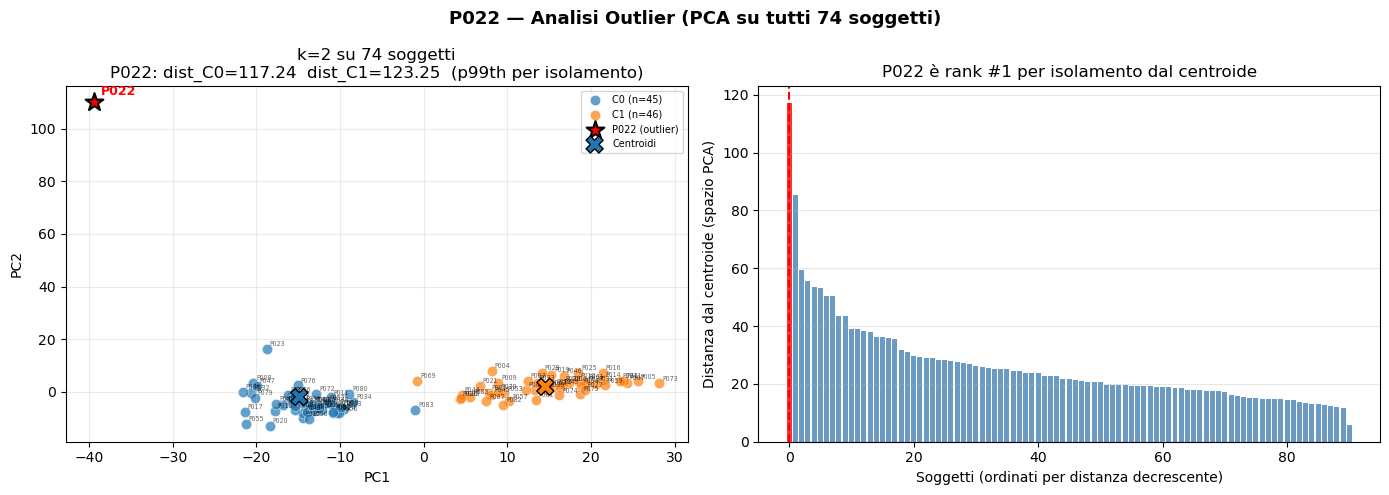

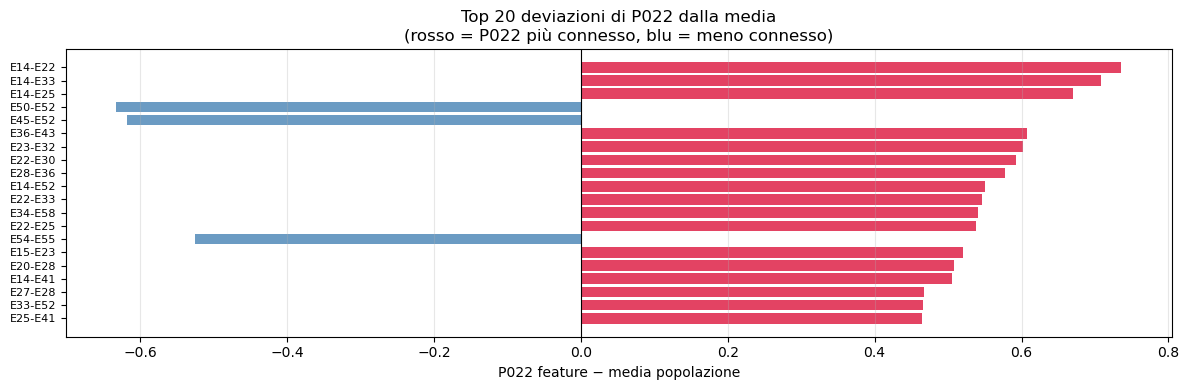


P022 si discosta dalla media su 299 / 1830 feature
Max deviazione: 0.7358  Min: -0.6322


In [4]:
# ── PCA su tutti e 74 soggetti ────────────────────────────────────────────────
scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(FEAT_G_FULL)
pca_full = PCA(n_components=min(20, len(SUBJ_G_FULL) - 1), random_state=RANDOM_SEED)
Z_full = pca_full.fit_transform(X_full)

# Cluster k=2 su tutti 74 per trovare a quale cluster "apparterrebbe" P022
km_full = KMeans(n_clusters=2, n_init=30, random_state=RANDOM_SEED)
labels_full = km_full.fit_predict(Z_full)

# Indice di P022
p022_idx = SUBJ_G_FULL.index(22)
p022_z   = Z_full[p022_idx]

# Distanza di P022 dai due centroidi
dist_c0 = np.linalg.norm(p022_z - km_full.cluster_centers_[0])
dist_c1 = np.linalg.norm(p022_z - km_full.cluster_centers_[1])

# Distanza di ogni soggetto dal proprio centroide
own_dists = np.array([
    np.linalg.norm(Z_full[i] - km_full.cluster_centers_[labels_full[i]])
    for i in range(len(SUBJ_G_FULL))
])
p022_own_dist = own_dists[p022_idx]
percentile_p022 = (own_dists < p022_own_dist).mean() * 100

log.info(f'P022 — cluster assegnato: C{labels_full[p022_idx]}')
log.info(f'P022 — distanza da C0: {dist_c0:.3f}  da C1: {dist_c1:.3f}')
log.info(f'P022 — distanza dal proprio centroide: {p022_own_dist:.3f}  (percentile {percentile_p022:.0f}th)')

# ── Plot 1: PCA 2D tutti 74, P022 evidenziato ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('P022 — Analisi Outlier (PCA su tutti 74 soggetti)', fontsize=13, fontweight='bold')

ax = axes[0]
pal2 = plt.cm.tab10([0, 0.1])
for c in [0, 1]:
    mask = labels_full == c
    ax.scatter(Z_full[mask, 0], Z_full[mask, 1],
               color=pal2[c], s=55, alpha=0.7, label=f'C{c} (n={mask.sum()})',
               edgecolors='white', linewidths=0.4)
    for i in np.where(mask)[0]:
        if SUBJ_G_FULL[i] != 22:
            ax.annotate(f'P{SUBJ_G_FULL[i]:03d}', (Z_full[i, 0], Z_full[i, 1]),
                        fontsize=4.5, xytext=(2, 2), textcoords='offset points', alpha=0.6)
# Evidenzia P022
ax.scatter(p022_z[0], p022_z[1], color='red', s=180, zorder=5,
           edgecolors='black', linewidths=1.5, marker='*', label='P022 (outlier)')
ax.annotate('P022', (p022_z[0], p022_z[1]), fontsize=9, fontweight='bold',
            color='red', xytext=(5, 5), textcoords='offset points')
# Centroidi
ax.scatter(km_full.cluster_centers_[:, 0], km_full.cluster_centers_[:, 1],
           marker='X', s=150, color=['tab:blue', 'tab:orange'], edgecolors='black',
           linewidths=1, zorder=6, label='Centroidi')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'k=2 su 74 soggetti\nP022: dist_C0={dist_c0:.2f}  dist_C1={dist_c1:.2f}  (p{percentile_p022:.0f}th per isolamento)')
ax.legend(fontsize=7); ax.grid(alpha=0.25)

# ── Plot 2: distanza di ogni soggetto dal proprio centroide (ranking) ─────────
ax2 = axes[1]
sorted_idx = np.argsort(own_dists)[::-1]
colors_bar = ['red' if SUBJ_G_FULL[i] == 22 else 'steelblue' for i in sorted_idx]
ax2.bar(range(len(sorted_idx)), own_dists[sorted_idx], color=colors_bar, alpha=0.8)
p022_rank = int(np.where(sorted_idx == p022_idx)[0][0])
ax2.axvline(p022_rank, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Soggetti (ordinati per distanza decrescente)')
ax2.set_ylabel('Distanza dal centroide (spazio PCA)')
ax2.set_title(f'P022 è rank #{p022_rank + 1} per isolamento dal centroide')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_p022_outlier_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fingerprint feature: dove P022 si discosta di più dalla media globale ─────
mean_all   = FEAT_G_FULL.mean(axis=0)
delta_p022 = FEAT_G_FULL[p022_idx] - mean_all

top_k = 20
top_idx_feat = np.argsort(np.abs(delta_p022))[::-1][:top_k]

def feat_to_elec_pair(feat_indices, n_chan=61):
    rows, cols = np.triu_indices(n_chan, k=1)
    return [(rows[i], cols[i]) for i in feat_indices]

top_pairs = feat_to_elec_pair(top_idx_feat)
vals = delta_p022[top_idx_feat]

fig, ax = plt.subplots(figsize=(12, 4))
colors_feat = ['crimson' if v > 0 else 'steelblue' for v in vals]
pair_labels = [f'E{r}-E{c}' for r, c in top_pairs]
ax.barh(range(top_k), vals[::-1], color=colors_feat[::-1], alpha=0.8)
ax.set_yticks(range(top_k))
ax.set_yticklabels(pair_labels[::-1], fontsize=8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('P022 feature − media popolazione')
ax.set_title(f'Top {top_k} deviazioni di P022 dalla media\n(rosso = P022 più connesso, blu = meno connesso)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_p022_feature_fingerprint.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nP022 si discosta dalla media su {(np.abs(delta_p022) > delta_p022.std()).sum()} / {len(delta_p022)} feature')
print(f'Max deviazione: {delta_p022.max():.4f}  Min: {delta_p022.min():.4f}')

## §3 — Clustering k=2 su feature GRAFO (senza P022)

StandardScaler → PCA 20 componenti → K-Means k=2 forzato.
Silhouette calcolata solo per confronto con EEG_16.

21:06:22 INFO     Varianza spiegata PCA grafo (20 comp): 60.5%


21:06:22 INFO     Grafo k=2: silhouette=0.230  |  cluster sizes: {np.int32(0): np.int64(43), np.int32(1): np.int64(46)}


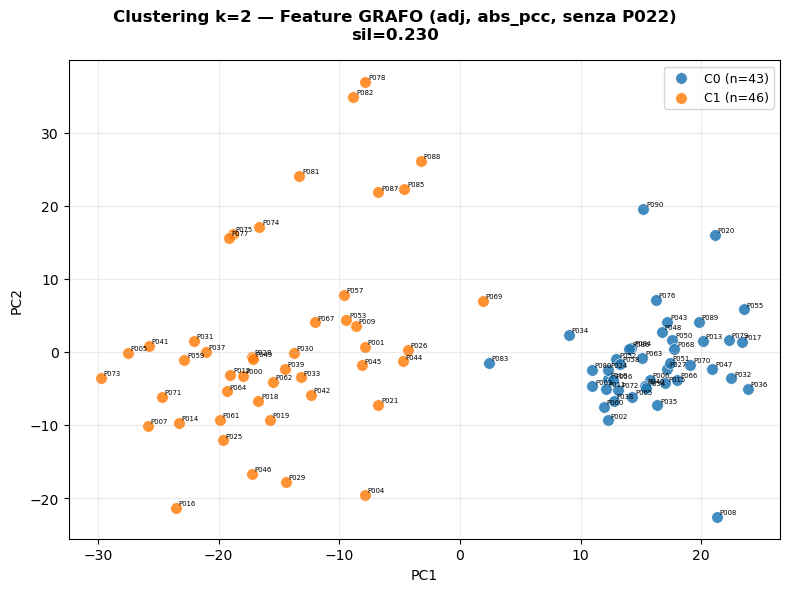

In [5]:
scaler_g = StandardScaler()
X_g = scaler_g.fit_transform(FEAT_G)
pca_g = PCA(n_components=min(20, len(SUBJ_G) - 1), random_state=RANDOM_SEED)
Z_g   = pca_g.fit_transform(X_g)
log.info(f'Varianza spiegata PCA grafo (20 comp): {pca_g.explained_variance_ratio_.sum():.1%}')

# k=2 forzato
k_best_g = K_FORCED
LABELS_G  = KMeans(n_clusters=k_best_g, n_init=30, random_state=RANDOM_SEED).fit_predict(Z_g)
sil_g2    = silhouette_score(Z_g, LABELS_G)
log.info(f'Grafo k=2: silhouette={sil_g2:.3f}  |  cluster sizes: {dict(zip(*np.unique(LABELS_G, return_counts=True)))}')

PALETTE_G = plt.cm.tab10(np.linspace(0, 0.15, k_best_g))

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(f'Clustering k=2 — Feature GRAFO (adj, {METRIC}, senza P022)\nsil={sil_g2:.3f}',
             fontsize=12, fontweight='bold')
for c in range(k_best_g):
    mask = LABELS_G == c
    ax.scatter(Z_g[mask, 0], Z_g[mask, 1], label=f'C{c} (n={mask.sum()})',
               s=70, alpha=0.85, color=PALETTE_G[c], edgecolors='white', linewidths=0.5)
    for i in np.where(mask)[0]:
        ax.annotate(f'P{SUBJ_G[i]:03d}', (Z_g[i, 0], Z_g[i, 1]),
                    fontsize=5, xytext=(2, 2), textcoords='offset points')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_clustering_graph_k2.png', dpi=150, bbox_inches='tight')
plt.show()

## §4 — Clustering k=2 su feature IPERGRAFO (senza P022)

21:06:23 INFO     Varianza spiegata PCA ipergrafo (20 comp): 68.0%


21:06:23 INFO     Ipergrafo k=2: silhouette=0.274  |  cluster sizes: {np.int32(0): np.int64(48), np.int32(1): np.int64(41)}


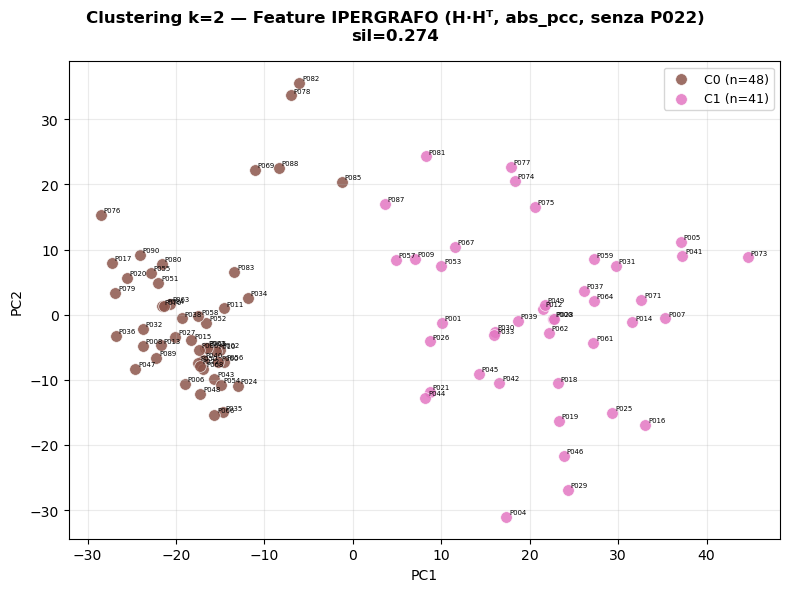

In [6]:
scaler_h = StandardScaler()
X_h = scaler_h.fit_transform(FEAT_H)
pca_h = PCA(n_components=min(20, len(SUBJ_H) - 1), random_state=RANDOM_SEED)
Z_h   = pca_h.fit_transform(X_h)
log.info(f'Varianza spiegata PCA ipergrafo (20 comp): {pca_h.explained_variance_ratio_.sum():.1%}')

k_best_h = K_FORCED
LABELS_H  = KMeans(n_clusters=k_best_h, n_init=30, random_state=RANDOM_SEED).fit_predict(Z_h)
sil_h2    = silhouette_score(Z_h, LABELS_H)
log.info(f'Ipergrafo k=2: silhouette={sil_h2:.3f}  |  cluster sizes: {dict(zip(*np.unique(LABELS_H, return_counts=True)))}')

PALETTE_H = plt.cm.tab10(np.linspace(0.5, 0.65, k_best_h))

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle(f'Clustering k=2 — Feature IPERGRAFO (H·Hᵀ, {METRIC}, senza P022)\nsil={sil_h2:.3f}',
             fontsize=12, fontweight='bold')
for c in range(k_best_h):
    mask = LABELS_H == c
    ax.scatter(Z_h[mask, 0], Z_h[mask, 1], label=f'C{c} (n={mask.sum()})',
               s=70, alpha=0.85, color=PALETTE_H[c], edgecolors='white', linewidths=0.5)
    for i in np.where(mask)[0]:
        ax.annotate(f'P{SUBJ_H[i]:03d}', (Z_h[i, 0], Z_h[i, 1]),
                    fontsize=5, xytext=(2, 2), textcoords='offset points')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_clustering_hypergraph_k2.png', dpi=150, bbox_inches='tight')
plt.show()

## §4b — Nomenclatura neuroscientizia dei cluster

Basandosi sull'analisi di connettività (§10) e XAI Cohen's d (§17), i due cluster
ricevono un nome neuroscientifico:

| Cluster | Nome | Hub principali | Network |
|---------|------|----------------|---------|
| **C0** | **Fronto-motor type** | F2, C2, FC2 | Fronto-centrale, emisfero destro — pianificazione articolatoria subvocalica |
| **C1** | **Fronto-occipital type** | F3, PO8 | Fronto-occipitale sinistro→destro — network visivo-linguistico |

- **C0 "Fronto-motor"**: connettività dominante tra frontale mediale (F2) e corteccia motoria (C2, FC2).
  C2/FC2 coprono la corteccia motoria primaria e l'area motoria supplementare — strutture che
  pianificano il movimento articolatorio durante il linguaggio subvocalico.
- **C1 "Fronto-occipital"**: connettività dominante F3→PO8 (|d|=5.4), lunga distanza emisferica.
  F3 ≈ area di Broca (linguaggio espressivo); PO8/Oz = aree visivo-spaziali.
  Soggetti che "visualizzano" le parole durante l'imagined speech.

In [7]:
# §4b — Definizione nomi cluster (usati in tutti i plot successivi)
CLUSTER_NAMES = {
    0: 'Fronto-motor',
    1: 'Fronto-occipital',
}
CLUSTER_DESC = {
    0: 'Fronto-motor type (C0)\nHub: F2, C2, FC2 — network articolatorio',
    1: 'Fronto-occipital type (C1)\nHub: F3, PO8 — network visivo-linguistico',
}
log.info(f'Cluster 0 = {CLUSTER_NAMES[0]}')
log.info(f'Cluster 1 = {CLUSTER_NAMES[1]}')

21:06:23 INFO     Cluster 0 = Fronto-motor
21:06:23 INFO     Cluster 1 = Fronto-occipital


## §5 — Caricamento bAcc post-hoc

In [8]:
acc_data = {}
for label, fpath in [('EEG_12', ACC_FILE_12), ('EEG_13', ACC_FILE_13)]:
    if fpath.exists():
        df = pd.read_csv(fpath)
        if 'Subject' in df.columns:
            df['sid'] = df['Subject'].str.extract(r'(\d+)').astype(int)
        col = 'Test bAcc' if 'Test bAcc' in df.columns else 'test_bacc'
        acc_data[label] = dict(zip(df['sid'], df[col]))
        log.info(f'{label}: {len(acc_data[label])} soggetti')
    else:
        log.warning(f'{label} non trovato')

acc12 = acc_data.get('EEG_12', {})
acc13 = acc_data.get('EEG_13', {})
ACC   = acc13 if acc13 else acc12
log.info(f'Accuracy primaria: {"EEG_13" if acc13 else "EEG_12"} ({len(ACC)} soggetti)')

21:06:23 INFO     EEG_12: 73 soggetti
21:06:23 INFO     EEG_13: 90 soggetti
21:06:23 INFO     Accuracy primaria: EEG_13 (90 soggetti)


## §6 — Post-hoc: cluster GRAFO vs bAcc

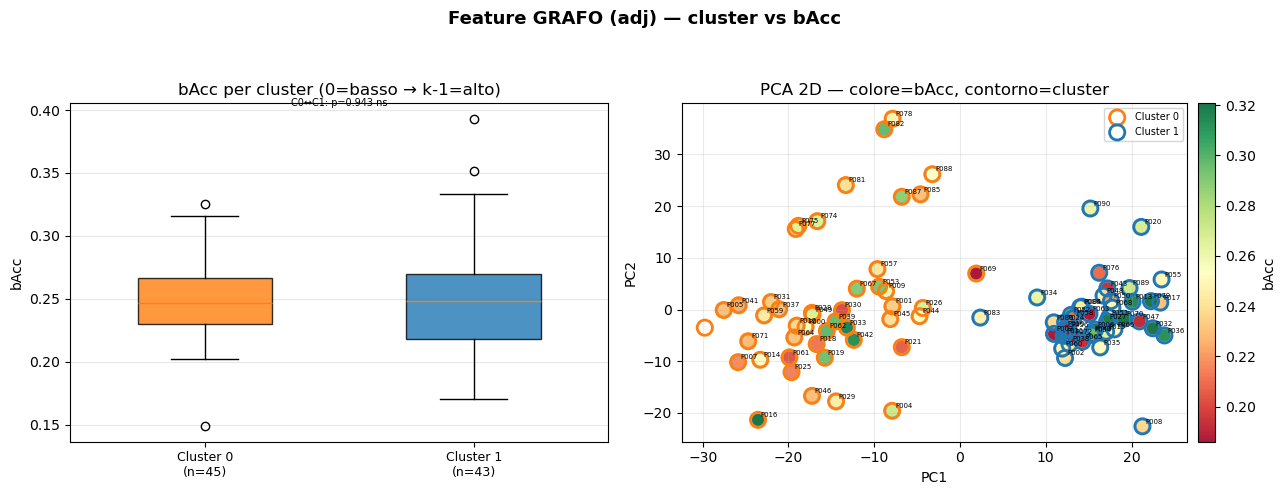

In [9]:
def postHoc(labels, subj_ids, Z, palette, acc_dict, source_name, save_stem):
    k = len(set(labels))
    clust_accs = defaultdict(list)
    for i, sid in enumerate(subj_ids):
        if sid in acc_dict:
            clust_accs[labels[i]].append(acc_dict[sid])

    # Riordina cluster per acc media crescente
    order  = sorted(clust_accs, key=lambda c: np.mean(clust_accs[c]) if clust_accs[c] else 0)
    remap  = {old: new for new, old in enumerate(order)}
    lbl_r  = np.array([remap[l] for l in labels])
    acc_r  = {remap[c]: v for c, v in clust_accs.items()}
    pal_r  = [palette[order[c]] for c in range(k)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{source_name} — cluster vs bAcc', fontsize=13, fontweight='bold')

    # ── Boxplot ───────────────────────────────────────────────────────────────
    ax = axes[0]
    bp = ax.boxplot([acc_r.get(c, []) for c in range(k)],
                    patch_artist=True, widths=0.5, notch=False)
    for patch, col in zip(bp['boxes'], pal_r):
        patch.set_facecolor(col); patch.set_alpha(0.8)
    ax.set_xticklabels([f'Cluster {c}\n(n={len(acc_r.get(c,[]))})' for c in range(k)], fontsize=9)
    ax.set_ylabel('bAcc'); ax.set_title('bAcc per cluster (0=basso → k-1=alto)')
    ax.grid(axis='y', alpha=0.3)

    # Annotazione p-value Mann-Whitney
    all_vals = [v for vlist in acc_r.values() for v in vlist]
    y_top = max(all_vals) + 0.01 if all_vals else 0.4
    pairs = [(ci, cj) for ci in range(k) for cj in range(ci + 1, k)]
    for offset, (ci, cj) in enumerate(pairs):
        a, b = acc_r.get(ci, []), acc_r.get(cj, [])
        if len(a) >= 2 and len(b) >= 2:
            _, pval = mannwhitneyu(a, b, alternative='two-sided')
            star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
            y = y_top + offset * 0.018
            ax.annotate(f'C{ci}↔C{cj}: p={pval:.3f} {star}',
                        xy=(1.5, y), fontsize=7, ha='center', color='black')

    # ── PCA 2D colorato per bAcc ──────────────────────────────────────────────
    ax2 = axes[1]
    accs_vec = np.array([acc_dict.get(sid, np.nan) for sid in subj_ids])
    valid    = ~np.isnan(accs_vec)
    sc = ax2.scatter(Z[valid, 0], Z[valid, 1], c=accs_vec[valid],
                     cmap='RdYlGn', s=80, alpha=0.9,
                     vmin=np.nanpercentile(accs_vec, 5),
                     vmax=np.nanpercentile(accs_vec, 95),
                     edgecolors='grey', linewidths=0.4)
    plt.colorbar(sc, ax=ax2, label='bAcc', fraction=0.04, pad=0.02)
    # Contorno cluster
    for c in range(k):
        mask = lbl_r == c
        ax2.scatter(Z[mask, 0], Z[mask, 1], s=120, facecolors='none',
                    edgecolors=pal_r[c], linewidths=2, label=f'Cluster {c}', zorder=3)
    for i in range(len(subj_ids)):
        if valid[i]:
            ax2.annotate(f'P{subj_ids[i]:03d}', (Z[i, 0], Z[i, 1]),
                         fontsize=5, xytext=(2, 2), textcoords='offset points')
    ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
    ax2.set_title('PCA 2D — colore=bAcc, contorno=cluster')
    ax2.legend(fontsize=7); ax2.grid(alpha=0.25)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(FIG_DIR / f'{save_stem}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return lbl_r

LABELS_G_R = postHoc(LABELS_G, SUBJ_G, Z_g, PALETTE_G, ACC,
                     'Feature GRAFO (adj)', 'eeg16_graph_vs_bacc')

## §7 — Post-hoc: cluster IPERGRAFO vs bAcc

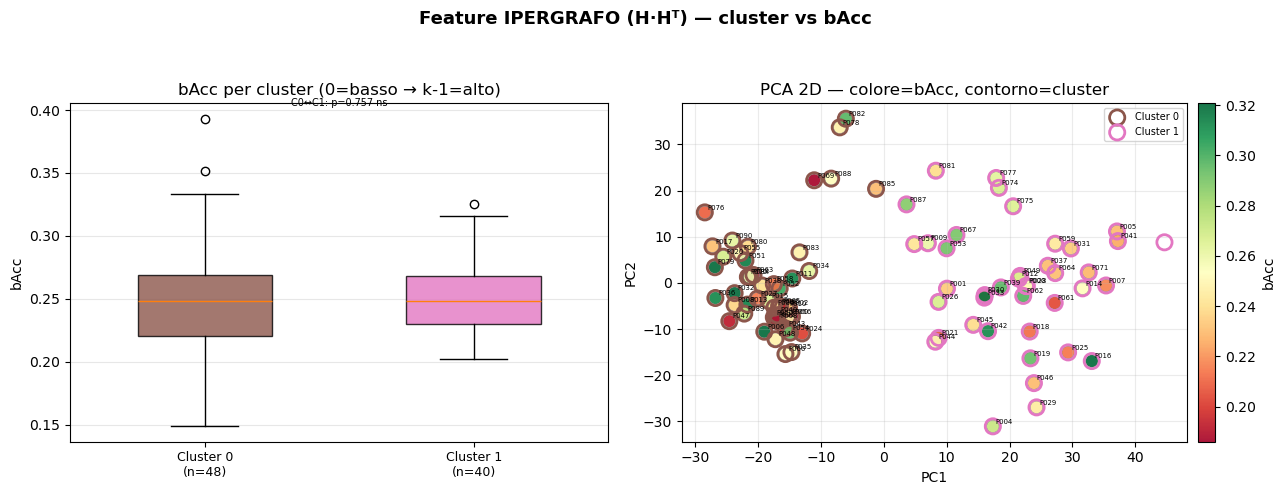

In [10]:
LABELS_H_R = postHoc(LABELS_H, SUBJ_H, Z_h, PALETTE_H, ACC,
                     'Feature IPERGRAFO (H·Hᵀ)', 'eeg16_hypergraph_vs_bacc')

## §8 — Concordanza clustering grafo vs ipergrafo (ARI)

21:06:25 INFO     Soggetti in comune grafo ∩ ipergrafo: 89
21:06:25 INFO     ARI (grafo vs ipergrafo): 0.785


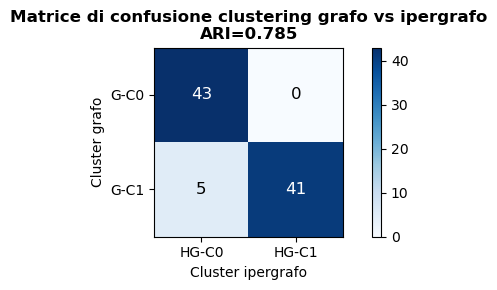

In [11]:
common = sorted(set(SUBJ_G) & set(SUBJ_H))
log.info(f'Soggetti in comune grafo ∩ ipergrafo: {len(common)}')

lbl_g_common = np.array([LABELS_G[SUBJ_G.index(s)] for s in common])
lbl_h_common = np.array([LABELS_H[SUBJ_H.index(s)] for s in common])
ari = adjusted_rand_score(lbl_g_common, lbl_h_common)
log.info(f'ARI (grafo vs ipergrafo): {ari:.3f}')

fig, ax = plt.subplots(figsize=(max(k_best_g, k_best_h) * 2.5 + 1, 3))
cm = np.zeros((k_best_g, k_best_h), dtype=int)
for g, h in zip(lbl_g_common, lbl_h_common):
    cm[g, h] += 1
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(k_best_h)); ax.set_xticklabels([f'HG-C{c}' for c in range(k_best_h)])
ax.set_yticks(range(k_best_g)); ax.set_yticklabels([f'G-C{c}' for c in range(k_best_g)])
ax.set_xlabel('Cluster ipergrafo'); ax.set_ylabel('Cluster grafo')
ax.set_title(f'Matrice di confusione clustering grafo vs ipergrafo\nARI={ari:.3f}', fontweight='bold')
for i in range(k_best_g):
    for j in range(k_best_h):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12,
                color='white' if cm[i, j] > cm.max() * 0.6 else 'black')
plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16_ari_graph_vs_hypergraph.png', dpi=150, bbox_inches='tight')
plt.show()

## §8b — Tabella riassuntiva soggetti

In [12]:
rows = []
for sid in sorted(set(SUBJ_G) | set(SUBJ_H)):
    row = {'Subject': f'P{sid:03d}',
           'cluster_graph':     LABELS_G[SUBJ_G.index(sid)] if sid in SUBJ_G else np.nan,
           'cluster_hypergraph':LABELS_H[SUBJ_H.index(sid)] if sid in SUBJ_H else np.nan,
           'bacc_EEG_12': acc12.get(sid, np.nan),
           'bacc_EEG_13': acc13.get(sid, np.nan)}
    rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary.to_csv(FIG_DIR / 'eeg16_subject_cluster_summary.csv', index=False)

# Stampa con colorazione manuale
display_df = df_summary.copy()
print(display_df.to_string(index=False, float_format='{:.4f}'.format))

# Statistiche per cluster grafo
print('\n── Statistiche bAcc per cluster GRAFO ──')
for c in sorted(df_summary['cluster_graph'].dropna().unique()):
    sub = df_summary[df_summary['cluster_graph'] == c]['bacc_EEG_13'].dropna()
    print(f'  Cluster {int(c)}: n={len(sub)}  mean={sub.mean():.3f}  std={sub.std():.3f}  '
          f'[{sub.min():.3f}, {sub.max():.3f}]')

print('\n── Statistiche bAcc per cluster IPERGRAFO ──')
for c in sorted(df_summary['cluster_hypergraph'].dropna().unique()):
    sub = df_summary[df_summary['cluster_hypergraph'] == c]['bacc_EEG_13'].dropna()
    print(f'  Cluster {int(c)}: n={len(sub)}  mean={sub.mean():.3f}  std={sub.std():.3f}  '
          f'[{sub.min():.3f}, {sub.max():.3f}]')

Subject  cluster_graph  cluster_hypergraph  bacc_EEG_12  bacc_EEG_13
   P000              1                   1       0.2731       0.2569
   P001              1                   1       0.2500       0.2336
   P002              0                   0       0.2973       0.2403
   P003              0                   0       0.2384       0.1777
   P004              1                   1       0.2546       0.2713
   P005              1                   1       0.2567       0.2300
   P006              0                   0       0.2396       0.3517
   P007              1                   1       0.2063       0.2173
   P008              0                   0       0.2871       0.2366
   P009              1                   1       0.2607       0.2600
   P010              0                   0       0.1984       0.2308
   P011              0                   0       0.2549       0.3127
   P012              1                   1       0.2500       0.2367
   P013              0            

## §9 — PCA Loadings: quali connessioni electrode-pair guidano C0 vs C1?

PC1 separa i due cluster nello spazio ridotto. I **loadings di PC1** (pesi delle 1830 feature originali
sul primo componente principale) indicano quali coppie di elettrodi sono più discriminative.

**Interpretazione**:
- Loading alto positivo → questa coppia di elettrodi ha alta connettività nel cluster con PC1 alto
- Loading alto negativo → questa coppia ha alta connettività nel cluster con PC1 basso
- Aggregando i loadings per elettrodo → quale regione cerebrale è più "responsabile" della separazione

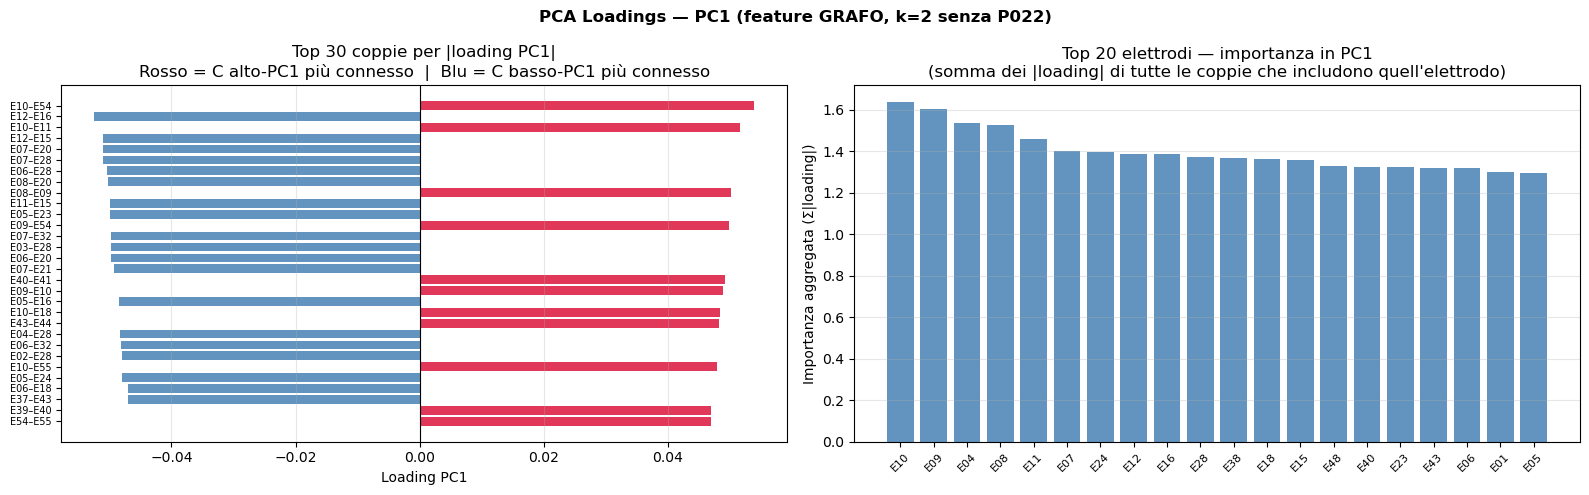


── Top 15 elettrodi per importanza in PC1 (GRAFO) ──
  # 1  E10  importance=1.6385
  # 2  E09  importance=1.6043
  # 3  E04  importance=1.5371
  # 4  E08  importance=1.5270
  # 5  E11  importance=1.4620
  # 6  E07  importance=1.4035
  # 7  E24  importance=1.3958
  # 8  E12  importance=1.3887
  # 9  E16  importance=1.3882
  #10  E28  importance=1.3747
  #11  E38  importance=1.3661
  #12  E18  importance=1.3617
  #13  E15  importance=1.3591
  #14  E48  importance=1.3277
  #15  E40  importance=1.3264


In [13]:
# ── PC1 loadings del grafo ────────────────────────────────────────────────────
pc1_loadings = pca_g.components_[0]   # (1830,) — peso di ogni feature in PC1

# Top 30 coppie per |loading|
top_n = 30
top_load_idx = np.argsort(np.abs(pc1_loadings))[::-1][:top_n]
top_pairs_load = feat_to_elec_pair(top_load_idx)
top_load_vals  = pc1_loadings[top_load_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PCA Loadings — PC1 (feature GRAFO, k=2 senza P022)', fontsize=12, fontweight='bold')

ax = axes[0]
colors_load = ['crimson' if v > 0 else 'steelblue' for v in top_load_vals[::-1]]
pair_str    = [f'E{r:02d}–E{c:02d}' for r, c in top_pairs_load[::-1]]
ax.barh(range(top_n), top_load_vals[::-1], color=colors_load, alpha=0.85)
ax.set_yticks(range(top_n))
ax.set_yticklabels(pair_str, fontsize=7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Loading PC1')
ax.set_title(f'Top {top_n} coppie per |loading PC1|\nRosso = C alto-PC1 più connesso  |  Blu = C basso-PC1 più connesso')
ax.grid(axis='x', alpha=0.3)

# ── Aggregazione per elettrodo: somma |loading| di tutte le coppie ────────────
rows_triu, cols_triu = np.triu_indices(N_CHAN, k=1)
elec_importance = np.zeros(N_CHAN)
for feat_i, val in enumerate(pc1_loadings):
    r, c = rows_triu[feat_i], cols_triu[feat_i]
    elec_importance[r] += abs(val)
    elec_importance[c] += abs(val)

# Top 20 elettrodi per importanza
top_elec_idx = np.argsort(elec_importance)[::-1][:20]
ax2 = axes[1]
ax2.bar(range(20), elec_importance[top_elec_idx], color='steelblue', alpha=0.85)
ax2.set_xticks(range(20))
ax2.set_xticklabels([f'E{e:02d}' for e in top_elec_idx], rotation=45, fontsize=8)
ax2.set_ylabel('Importanza aggregata (Σ|loading|)')
ax2.set_title('Top 20 elettrodi — importanza in PC1\n(somma dei |loading| di tutte le coppie che includono quell\'elettrodo)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_pca_loadings_pc1.png', dpi=150, bbox_inches='tight')
plt.show()

# Stampa ranking elettrodi
print('\n── Top 15 elettrodi per importanza in PC1 (GRAFO) ──')
for rank, e in enumerate(elec_importance.argsort()[::-1][:15]):
    print(f'  #{rank+1:2d}  E{e:02d}  importance={elec_importance[e]:.4f}')

## §10 — Mappa differenza per elettrodo: C1 − C0

Per ogni elettrodo `i`: `strength_diff[i] = mean_j(|adj_C1[i,j] − adj_C0[i,j]|)`

Mostra quale elettrodo ha la connettività più **diversa** tra i due cluster.
Positivo = C1 ha più connettività da quell'elettrodo; negativo = C0 ne ha di più.

Questa è la risposta alla domanda: **in quale regione cerebrale differiscono i due cluster?**

21:06:25 INFO     C0: 43 soggetti  |  C1: 46 soggetti


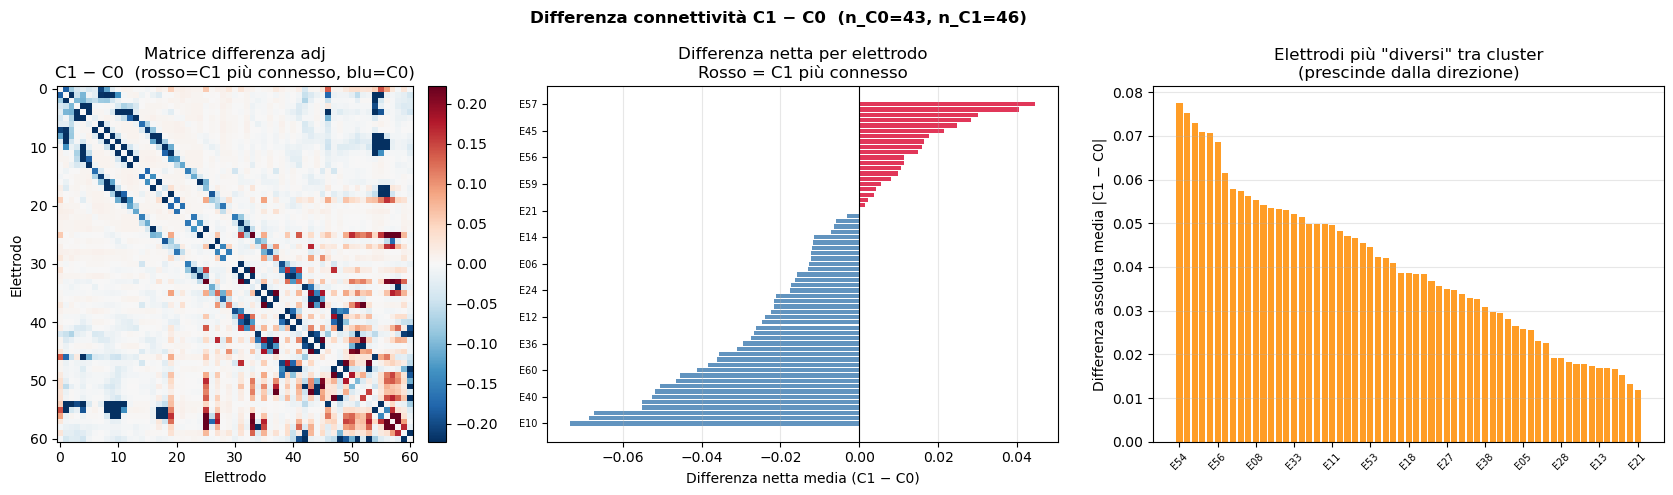


── Top 10 elettrodi: C1 più connesso (netti positivi) ──
  E57  net_diff=+0.04443  abs_diff=0.05620
  E25  net_diff=+0.04047  abs_diff=0.06145
  E58  net_diff=+0.03002  abs_diff=0.04977
  E33  net_diff=+0.02823  abs_diff=0.05205
  E37  net_diff=+0.02487  abs_diff=0.04662
  E45  net_diff=+0.02142  abs_diff=0.04825
  E50  net_diff=+0.01772  abs_diff=0.03858
  E35  net_diff=+0.01636  abs_diff=0.05298
  E52  net_diff=+0.01587  abs_diff=0.03833
  E53  net_diff=+0.01494  abs_diff=0.04456

── Top 10 elettrodi: C0 più connesso (netti negativi) ──
  E10  net_diff=-0.07330  abs_diff=0.07513
  E09  net_diff=-0.06852  abs_diff=0.07059
  E54  net_diff=-0.06728  abs_diff=0.07754
  E48  net_diff=-0.05511  abs_diff=0.05727
  E04  net_diff=-0.05507  abs_diff=0.05789
  E40  net_diff=-0.05246  abs_diff=0.05422
  E08  net_diff=-0.05193  abs_diff=0.05527
  E01  net_diff=-0.05064  abs_diff=0.05349
  E44  net_diff=-0.04661  abs_diff=0.04978
  E11  net_diff=-0.04553  abs_diff=0.04953

── Top 10 elettrodi per

In [14]:
def vec_to_sym(vec):
    M = np.zeros((N_CHAN, N_CHAN))
    M[triu_idx] = vec
    return M + M.T

# ── Matrici medie per C0 e C1 ─────────────────────────────────────────────────
def cluster_mean_matrix(feats, subj_ids, labels, cluster_id):
    idx_c = [i for i, l in enumerate(labels) if l == cluster_id]
    mats  = [vec_to_sym(feats[i]) for i in idx_c]
    return np.mean(mats, axis=0) if mats else None

adj_C0 = cluster_mean_matrix(FEAT_G, SUBJ_G, LABELS_G, 0)
adj_C1 = cluster_mean_matrix(FEAT_G, SUBJ_G, LABELS_G, 1)
diff_adj = adj_C1 - adj_C0   # (61, 61) — C1 minus C0

n_c0 = (LABELS_G == 0).sum()
n_c1 = (LABELS_G == 1).sum()
log.info(f'C0: {n_c0} soggetti  |  C1: {n_c1} soggetti')

# ── Aggregazione per elettrodo ─────────────────────────────────────────────────
# Differenza netta: mean_j(diff[i,j]) — positivo = C1 più connesso da quell'elettrodo
net_diff_per_elec   = diff_adj.mean(axis=1)   # (61,)
# Differenza assoluta: mean_j(|diff[i,j]|) — quanto è diversa la connettività totale
abs_diff_per_elec   = np.abs(diff_adj).mean(axis=1)

# ── Plot 1×3: matrice diff | elettrodi netti | elettrodi assoluti ─────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Differenza connettività C1 − C0  (n_C0={n_c0}, n_C1={n_c1})',
             fontsize=12, fontweight='bold')

# Col 0: heatmap differenza 61×61
ax = axes[0]
d_lim = np.percentile(np.abs(diff_adj), 95)
im = ax.imshow(diff_adj, cmap='RdBu_r', vmin=-d_lim, vmax=d_lim, interpolation='nearest')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
ax.set_title('Matrice differenza adj\nC1 − C0  (rosso=C1 più connesso, blu=C0)')
ax.set_xlabel('Elettrodo'); ax.set_ylabel('Elettrodo')

# Col 1: differenza netta per elettrodo (ranking)
ax2 = axes[1]
order_net = np.argsort(net_diff_per_elec)
colors_net = ['crimson' if v > 0 else 'steelblue' for v in net_diff_per_elec[order_net]]
ax2.barh(range(N_CHAN), net_diff_per_elec[order_net], color=colors_net, alpha=0.85)
ax2.set_yticks(range(0, N_CHAN, 5))
ax2.set_yticklabels([f'E{order_net[i]:02d}' for i in range(0, N_CHAN, 5)], fontsize=7)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Differenza netta media (C1 − C0)')
ax2.set_title('Differenza netta per elettrodo\nRosso = C1 più connesso')
ax2.grid(axis='x', alpha=0.3)

# Col 2: differenza assoluta per elettrodo (top elettrodi "più diversi")
ax3 = axes[2]
order_abs = np.argsort(abs_diff_per_elec)[::-1]
ax3.bar(range(N_CHAN), abs_diff_per_elec[order_abs], color='darkorange', alpha=0.85)
ax3.set_xticks(range(0, N_CHAN, 5))
ax3.set_xticklabels([f'E{order_abs[i]:02d}' for i in range(0, N_CHAN, 5)], rotation=45, fontsize=7)
ax3.set_ylabel('Differenza assoluta media |C1 − C0|')
ax3.set_title('Elettrodi più "diversi" tra cluster\n(prescinde dalla direzione)')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'eeg16b_electrode_diff_map.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Stampa top e bottom 10 elettrodi ──────────────────────────────────────────
print('\n── Top 10 elettrodi: C1 più connesso (netti positivi) ──')
for e in net_diff_per_elec.argsort()[::-1][:10]:
    print(f'  E{e:02d}  net_diff={net_diff_per_elec[e]:+.5f}  abs_diff={abs_diff_per_elec[e]:.5f}')

print('\n── Top 10 elettrodi: C0 più connesso (netti negativi) ──')
for e in net_diff_per_elec.argsort()[:10]:
    print(f'  E{e:02d}  net_diff={net_diff_per_elec[e]:+.5f}  abs_diff={abs_diff_per_elec[e]:.5f}')

print('\n── Top 10 elettrodi per |diff| assoluta (più diversi tra cluster) ──')
for e in abs_diff_per_elec.argsort()[::-1][:10]:
    print(f'  E{e:02d}  abs_diff={abs_diff_per_elec[e]:.5f}  net_diff={net_diff_per_elec[e]:+.5f}')

## §10b — Interpretazione: mappatura elettrodi → regioni cerebrali

Usando `data/interim/channel_mapping.csv` (E_idx = channel_index − 1, 0-based):

### C1 più connesso (net_diff > 0)
| Elettrodo | Nome 10-20 | Regione |
|-----------|-----------|---------|
| E54 | **PO8** | Parieto-occipitale destra |
| E10 | **F3** | Frontale sinistra |
| E09 | **F5** | Frontale sinistra |
| E01 | **AF7** | Antero-frontale sinistra |
| E55 | **Oz** | Occipitale centro |
| E04 | **FP2** | Polo frontale destro |
| E08 | **F7** | Frontale sinistra |
| E48 | **FPz** | Polo frontale centro |
| E11 | **F1** | Frontale sinistra |
| E40 | **T5/P7** | Temporale posteriore sinistra |

### C0 più connesso (net_diff < 0)
| Elettrodo | Nome 10-20 | Regione |
|-----------|-----------|---------|
| E57 | **Fz** | Frontale midline |
| E58 | **FCz** | Fronto-centrale midline |
| E25 | **C5** | Centrale sinistra |
| E33 | **CP5** | Centro-parietale sinistra |
| E37 | **CP4** | Centro-parietale destra |
| E45 | **P4** | Parietale destra |
| E35 | **CP1** | Centro-parietale sinistra |

---

### Pattern emerso

**C1 = connettività FRONTALE + OCCIPITALE dominante**
F3, F5, F7, AF7, FP2, FPz (frontale sinistra/polo) + PO8, Oz (parieto-occipitale/occipitale)

**C0 = connettività CENTRALE + CENTRO-PARIETALE dominante**
Fz, FCz, C5, CP5, CP4, CP1, P4 (asse sensorimotor-parietale)

La separazione **non è globale** (tutti i canali uniformemente più forti in un cluster) — è **topografica**:
i due cluster differiscono in *dove* si concentra la connettività funzionale.

### Interpretazione neuroscientifica
- **C1** (fronto-occipitale): connettività associata a imagery visiva e preparazione linguistica.
  F3/F5 ≈ area di Broca sinistra (pianificazione del linguaggio); PO8/Oz = corteccia visiva.
  Possibile correlato: soggetti che supportano il task IS con una strategia visuo-linguistica.
- **C0** (centro-parietale): connettività del loop sensorimotor classico.
  Fz/FCz/C5 = corteccia motoria supplementare e primaria; CP5/CP4/P4 = integrazione sensorimotor-parietale.
  Possibile correlato: soggetti con strategia motoria interna (articolazione subvocalica).

### ⚠️ Ipotesi alternativa da verificare in §14
La connettività frontale (F3, F7, AF7, FPz) può essere elevata da **artefatti muscolari frontali**
(EMG → alta ampiezza → alta PCC in quei canali).
- Se §14 mostra varianza raw **significativamente più alta in C1** → la separazione potrebbe essere
  un artefatto di qualità del segnale, non una differenza neurale genuina.
- Se varianza **ns** tra C0 e C1 → la differenza topografica è reale e interpretabile.

## §11 — Visualizzazione: segnale raw, grafo, ipergrafo per cluster

Per ogni cluster C0/C1: segnale EEG raw medio, matrice adj media, H·Hᵀ media.

In [15]:
# Con k=2 forzato usiamo sempre il clustering GRAFO come top (silhouette sil_g2 vs sil_h2)
if sil_g2 >= sil_h2:
    LABELS_TOP, SUBJ_TOP, k_top = LABELS_G, SUBJ_G, k_best_g
    top_src = f'GRAFO (k=2, sil={sil_g2:.3f})'
else:
    LABELS_TOP, SUBJ_TOP, k_top = LABELS_H, SUBJ_H, k_best_h
    top_src = f'IPERGRAFO (k=2, sil={sil_h2:.3f})'
log.info(f'Top clustering: {top_src}')

# ── Matrici medie per cluster (grafo + ipergrafo) ────────────────────────────
cluster_adj = {}
cluster_hht = {}
for c in range(k_top):
    subj_c = [SUBJ_TOP[i] for i in range(len(SUBJ_TOP)) if LABELS_TOP[i] == c]
    adjs_c = [vec_to_sym(FEAT_G[SUBJ_G.index(s)]) for s in subj_c if s in SUBJ_G]
    hhts_c = [vec_to_sym(FEAT_H[SUBJ_H.index(s)]) for s in subj_c if s in SUBJ_H]
    cluster_adj[c] = np.mean(adjs_c, axis=0) if adjs_c else None
    cluster_hht[c] = np.mean(hhts_c, axis=0) if hhts_c else None
    log.info(f'  Cluster {c}: {len(subj_c)} soggetti  (adj={len(adjs_c)} hht={len(hhts_c)})')

# ── Segnale raw medio per soggetto (cache da eeg16) ──────────────────────────
RAW_CACHE = CKPT_DIR / 'mean_raw_per_subject.npz'
N_SAMP    = 384
raw_root  = project_root / 'data' / 'raw_csv' / 'training_set'

if RAW_CACHE.exists():
    log.info('Cache raw trovata')
    _r = np.load(RAW_CACHE)
    MEAN_RAW = _r['mean_raw']
    SUBJ_RAW = _r['subj_ids'].tolist()
else:
    log.warning('Cache raw non trovata — esegui prima EEG_16')
    MEAN_RAW, SUBJ_RAW = np.zeros((0, N_CHAN, N_SAMP)), []

cluster_raw = {}
for c in range(k_top):
    subj_c = [SUBJ_TOP[i] for i in range(len(SUBJ_TOP)) if LABELS_TOP[i] == c]
    raws_c = [MEAN_RAW[SUBJ_RAW.index(s)] for s in subj_c if s in SUBJ_RAW]
    cluster_raw[c] = np.mean(raws_c, axis=0) if raws_c else None
    log.info(f'  Cluster {c}: {len(raws_c)} soggetti con raw')

21:06:26 INFO     Top clustering: IPERGRAFO (k=2, sil=0.274)
21:06:26 INFO       Cluster 0: 48 soggetti  (adj=48 hht=48)
21:06:26 INFO       Cluster 1: 41 soggetti  (adj=41 hht=41)
21:06:26 INFO     Cache raw trovata
21:06:26 INFO       Cluster 0: 48 soggetti con raw
21:06:26 INFO       Cluster 1: 41 soggetti con raw


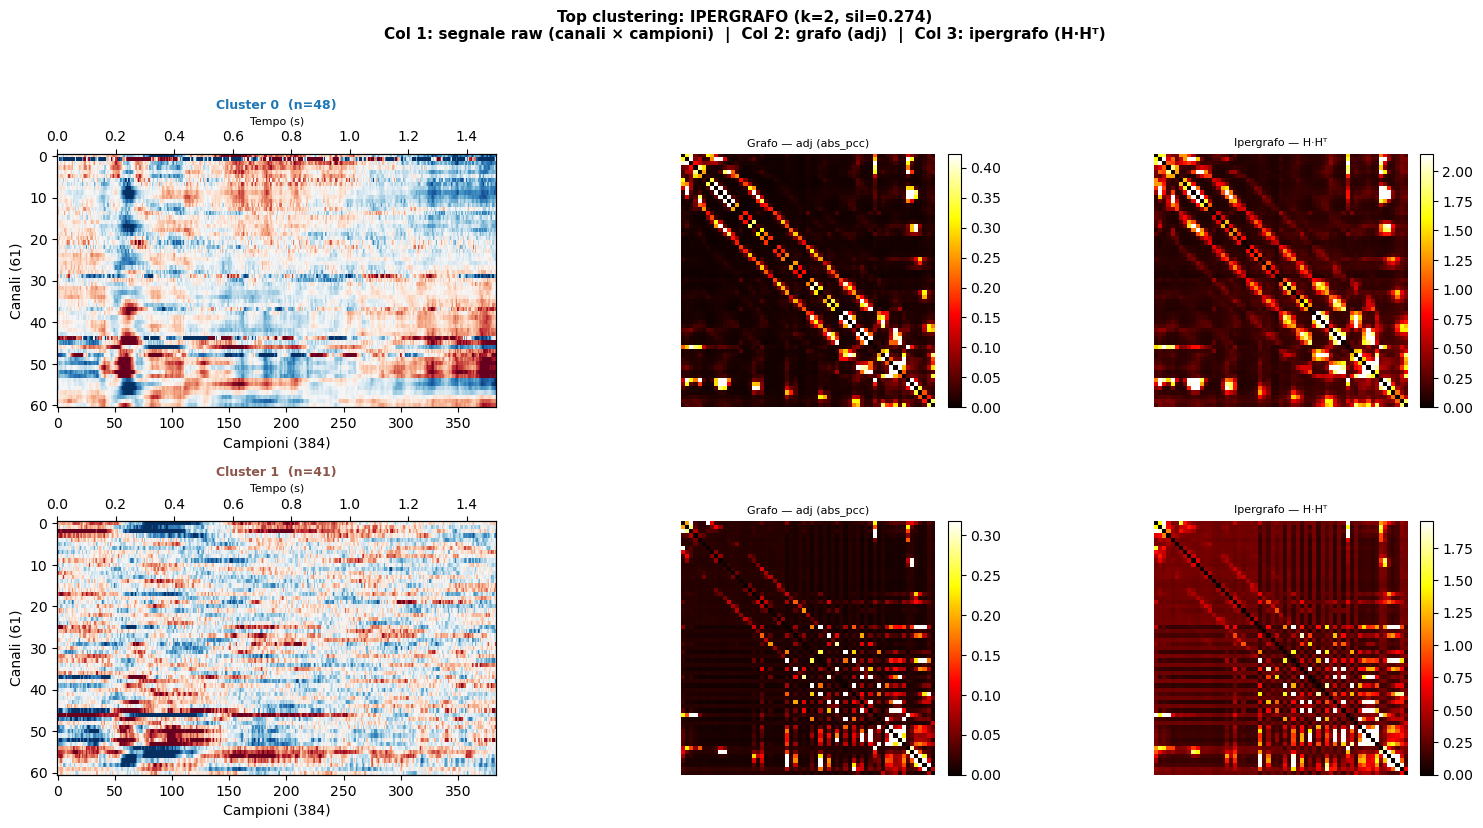

21:06:26 INFO     Plot §9 salvato


In [16]:
# ── Plot k × 3: raw | grafo | ipergrafo ──────────────────────────────────────
COLORS_TOP = plt.cm.tab10(np.linspace(0, 0.5, k_top))

fig, axes = plt.subplots(k_top, 3, figsize=(15, 4.2 * k_top))
fig.suptitle(
    f'Top clustering: {top_src}\n'
    f'Col 1: segnale raw (canali × campioni)  |  Col 2: grafo (adj)  |  Col 3: ipergrafo (H·Hᵀ)',
    fontsize=11, fontweight='bold'
)

for c in range(k_top):
    n_c   = int((LABELS_TOP == c).sum())
    color = COLORS_TOP[c]
    label = f'Cluster {c}  (n={n_c})'

    # ── Col 0: segnale raw ────────────────────────────────────────────────────
    ax0 = axes[c, 0]
    if cluster_raw[c] is not None:
        raw = cluster_raw[c]                          # (61, 384)
        vlim = np.percentile(np.abs(raw), 97)
        ax0.imshow(raw, aspect='auto', cmap='RdBu_r',
                   vmin=-vlim, vmax=vlim, interpolation='nearest')
        ax0.set_xlabel('Campioni (384)')
        ax0.set_ylabel('Canali (61)')
        t_ax = ax0.twiny()
        t_ax.set_xlim(0, N_SAMP / 256)
        t_ax.set_xlabel('Tempo (s)', fontsize=8)
    else:
        ax0.text(0.5, 0.5, 'N/D', ha='center', va='center', transform=ax0.transAxes)
    ax0.set_title(label, fontsize=9, color=color, fontweight='bold')

    # ── Col 1: grafo ──────────────────────────────────────────────────────────
    ax1 = axes[c, 1]
    if cluster_adj[c] is not None:
        adj = cluster_adj[c]
        im1 = ax1.imshow(adj, cmap='hot',
                         vmin=0, vmax=np.percentile(adj, 98),
                         interpolation='nearest')
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.03)
        ax1.set_title(f'Grafo — adj ({METRIC})', fontsize=8)
    ax1.axis('off')

    # ── Col 2: ipergrafo ──────────────────────────────────────────────────────
    ax2 = axes[c, 2]
    if cluster_hht[c] is not None:
        hht = cluster_hht[c]
        im2 = ax2.imshow(hht, cmap='hot',
                         vmin=0, vmax=np.percentile(hht, 98),
                         interpolation='nearest')
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.03)
        ax2.set_title('Ipergrafo — H·Hᵀ', fontsize=8)
    ax2.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(FIG_DIR / 'eeg16_top_cluster_raw_graph_hg.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Plot §9 salvato')


## §11b — Variabilità intra-cluster: ogni soggetto vs media

Per verificare se il clustering è reale o rumore:
- **Grafi adj**: ogni cella = matrice adj soggetto. Clustering reale → soggetti stesso cluster simili tra loro, diversi dall'altro.
- **H·Hᵀ**: idem struttura ipergrafo.
- **Raw**: butterfly plot per soggetto (canali sovrapposti, mean ± std).

Ultima colonna = **media cluster** (bordo rosso evidenziato).

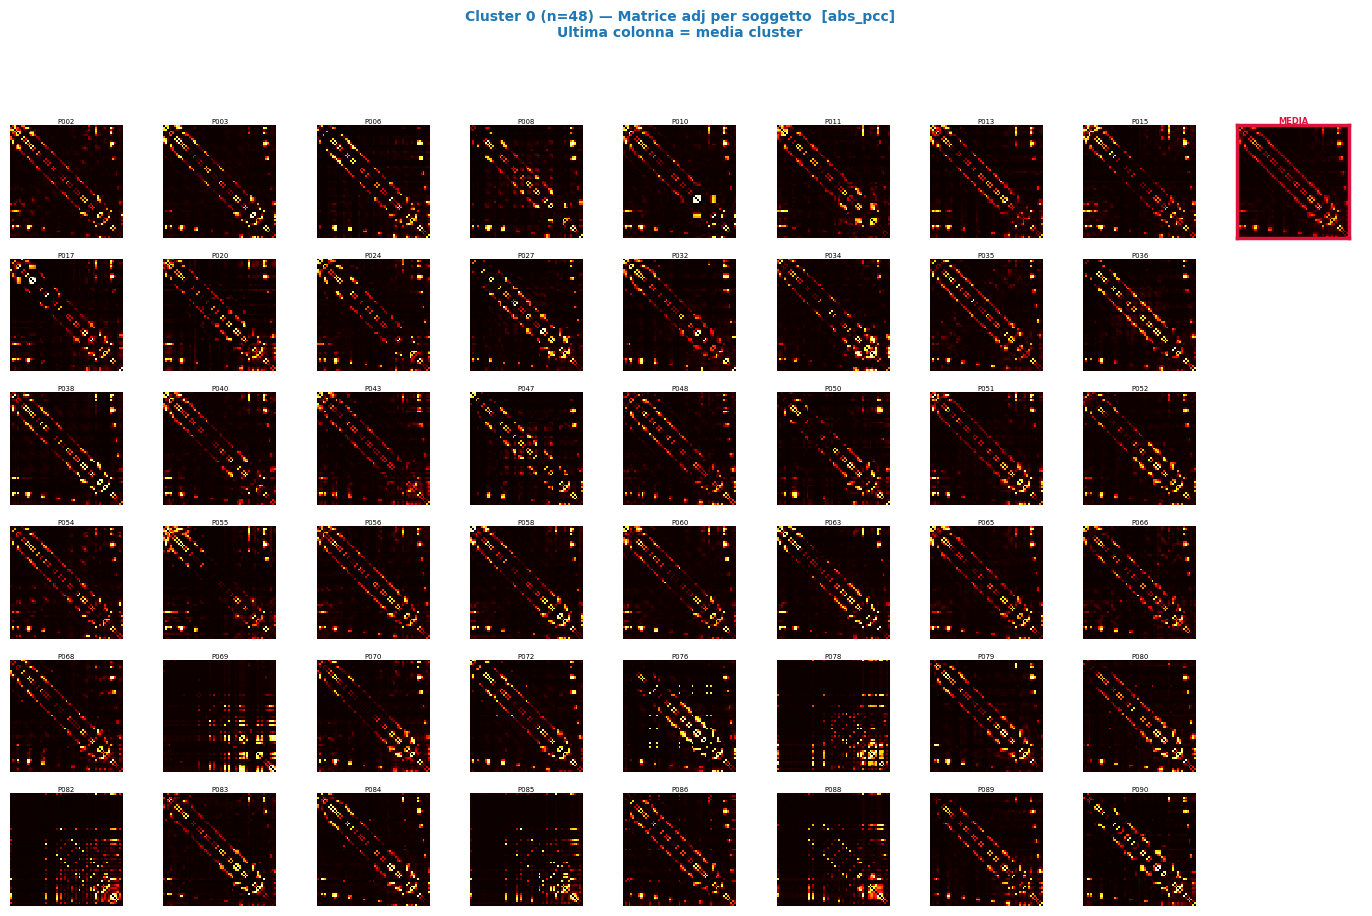

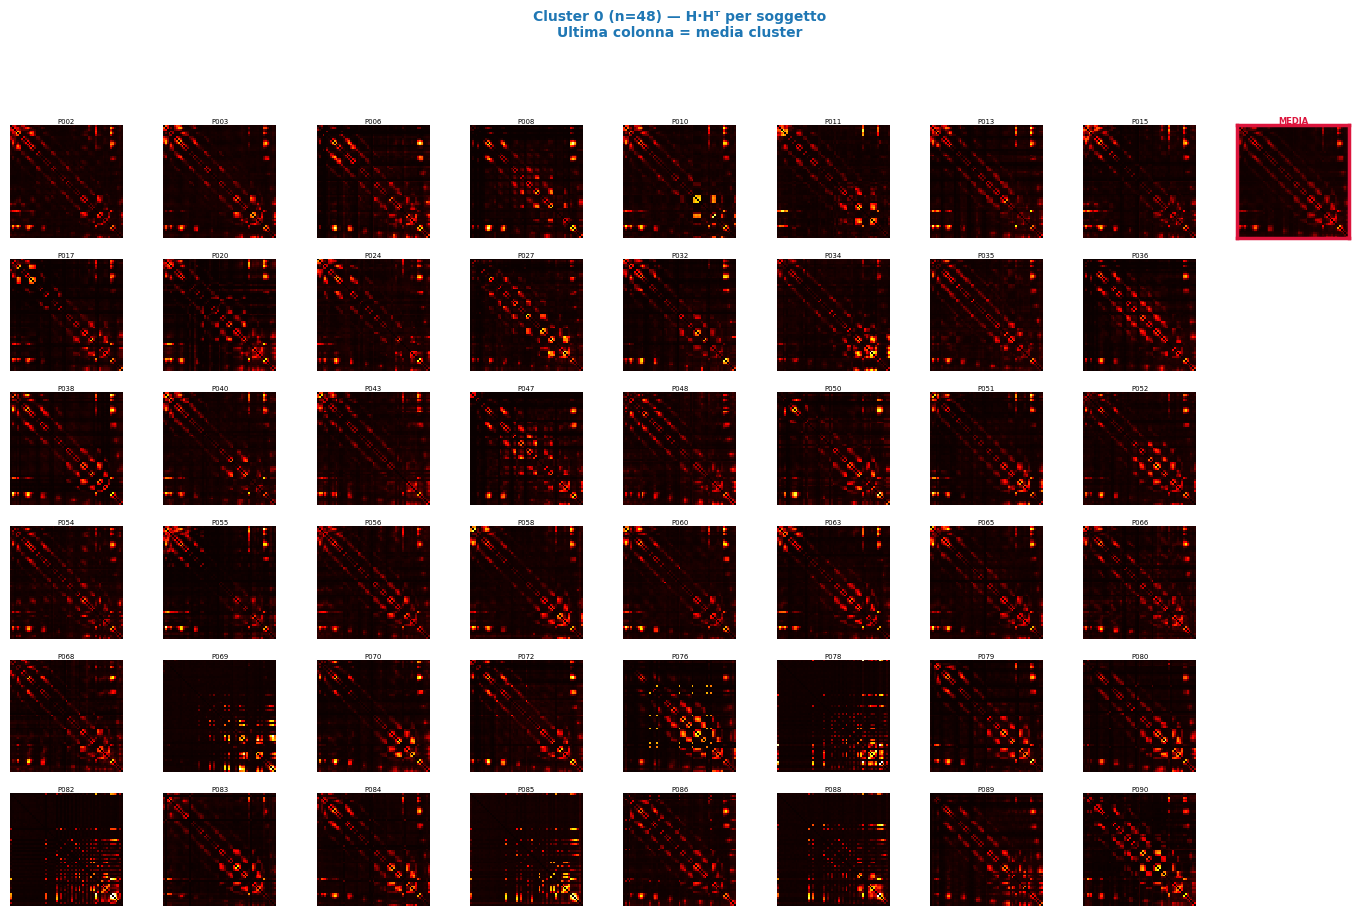

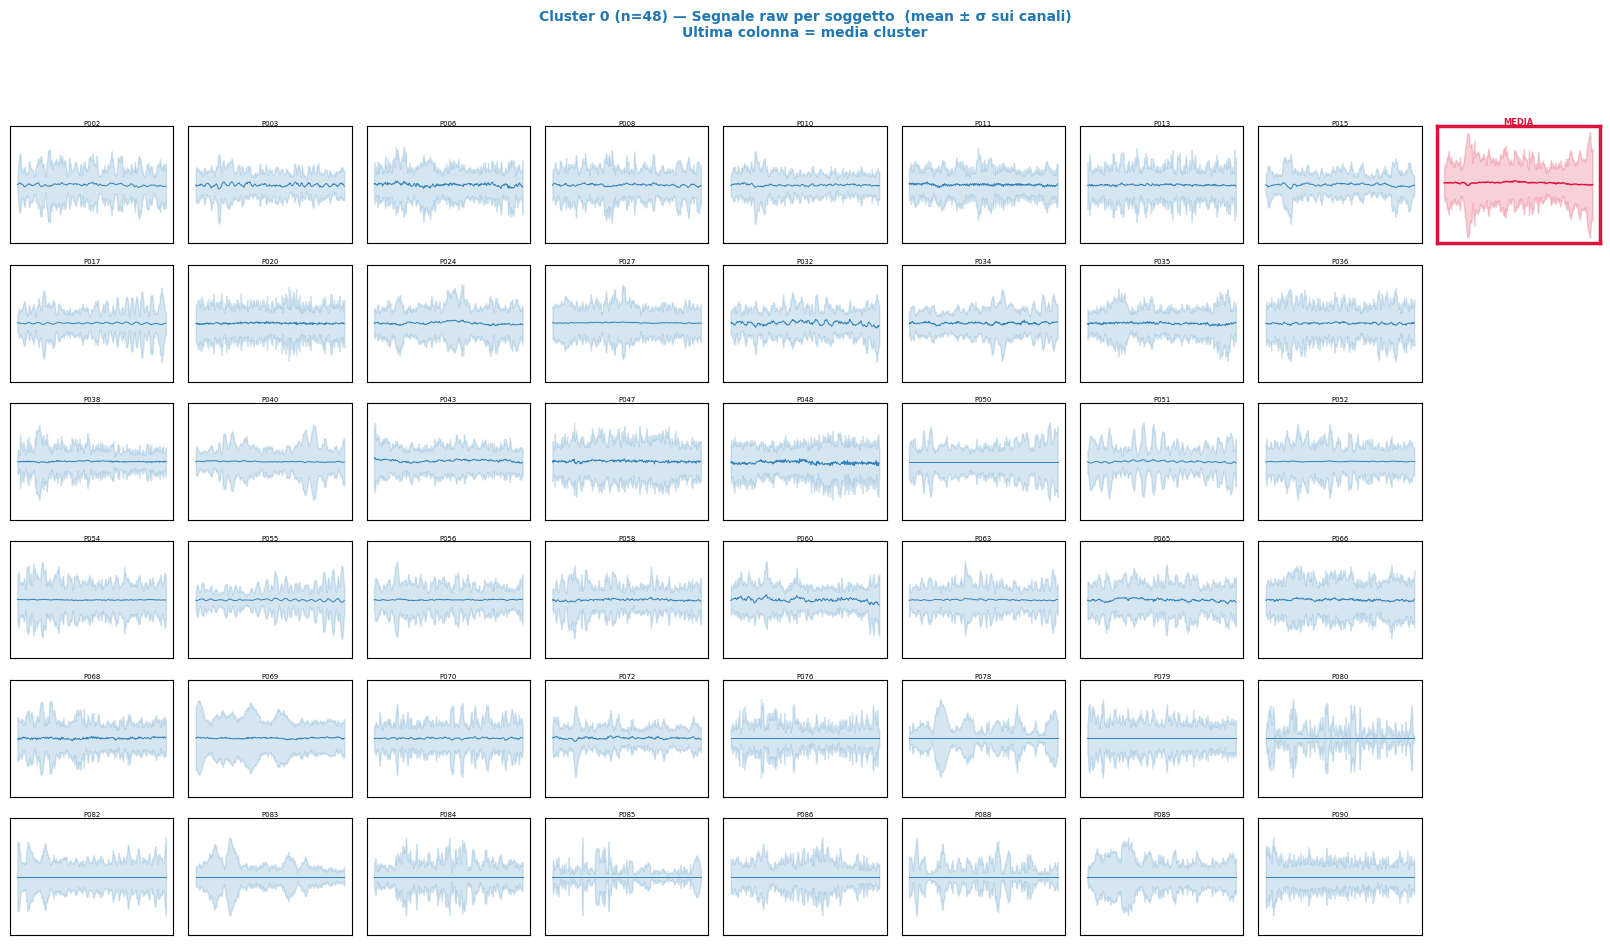

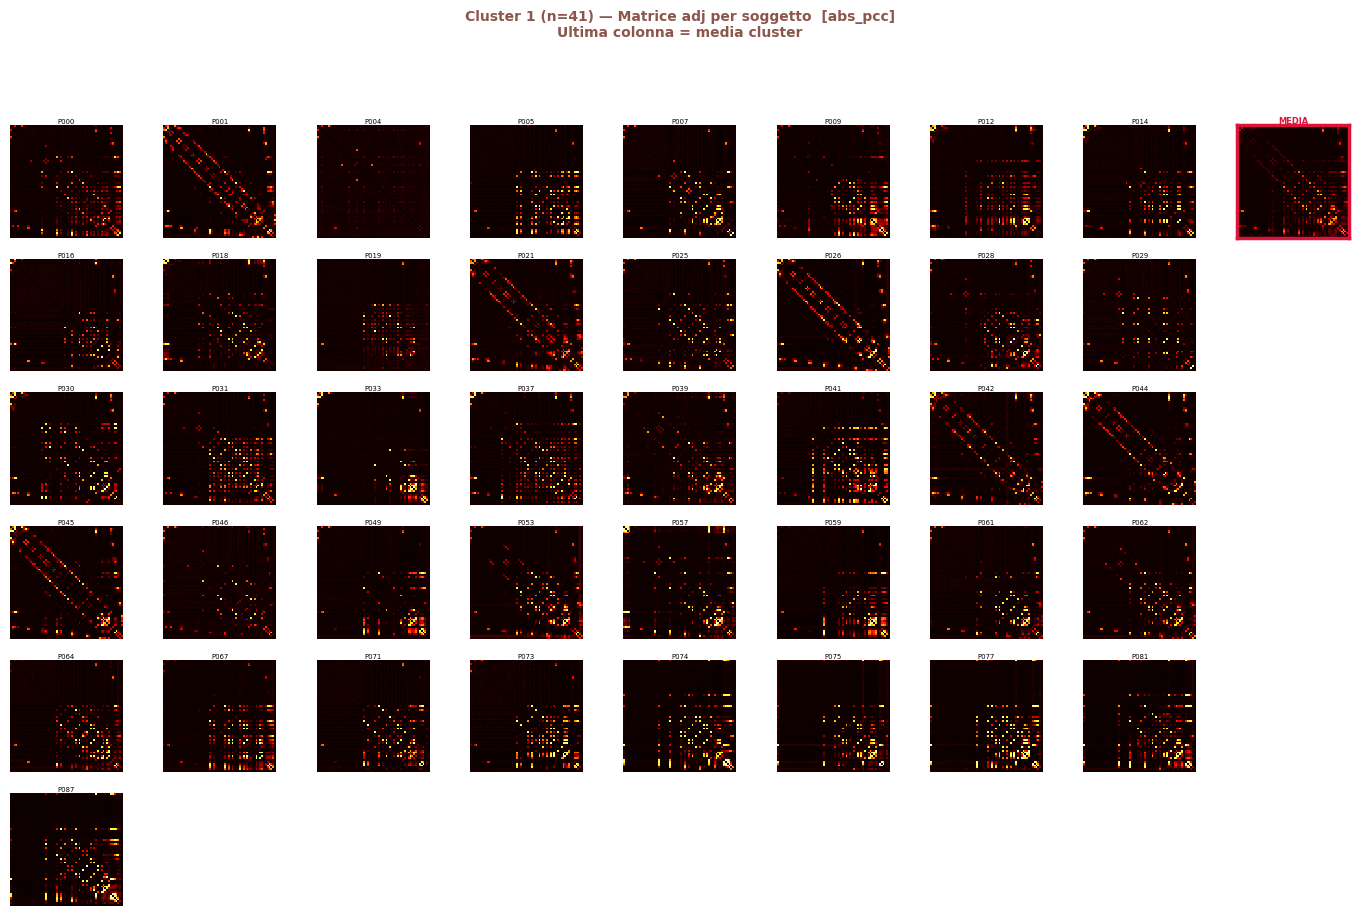

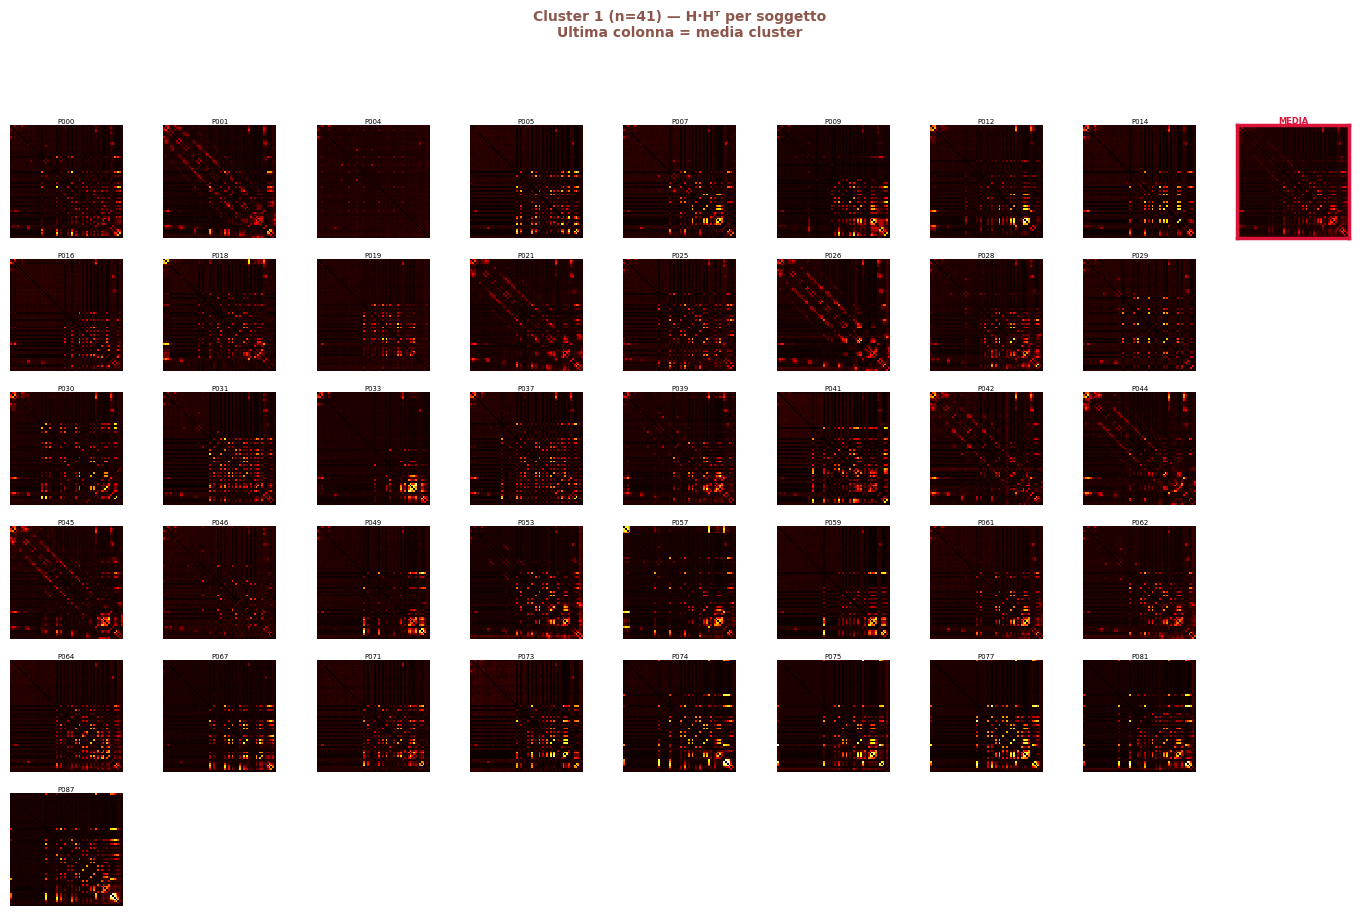

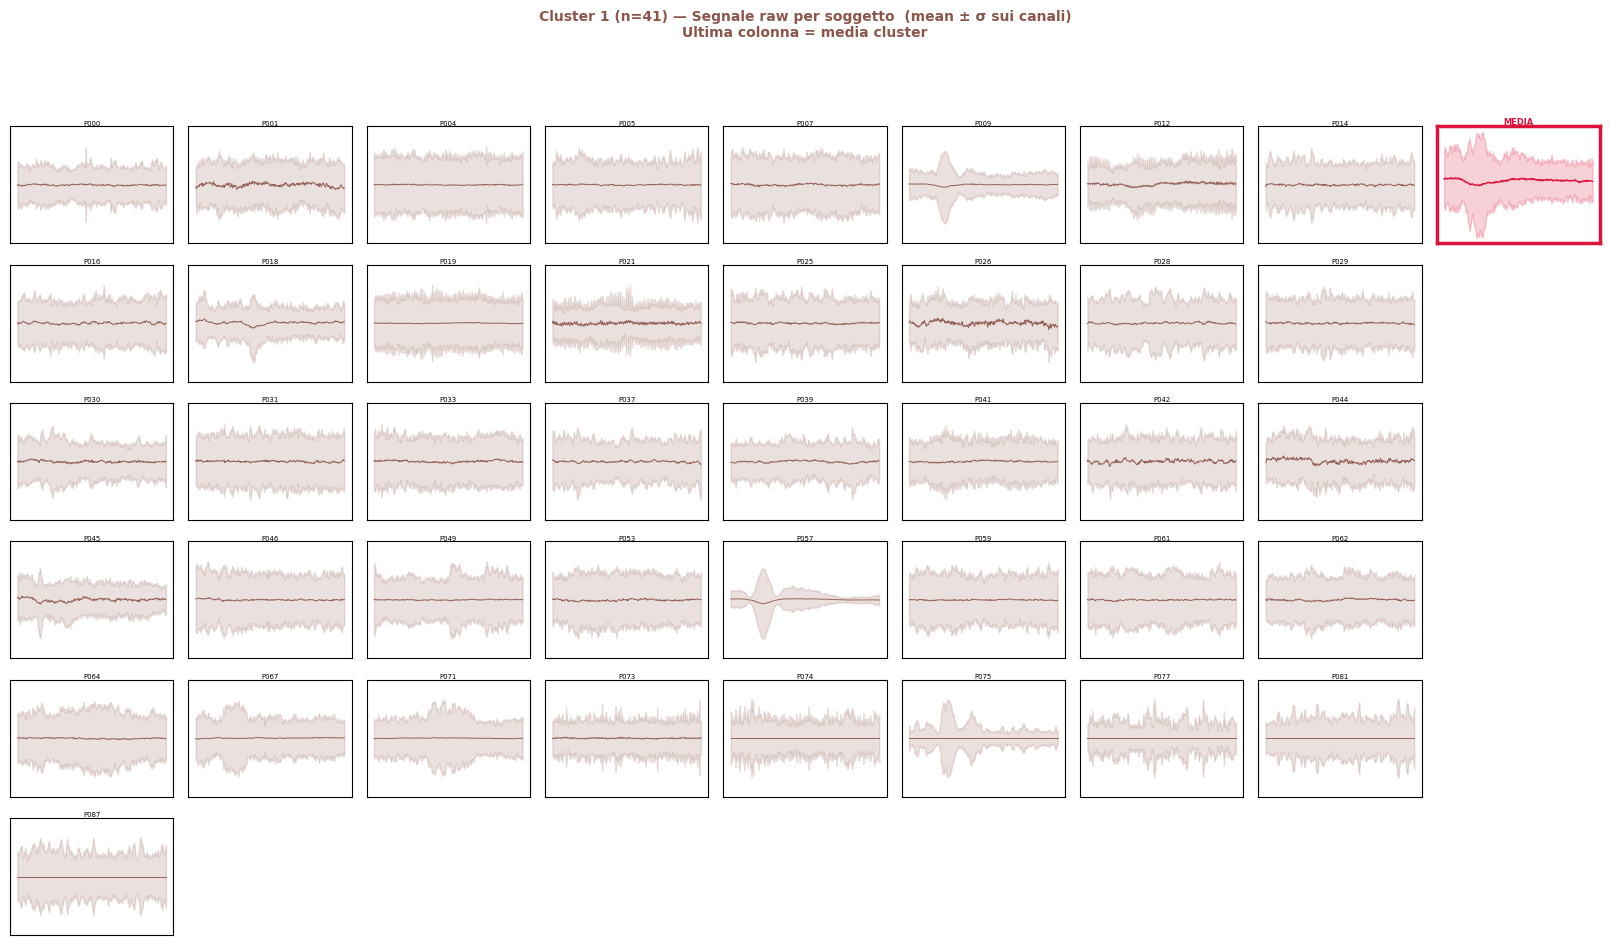

21:06:33 INFO     §11b completato


In [17]:
# §11b — Variabilità intra-cluster: ogni soggetto vs media cluster
# Scopo: capire se il clustering è strutturato o rumore

NCOLS_GRID = 8   # soggetti per riga

for c in range(k_top):
    subj_c  = [SUBJ_TOP[i] for i, l in enumerate(LABELS_TOP) if l == c]
    n_sub   = len(subj_c)
    color_c = COLORS_TOP[c]

    # ── Raccoglie matrici per ogni soggetto ───────────────────────────────────
    adjs_c = []
    hhts_c = []
    raws_c = []
    for sid in subj_c:
        adjs_c.append(vec_to_sym(FEAT_G[SUBJ_G.index(sid)]) if sid in SUBJ_G else None)
        hhts_c.append(vec_to_sym(FEAT_H[SUBJ_H.index(sid)]) if sid in SUBJ_H else None)
        raws_c.append(MEAN_RAW[SUBJ_RAW.index(sid)] if sid in SUBJ_RAW else None)

    n_rows = math.ceil(n_sub / NCOLS_GRID)
    # +1 colonna per la media cluster (ultima)
    ncols_tot = NCOLS_GRID + 1

    # ────────────────────────────────────────────────────────────────────────────
    # FIGURA 1 — Adj matrices
    # ────────────────────────────────────────────────────────────────────────────
    vmax_adj = np.nanpercentile(
        [a.max() for a in adjs_c if a is not None], 95)

    fig_adj, axes_adj = plt.subplots(n_rows, ncols_tot,
                                     figsize=(ncols_tot * 1.55, n_rows * 1.55))
    fig_adj.suptitle(
        f'Cluster {c} (n={n_sub}) — Matrice adj per soggetto  [{METRIC}]\n'
        f'Ultima colonna = media cluster',
        fontsize=10, fontweight='bold', color=color_c
    )
    if n_rows == 1:
        axes_adj = axes_adj[np.newaxis, :]

    for idx, (sid, adj_s) in enumerate(zip(subj_c, adjs_c)):
        row, col = divmod(idx, NCOLS_GRID)
        ax = axes_adj[row, col]
        if adj_s is not None:
            ax.imshow(adj_s, cmap='hot', vmin=0, vmax=vmax_adj, interpolation='nearest')
        ax.set_title(f'P{sid:03d}', fontsize=5, pad=1)
        ax.axis('off')

    # Celle vuote (padding)
    for idx in range(n_sub, n_rows * NCOLS_GRID):
        row, col = divmod(idx, NCOLS_GRID)
        axes_adj[row, col].axis('off')

    # Media cluster: prima riga, ultima colonna — grande
    ax_m = axes_adj[0, -1]
    if cluster_adj[c] is not None:
        ax_m.imshow(cluster_adj[c], cmap='hot', vmin=0, vmax=vmax_adj, interpolation='nearest')
    ax_m.set_title('MEDIA', fontsize=6, fontweight='bold', color='crimson', pad=1)
    for spine in ax_m.spines.values():
        spine.set_linewidth(2.5); spine.set_edgecolor('crimson')
    ax_m.set_xticks([]); ax_m.set_yticks([])
    # Righe rimanenti ultima colonna: nascondi
    for row in range(1, n_rows):
        axes_adj[row, -1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(FIG_DIR / f'eeg16b_intracluster{c}_adj.png', dpi=120, bbox_inches='tight')
    plt.show()

    # ────────────────────────────────────────────────────────────────────────────
    # FIGURA 2 — H·Hᵀ matrices
    # ────────────────────────────────────────────────────────────────────────────
    vmax_hht = np.nanpercentile(
        [h.max() for h in hhts_c if h is not None], 95) if any(h is not None for h in hhts_c) else 1.0

    fig_hht, axes_hht = plt.subplots(n_rows, ncols_tot,
                                     figsize=(ncols_tot * 1.55, n_rows * 1.55))
    fig_hht.suptitle(
        f'Cluster {c} (n={n_sub}) — H·Hᵀ per soggetto\n'
        f'Ultima colonna = media cluster',
        fontsize=10, fontweight='bold', color=color_c
    )
    if n_rows == 1:
        axes_hht = axes_hht[np.newaxis, :]

    for idx, (sid, hht_s) in enumerate(zip(subj_c, hhts_c)):
        row, col = divmod(idx, NCOLS_GRID)
        ax = axes_hht[row, col]
        if hht_s is not None:
            ax.imshow(hht_s, cmap='hot', vmin=0, vmax=vmax_hht, interpolation='nearest')
        ax.set_title(f'P{sid:03d}', fontsize=5, pad=1)
        ax.axis('off')

    for idx in range(n_sub, n_rows * NCOLS_GRID):
        row, col = divmod(idx, NCOLS_GRID)
        axes_hht[row, col].axis('off')

    ax_m2 = axes_hht[0, -1]
    if cluster_hht[c] is not None:
        ax_m2.imshow(cluster_hht[c], cmap='hot', vmin=0, vmax=vmax_hht, interpolation='nearest')
    ax_m2.set_title('MEDIA', fontsize=6, fontweight='bold', color='crimson', pad=1)
    for spine in ax_m2.spines.values():
        spine.set_linewidth(2.5); spine.set_edgecolor('crimson')
    ax_m2.set_xticks([]); ax_m2.set_yticks([])
    for row in range(1, n_rows):
        axes_hht[row, -1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(FIG_DIR / f'eeg16b_intracluster{c}_hht.png', dpi=120, bbox_inches='tight')
    plt.show()

    # ────────────────────────────────────────────────────────────────────────────
    # FIGURA 3 — Raw signal: butterfly plot per soggetto
    # ────────────────────────────────────────────────────────────────────────────
    raws_valid = [(sid, r) for sid, r in zip(subj_c, raws_c) if r is not None]
    if not raws_valid:
        log.warning(f'  Cluster {c}: nessun raw disponibile')
        continue

    n_raw   = len(raws_valid)
    n_rows_r = math.ceil(n_raw / NCOLS_GRID)
    t_axis  = np.arange(N_SAMP) / 256   # secondi

    fig_raw, axes_raw = plt.subplots(n_rows_r, ncols_tot,
                                     figsize=(ncols_tot * 1.8, n_rows_r * 1.6))
    fig_raw.suptitle(
        f'Cluster {c} (n={n_sub}) — Segnale raw per soggetto  (mean ± σ sui canali)\n'
        f'Ultima colonna = media cluster',
        fontsize=10, fontweight='bold', color=color_c
    )
    if n_rows_r == 1:
        axes_raw = axes_raw[np.newaxis, :]

    raw_mean_all = np.mean([r for _, r in raws_valid], axis=0)  # (61, 384)

    for idx, (sid, raw_s) in enumerate(raws_valid):
        row, col = divmod(idx, NCOLS_GRID)
        ax = axes_raw[row, col]
        ch_mean = raw_s.mean(axis=0)        # (384,) media su canali
        ch_std  = raw_s.std(axis=0)         # (384,)
        ax.plot(t_axis, ch_mean, color=color_c, linewidth=0.7, alpha=0.9)
        ax.fill_between(t_axis, ch_mean - ch_std, ch_mean + ch_std,
                        color=color_c, alpha=0.18)
        ax.set_title(f'P{sid:03d}', fontsize=5, pad=1)
        ax.set_xticks([]); ax.set_yticks([])
        ylim = max(abs(ch_mean).max() + ch_std.max(), 0.1)
        ax.set_ylim(-ylim * 1.5, ylim * 1.5)

    for idx in range(n_raw, n_rows_r * NCOLS_GRID):
        row, col = divmod(idx, NCOLS_GRID)
        axes_raw[row, col].axis('off')

    # Media cluster in ultima colonna
    ax_mr = axes_raw[0, -1]
    ch_mean_all = raw_mean_all.mean(axis=0)
    ch_std_all  = raw_mean_all.std(axis=0)
    ax_mr.plot(t_axis, ch_mean_all, color='crimson', linewidth=1.0)
    ax_mr.fill_between(t_axis, ch_mean_all - ch_std_all, ch_mean_all + ch_std_all,
                       color='crimson', alpha=0.2)
    ax_mr.set_title('MEDIA', fontsize=6, fontweight='bold', color='crimson', pad=1)
    for spine in ax_mr.spines.values():
        spine.set_linewidth(2.5); spine.set_edgecolor('crimson')
    ax_mr.set_xticks([]); ax_mr.set_yticks([])
    for row in range(1, n_rows_r):
        axes_raw[row, -1].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(FIG_DIR / f'eeg16b_intracluster{c}_raw.png', dpi=120, bbox_inches='tight')
    plt.show()

log.info('§11b completato')


## §12 — Multi-metrica: clustering con wpli e plv (k=2 forzato)

Robustezza della separazione C0/C1 alle diverse metriche di connettività.

21:06:34 INFO     abs_pcc: cache caricata (91 soggetti)
21:06:34 INFO       abs_pcc: k=2  sil=0.230  sizes={np.int32(0): np.int64(43), np.int32(1): np.int64(46)}


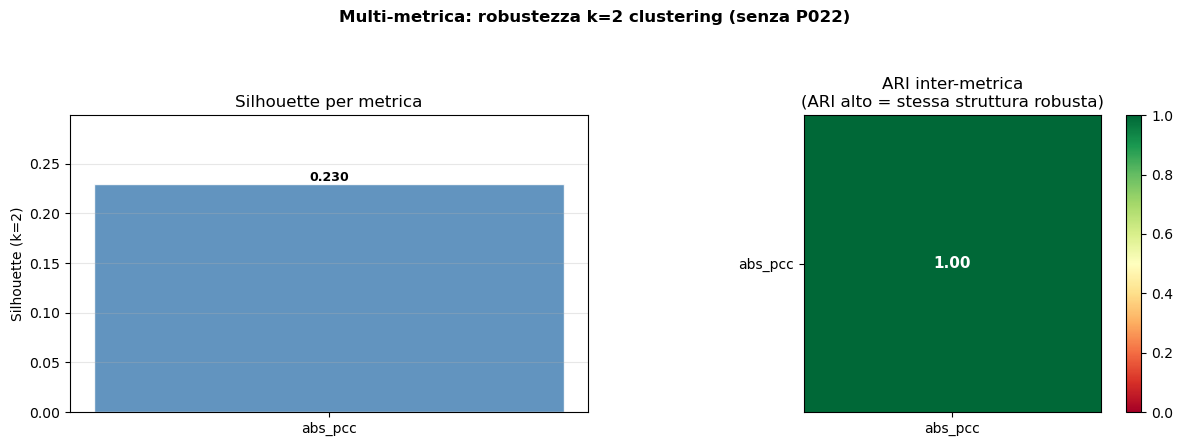

In [18]:
METRICS_COMPARE = ['abs_pcc']   # solo abs_pcc sul server (wpli/plv non rigenerati)
ALL_FEATS_G  = {}
ALL_FEATS_H  = {}
ALL_LABELS_M = {}
ALL_SUBJ_M   = {}
ALL_SIL_M    = {}

for m in METRICS_COMPARE:
    cache = CKPT_DIR / f'feat_graph_{m}.npz'
    if cache.exists():
        _c = np.load(cache)
        feats, subjs = _c['feats'], _c['subj_ids'].tolist()
        log.info(f'{m}: cache caricata ({len(subjs)} soggetti)')
    else:
        log.info(f'{m}: calcolo feature...')
        idx_m = build_index(m)
        feat_list, subj_list = [], []
        for sid in tqdm(sorted(idx_m.keys()), desc=m, leave=False):
            adjs = []
            for p in idx_m[sid]:
                try:
                    d = torch.load(p, weights_only=False)
                    adj = d['adj'].float().numpy()
                    if adj.shape == (N_CHAN, N_CHAN):
                        adjs.append(adj)
                except Exception:
                    continue
            if len(adjs) >= 10:
                feat_list.append(np.mean(adjs, axis=0)[triu_idx])
                subj_list.append(sid)
        feats = np.array(feat_list); subjs = subj_list
        np.savez(cache, feats=feats, subj_ids=np.array(subjs))
    ALL_FEATS_G[m] = (feats, subjs)

    hg_cache = CKPT_DIR / f'feat_hg_{m}.npz'
    if hg_cache.exists():
        _hc = np.load(hg_cache)
        hht_feats, hht_subjs = _hc['feats'], _hc['subj_ids'].tolist()
    else:
        hht_feats, hht_subjs = np.zeros((0, N_TRIU)), []
    ALL_FEATS_H[m] = (hht_feats, hht_subjs)

    # Filtra soggetti esclusi
    feats_f, subjs_f = filter_subj(feats, subjs, EXCLUDE_SUBJ)

    # Clustering k=2 forzato
    X = StandardScaler().fit_transform(feats_f)
    Z = PCA(n_components=min(20, len(subjs_f) - 1), random_state=RANDOM_SEED).fit_transform(X)
    labels = KMeans(n_clusters=K_FORCED, n_init=30, random_state=RANDOM_SEED).fit_predict(Z)
    sil    = silhouette_score(Z, labels)
    ALL_LABELS_M[m] = labels
    ALL_SUBJ_M[m]   = subjs_f
    ALL_SIL_M[m]    = sil
    log.info(f'  {m}: k=2  sil={sil:.3f}  sizes={dict(zip(*np.unique(labels, return_counts=True)))}')

# ── ARI inter-metrica ─────────────────────────────────────────────────────────
n_m = len(METRICS_COMPARE)
ARI_MAT = np.zeros((n_m, n_m))
for i, m1 in enumerate(METRICS_COMPARE):
    for j, m2 in enumerate(METRICS_COMPARE):
        common = sorted(set(ALL_SUBJ_M[m1]) & set(ALL_SUBJ_M[m2]))
        l1 = np.array([ALL_LABELS_M[m1][ALL_SUBJ_M[m1].index(s)] for s in common])
        l2 = np.array([ALL_LABELS_M[m2][ALL_SUBJ_M[m2].index(s)] for s in common])
        ARI_MAT[i, j] = adjusted_rand_score(l1, l2)

for i, m1 in enumerate(METRICS_COMPARE):
    for j, m2 in enumerate(METRICS_COMPARE):
        if j > i:
            log.info(f'  {m1} vs {m2}: ARI={ARI_MAT[i,j]:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
COL_M = ['steelblue', 'darkorange', 'forestgreen']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Multi-metrica: robustezza k=2 clustering (senza P022)', fontsize=12, fontweight='bold')

ax = axes[0]
sils = [ALL_SIL_M[m] for m in METRICS_COMPARE]
bars = ax.bar(METRICS_COMPARE, sils, color=COL_M, alpha=0.85, edgecolor='white', width=0.5)
for bar, s in zip(bars, sils):
    ax.text(bar.get_x() + bar.get_width() / 2, s + 0.003, f'{s:.3f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Silhouette (k=2)'); ax.set_title('Silhouette per metrica')
ax.set_ylim(0, max(sils) * 1.3); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
im = ax2.imshow(ARI_MAT, cmap='RdYlGn', vmin=0, vmax=1)
plt.colorbar(im, ax=ax2, fraction=0.046)
ax2.set_xticks(range(n_m)); ax2.set_xticklabels(METRICS_COMPARE)
ax2.set_yticks(range(n_m)); ax2.set_yticklabels(METRICS_COMPARE)
ax2.set_title('ARI inter-metrica\n(ARI alto = stessa struttura robusta)')
for i in range(n_m):
    for j in range(n_m):
        ax2.text(j, i, f'{ARI_MAT[i,j]:.2f}', ha='center', va='center',
                 fontsize=11, fontweight='bold',
                 color='white' if ARI_MAT[i, j] > 0.6 else 'black')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16b_multimetric_ari.png', dpi=150, bbox_inches='tight')
plt.show()

## §13 — Mappa differenza cluster: C1 − C0 per metrica

Per ogni metrica di connettività: heatmap differenza adj e H·Hᵀ.

21:06:34 INFO     C0 (n=48) vs C1 (n=41)


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

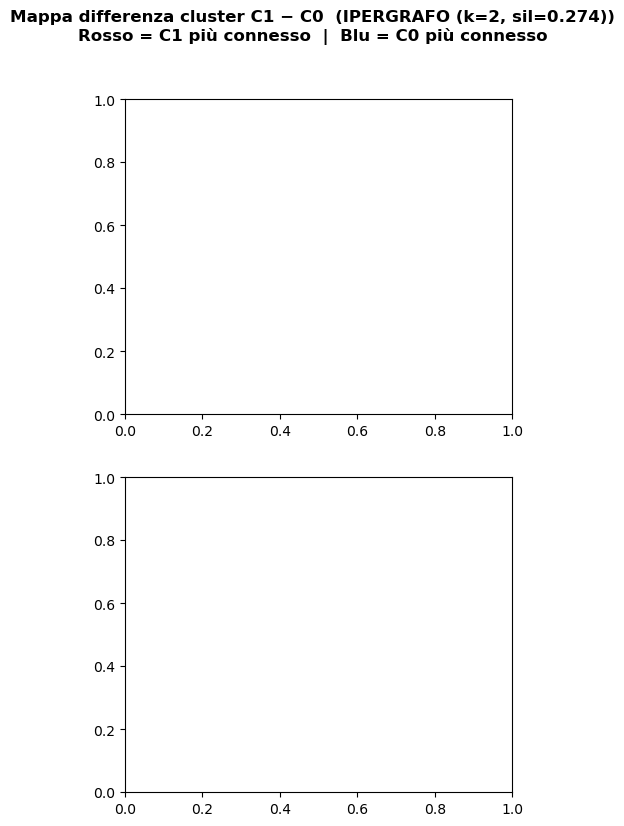

In [19]:
c_a, c_b = 0, 1   # k=2 forzato: sempre C0 vs C1
log.info(f'C{c_a} (n={(LABELS_TOP==c_a).sum()}) vs C{c_b} (n={(LABELS_TOP==c_b).sum()})')

def cluster_mean_mat_m(feats, subjs, cluster_idx):
    """Matrice media per cluster usando LABELS_TOP/SUBJ_TOP."""
    subj_c = [SUBJ_TOP[i] for i in range(len(SUBJ_TOP)) if LABELS_TOP[i] == cluster_idx]
    mats   = [vec_to_sym(feats[subjs.index(s)]) for s in subj_c if s in subjs]
    return np.mean(mats, axis=0) if mats else None

n_met = len(METRICS_COMPARE)
fig, axes = plt.subplots(2, n_met, figsize=(5 * n_met, 9))
fig.suptitle(
    f'Mappa differenza cluster C{c_b} − C{c_a}  ({top_src})\n'
    f'Rosso = C{c_b} più connesso  |  Blu = C{c_a} più connesso',
    fontsize=12, fontweight='bold'
)

for col, m in enumerate(METRICS_COMPARE):
    feats_m, subjs_m = ALL_FEATS_G[m]
    # Filtra P022 dalle feature per questa metrica
    feats_mf, subjs_mf = filter_subj(feats_m, subjs_m, EXCLUDE_SUBJ)
    adj_a = cluster_mean_mat_m(feats_mf, subjs_mf, c_a)
    adj_b = cluster_mean_mat_m(feats_mf, subjs_mf, c_b)

    ax = axes[0, col]
    if adj_a is not None and adj_b is not None:
        diff  = adj_b - adj_a
        d_lim = np.abs(diff).max() * 0.9
        im = ax.imshow(diff, cmap='RdBu_r', vmin=-d_lim, vmax=d_lim, interpolation='nearest')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        ax.set_title(f'{m}\nadj  C{c_b}−C{c_a}', fontsize=9, fontweight='bold')
    ax.axis('off')

    ax2 = axes[1, col]
    if m in ALL_FEATS_H:
        _hht_feats, _hht_subjs = ALL_FEATS_H[m]
        if len(_hht_feats) > 0:
            hf, hs = filter_subj(_hht_feats, _hht_subjs, EXCLUDE_SUBJ)
            hht_a = cluster_mean_mat_m(hf, hs, c_a)
            hht_b = cluster_mean_mat_m(hf, hs, c_b)
            if hht_a is not None and hht_b is not None:
                diff_h = hht_b - hht_a
                d_h    = np.abs(diff_h).max() * 0.9
                im2 = ax2.imshow(diff_h, cmap='RdBu_r', vmin=-d_h, vmax=d_h, interpolation='nearest')
                plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.03)
                ax2.set_title(f'{m}\nH·Hᵀ  C{c_b}−C{c_a}', fontsize=9, fontweight='bold')
            else:
                ax2.text(0.5, 0.5, 'N/D', ha='center', va='center', transform=ax2.transAxes)
        else:
            ax2.text(0.5, 0.5, 'Cache H·Hᵀ\nnon trovata', ha='center', va='center',
                     transform=ax2.transAxes, fontsize=9, color='grey', style='italic')
    ax2.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16b_cluster_diff_map_multimetric.png', dpi=150, bbox_inches='tight')
plt.show()

## §14 — Metriche qualità segnale per cluster (k=2, senza P022)

Varianza, kurtosi, potenza gamma 30-60 Hz per C0 vs C1.
Se differiscono → la separazione è driven da qualità segnale (artefatti), non da IS.

14:02:41 INFO     Soggetti con qualità segnale: 73


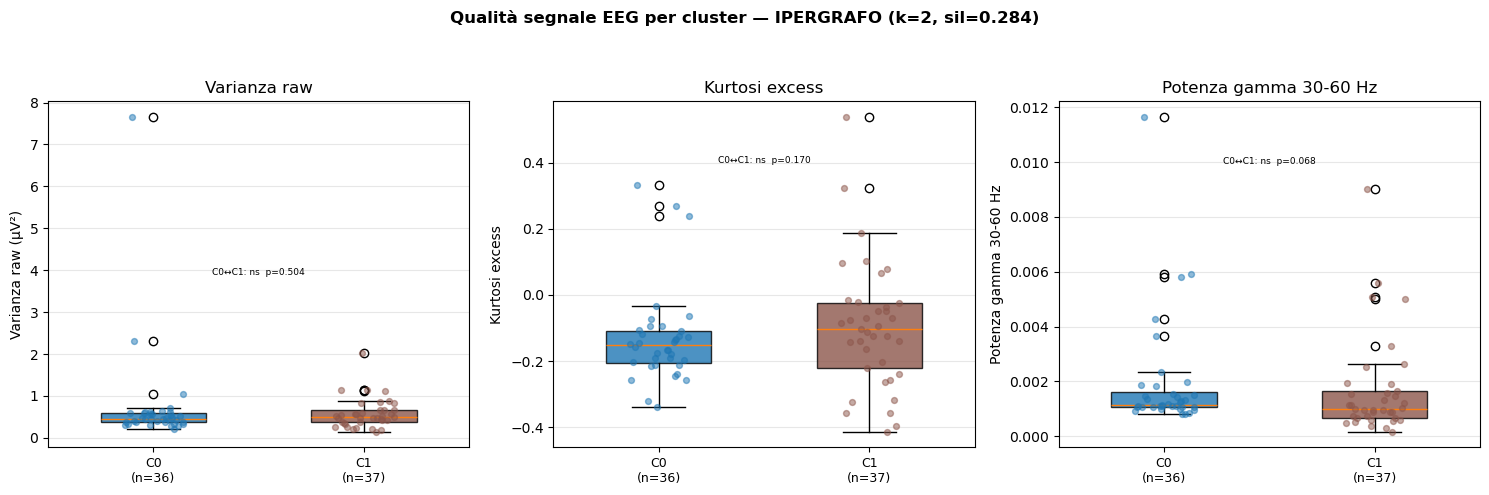


── Qualità segnale per cluster (IPERGRAFO (k=2, sil=0.284)) ──

  Cluster 0  (n=36):
    Varianza raw (µV²): mean=0.7202  std=1.2375  [0.2179, 7.6547]
    Kurtosi excess: mean=-0.1315  std=0.1430  [-0.3394, 0.3322]
    Potenza gamma 30-60 Hz: mean=0.0019  std=0.0021  [0.0008, 0.0116]

  Cluster 1  (n=37):
    Varianza raw (µV²): mean=0.5789  std=0.3594  [0.1510, 2.0362]
    Kurtosi excess: mean=-0.0972  std=0.1945  [-0.4134, 0.5382]
    Potenza gamma 30-60 Hz: mean=0.0017  std=0.0018  [0.0002, 0.0090]


In [ ]:
from scipy.stats import kurtosis as scipy_kurtosis
from scipy.signal import welch

FS         = 256
GAMMA_LOW  = 30
GAMMA_HIGH = 60

# ── Calcola metriche qualità per soggetto ─────────────────────────────────────
rows_q = []
for i, sid in enumerate(SUBJ_RAW):
    x = MEAN_RAW[i]   # (61, 384)

    var_mean   = float(np.var(x, axis=1).mean())
    kurt_mean  = float(np.mean(scipy_kurtosis(x, axis=1, fisher=True)))

    gamma_pows = []
    for ch in range(N_CHAN):
        f, psd = welch(x[ch], fs=FS, nperseg=min(128, N_SAMP))
        mask   = (f >= GAMMA_LOW) & (f <= GAMMA_HIGH)
        gamma_pows.append(float(psd[mask].mean()) if mask.any() else 0.0)
    gamma_mean = float(np.mean(gamma_pows))

    rows_q.append({'sid': sid, 'variance': var_mean,
                   'kurtosis': kurt_mean, 'gamma_power': gamma_mean})

df_qual = pd.DataFrame(rows_q)
df_qual['cluster'] = df_qual['sid'].apply(
    lambda s: int(LABELS_TOP[SUBJ_TOP.index(s)]) if s in SUBJ_TOP else np.nan
)
df_qual.dropna(subset=['cluster'], inplace=True)
df_qual['cluster'] = df_qual['cluster'].astype(int)
log.info(f'Soggetti con qualità segnale: {len(df_qual)}')

# ── Boxplot 1×3 ───────────────────────────────────────────────────────────────
QUAL_COLS = [
    ('variance',    'Varianza raw (µV²)'),
    ('kurtosis',    'Kurtosi excess'),
    ('gamma_power', 'Potenza gamma 30-60 Hz'),
]
COLORS_TOP_Q = plt.cm.tab10(np.linspace(0, 0.5, k_top))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Qualità segnale EEG per cluster — {top_src}', fontsize=12, fontweight='bold')

for ax, (col, label) in zip(axes, QUAL_COLS):
    data = [df_qual[df_qual['cluster'] == c][col].values for c in range(k_top)]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.5, notch=False)
    for patch, color in zip(bp['boxes'], COLORS_TOP_Q):
        patch.set_facecolor(color); patch.set_alpha(0.8)

    # Overlay punti
    for c, d in enumerate(data):
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(d))
        ax.scatter(np.full(len(d), c + 1) + jitter, d,
                   color=COLORS_TOP_Q[c], s=18, alpha=0.5, zorder=3)

    ax.set_xticklabels([f'C{c}\n(n={len(data[c])})' for c in range(k_top)], fontsize=9)
    ax.set_title(label.split(' (')[0]); ax.set_ylabel(label)
    ax.grid(axis='y', alpha=0.3)

    # p-value Mann-Whitney su tutte le coppie
    all_flat = np.concatenate([d for d in data if len(d)])
    y_top = np.percentile(all_flat, 99) if len(all_flat) else 1
    for off, (ci, cj) in enumerate([(ci, cj) for ci in range(k_top) for cj in range(ci+1, k_top)]):
        if len(data[ci]) >= 2 and len(data[cj]) >= 2:
            _, pval = mannwhitneyu(data[ci], data[cj], alternative='two-sided')
            star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
            ax.annotate(f'C{ci}↔C{cj}: {star}  p={pval:.3f}',
                        xy=((ci + cj) / 2 + 1, y_top * (1.02 + 0.06 * off)),
                        fontsize=6.5, ha='center')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(FIG_DIR / 'eeg16_signal_quality_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Stampa stats ──────────────────────────────────────────────────────────────
print(f'\n── Qualità segnale per cluster ({top_src}) ──')
for c in range(k_top):
    sub = df_qual[df_qual['cluster'] == c]
    print(f'\n  Cluster {c}  (n={len(sub)}):')
    for col, label in QUAL_COLS:
        print(f'    {label}: mean={sub[col].mean():.4f}  std={sub[col].std():.4f}'
              f'  [{sub[col].min():.4f}, {sub[col].max():.4f}]')


## §15 — Mappa cervello: topomap + grafo connettività C0 vs C1

Visualizzazione topografica sulla superficie del cranio delle differenze di connettività tra i due cluster.

**Riga 1 — Topomaps** (interpolazione continua sulla calotta cranica):
- C0: forza media di ogni nodo (media riga adj_C0)
- C1: forza media di ogni nodo (media riga adj_C1)
- Differenza C1−C0: rosso = C1 più connesso, blu = C0

**Riga 2 — Grafi di connettività** (top N edges disegnati sulla proiezione 2D):
- C0: top 30 connessioni più forti
- C1: top 30 connessioni più forti
- Differenza: edges dove C1>C0 (rosso) e C0>C1 (blu)

14:02:41 WARNING    FPz (E48) non trovato nel montage
14:02:41 INFO     Topomap canali: 58  |  Connectivity canali: 60
14:02:41 WARNING  plot_topomap fallito (plot_topomap() got an unexpected keyword argument 'vmin') — fallback scatter
14:02:41 WARNING  plot_topomap fallito (plot_topomap() got an unexpected keyword argument 'vmin') — fallback scatter
14:02:42 WARNING  plot_topomap fallito (plot_topomap() got an unexpected keyword argument 'vmin') — fallback scatter


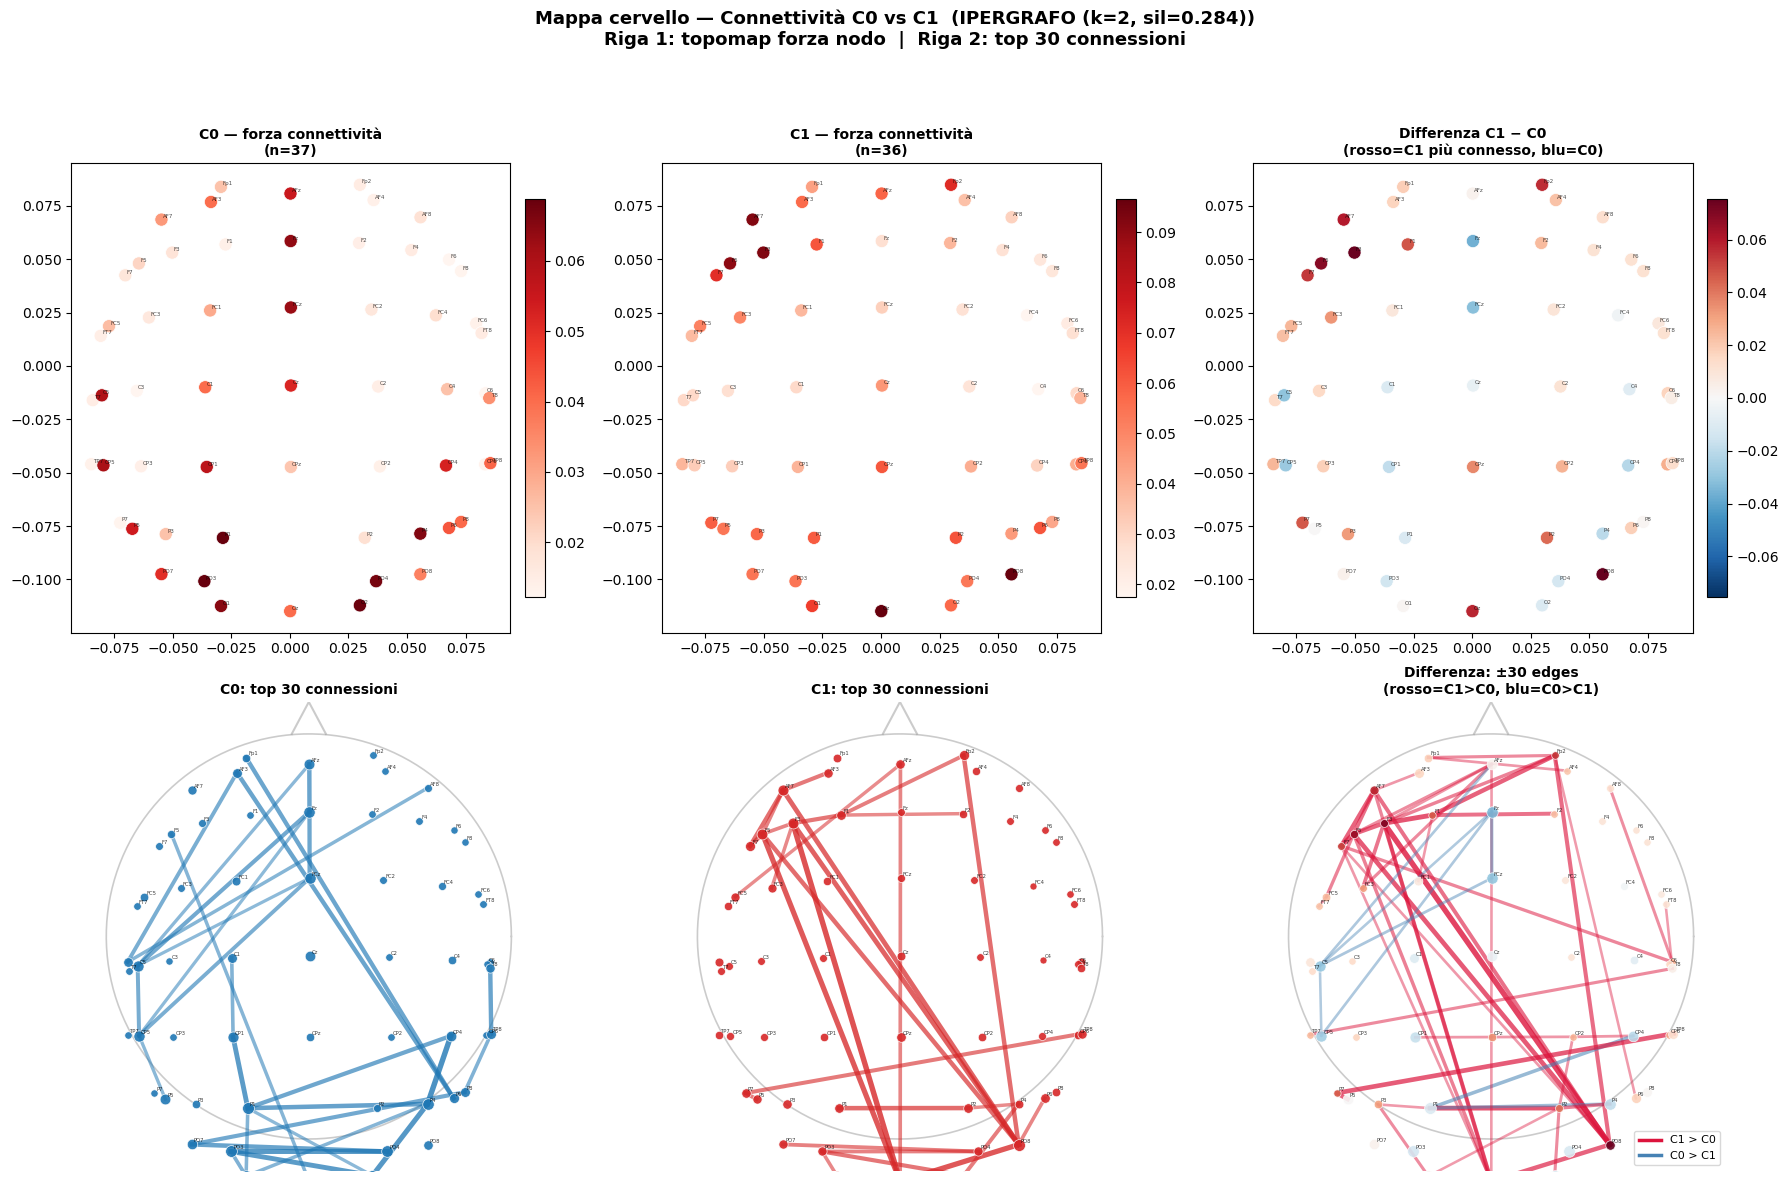

14:02:43 INFO     §15 brain connectivity map salvato


In [ ]:
# §15 — Mappa cervello: topomap + grafo connettività C0 vs C1
import mne
from matplotlib.lines import Line2D

# Fallback per variabili globali (se cella girata stand-alone)
if 'N_CHAN' not in dir():
    N_CHAN = 61
if 'triu_idx' not in dir():
    triu_idx = np.triu_indices(N_CHAN, k=1)


# ── Nomi canali con alias MNE-compatibili ─────────────────────────────────────
# T3→T7, T4→T8, T5→P7, T6→P8, FP2→Fp2 già nel mapping standard
CHAN_NAMES_MNE = [
    'A1','AF7','AF3','Fp1','Fp2','AF4','AF8','A2',      # E00-E07
    'F7', 'F5', 'F3', 'F1', 'F2', 'F4', 'F6', 'F8',   # E08-E15
    'FT7','FC5','FC3','FC1','FC2','FC4','FC6','FT8',    # E16-E23
    'T7', 'C5', 'C3', 'C1', 'C2', 'C4', 'C6', 'T8',   # E24-E31
    'TP7','CP5','CP3','CP1','CP2','CP4','CP6','TP8',    # E32-E39
    'P7', 'P5', 'P3', 'P1', 'P2', 'P4', 'P6', 'P8',   # E40-E47
    'FPz','PO7','PO3','O1', 'O2', 'PO4','PO8','Oz',    # E48-E55
    'AFz','Fz', 'FCz','Cz', 'CPz'                      # E56-E60
]
assert len(CHAN_NAMES_MNE) == N_CHAN

# A1/A2 = mastoid reference — nessuna posizione in standard_1020
SKIP_TOPOMAP   = {0, 7}
MASTOID_APPROX = {0: (-0.085, -0.012), 7: (0.085, -0.012)}

montage = mne.channels.make_standard_montage('standard_1020')
pos3d_d = montage.get_positions()['ch_pos']

elec_xy = np.full((N_CHAN, 2), np.nan)
for e_idx, ch in enumerate(CHAN_NAMES_MNE):
    if e_idx in MASTOID_APPROX:
        elec_xy[e_idx] = MASTOID_APPROX[e_idx]
    elif ch in pos3d_d:
        p = pos3d_d[ch]
        elec_xy[e_idx] = [p[0], p[1]]
    else:
        log.warning(f'  {ch} (E{e_idx:02d}) non trovato nel montage')

# Maschera topomap (esclude mastoid A1/A2)
topo_mask = np.array([e not in SKIP_TOPOMAP and not np.isnan(elec_xy[e, 0])
                      for e in range(N_CHAN)])
topo_idx  = np.where(topo_mask)[0]
topo_pos  = elec_xy[topo_idx]   # (n_topo, 2) in metres

# Maschera connectivity (include tutto ciò che ha posizione valida)
conn_mask = ~np.isnan(elec_xy[:, 0])
conn_idx  = np.where(conn_mask)[0]
conn_pos  = elec_xy[conn_idx]
orig2conn = {orig: i for i, orig in enumerate(conn_idx)}

log.info(f'Topomap canali: {topo_mask.sum()}  |  Connectivity canali: {conn_mask.sum()}')

# Forza media per nodo (media riga matrice adj)
strength_C0 = adj_C0.mean(axis=1)
strength_C1 = adj_C1.mean(axis=1)
TOP_EDGES   = 30

# ── Funzione topomap MNE ──────────────────────────────────────────────────────
def draw_topo(ax, values, title, cmap='Reds', sym=False):
    data_t = values[topo_idx]
    if sym:
        vlim = np.abs(data_t).max() * 0.95 + 1e-10
        vmin, vmax = -vlim, vlim
    else:
        vmin = np.percentile(data_t, 2)
        vmax = np.percentile(data_t, 98) + 1e-10
    try:
        mne.viz.plot_topomap(
            data_t, topo_pos, axes=ax, show=False,
            cmap=cmap, vmin=vmin, vmax=vmax,
            contours=4, extrapolate='head',
            outlines='head', image_interp='cubic',
        )
        cb_im = ax.images[0] if ax.images else None
        if cb_im is not None:
            plt.colorbar(cb_im, ax=ax, fraction=0.046, pad=0.03, shrink=0.85)
    except Exception as e:
        log.warning(f'plot_topomap fallito ({e}) — fallback scatter')
        sc = ax.scatter(topo_pos[:, 0], topo_pos[:, 1], c=data_t,
                        cmap=cmap, vmin=vmin, vmax=vmax, s=90, zorder=3,
                        edgecolors='white', linewidths=0.5)
        for i, e_idx in enumerate(topo_idx):
            ax.annotate(CHAN_NAMES_MNE[e_idx], topo_pos[i], fontsize=4,
                        xytext=(1, 1), textcoords='offset points', alpha=0.7)
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.03, shrink=0.85)
    ax.set_title(title, fontsize=10, fontweight='bold')

# ── Funzione grafo connettività ───────────────────────────────────────────────
def draw_conn(ax, adj_mat, title, edge_color='#1f77b4',
              sym_diff=False, diff_mat=None):
    r_head = 0.095
    ax.set_aspect('equal')
    margin = 0.015
    ax.set_xlim(-r_head - margin, r_head + margin)
    ax.set_ylim(-r_head - margin, r_head + margin)
    ax.axis('off')

    # Testa + naso
    th = np.linspace(0, 2 * np.pi, 300)
    ax.plot(r_head * np.cos(th), r_head * np.sin(th),
            color='#999999', lw=1.2, alpha=0.5, zorder=0)
    nose_x = np.array([-0.008, 0, 0.008])
    nose_y = np.array([r_head, r_head + 0.015, r_head])
    ax.plot(nose_x, nose_y, color='#999999', lw=1.5, alpha=0.5, zorder=0)

    # Matrice di riferimento per threshold
    ref = diff_mat if (sym_diff and diff_mat is not None) else adj_mat
    upper_ref = np.abs(np.triu(ref, k=1))
    flat_v    = upper_ref.flatten()
    if flat_v.max() < 1e-10:
        ax.set_title(title + '\n(nessun edge)', fontsize=10)
        return
    n_edges_show = min(TOP_EDGES * (2 if sym_diff else 1), int((flat_v > 0).sum()) - 1)
    thresh  = np.sort(flat_v)[::-1][n_edges_show]
    max_v   = flat_v.max()

    # Edges
    for i in range(N_CHAN):
        for j in range(i + 1, N_CHAN):
            w = abs(ref[i, j])
            if w < thresh:
                continue
            if i not in orig2conn or j not in orig2conn:
                continue
            xi, yi = conn_pos[orig2conn[i]]
            xj, yj = conn_pos[orig2conn[j]]
            alpha_e = float(0.15 + 0.65 * (w / max_v))
            lw_e    = float(0.4  + 3.5  * (w / max_v))
            col_e   = ('crimson' if ref[i, j] > 0 else 'steelblue') if sym_diff else edge_color
            ax.plot([xi, xj], [yi, yj], '-', color=col_e,
                    alpha=alpha_e, linewidth=lw_e, zorder=1)

    # Nodi
    node_s  = adj_mat.mean(axis=1)
    ns_max  = node_s.max() + 1e-10
    nv_lim  = np.abs(net_diff_per_elec).max() + 1e-10
    nc_map  = plt.cm.RdBu_r

    for e_idx in conn_idx:
        x, y = conn_pos[orig2conn[e_idx]]
        size = float(18 + 55 * (node_s[e_idx] / ns_max))
        if sym_diff:
            nv    = net_diff_per_elec[e_idx]
            c_node = nc_map(0.5 + 0.5 * nv / nv_lim)
        else:
            c_node = edge_color
        ax.scatter(x, y, s=size, c=[c_node], alpha=0.9, zorder=3,
                   edgecolors='white', linewidths=0.5)
        if e_idx not in SKIP_TOPOMAP:
            ax.annotate(CHAN_NAMES_MNE[e_idx], (x, y), fontsize=3.8,
                        xytext=(1.5, 1.5), textcoords='offset points',
                        alpha=0.75, zorder=4)

    ax.set_title(title, fontsize=10, fontweight='bold')

# ── Layout 2×3 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    f'Mappa cervello — Connettività C0 vs C1  ({top_src})\n'
    f'Riga 1: topomap forza nodo  |  Riga 2: top {TOP_EDGES} connessioni',
    fontsize=13, fontweight='bold'
)

# Riga 0 — topomaps
draw_topo(axes[0, 0], strength_C0,
          f'C0 — forza connettività\n(n={n_c0})', cmap='Reds')
draw_topo(axes[0, 1], strength_C1,
          f'C1 — forza connettività\n(n={n_c1})', cmap='Reds')
draw_topo(axes[0, 2], net_diff_per_elec,
          'Differenza C1 − C0\n(rosso=C1 più connesso, blu=C0)', cmap='RdBu_r', sym=True)

# Riga 1 — connectivity graphs
draw_conn(axes[1, 0], adj_C0,
          f'C0: top {TOP_EDGES} connessioni', edge_color='#1f77b4')
draw_conn(axes[1, 1], adj_C1,
          f'C1: top {TOP_EDGES} connessioni', edge_color='#d62728')
draw_conn(axes[1, 2], adj_C0,
          f'Differenza: ±{TOP_EDGES} edges\n(rosso=C1>C0, blu=C0>C1)',
          sym_diff=True, diff_mat=diff_adj)

# Legenda pannello differenza
axes[1, 2].legend(
    handles=[Line2D([0],[0], color='crimson',   lw=2.5, label='C1 > C0'),
             Line2D([0],[0], color='steelblue', lw=2.5, label='C0 > C1')],
    loc='lower right', fontsize=8, framealpha=0.75
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(FIG_DIR / 'eeg16b_brain_connectivity_map.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('§15 brain connectivity map salvato')

## §16 — Per-soggetto: node strength su cervello vs media cluster

Per ogni soggetto dentro C0 e C1: mini-mappa del cervello con la **forza di connettività per elettrodo** (= media riga della matrice adj). Ultima colonna = media cluster (bordo rosso).

**Fig A** — Forza assoluta: se il clustering è vero, i soggetti dello stesso cluster devono sembrare simili.

**Fig B** — Deviazione dalla media: `adj_s.mean(axis=1) − adj_mean_c.mean(axis=1)`. Rosso = soggetto più connesso della media, blu = meno connesso. Mostra chi è atipico dentro il cluster.

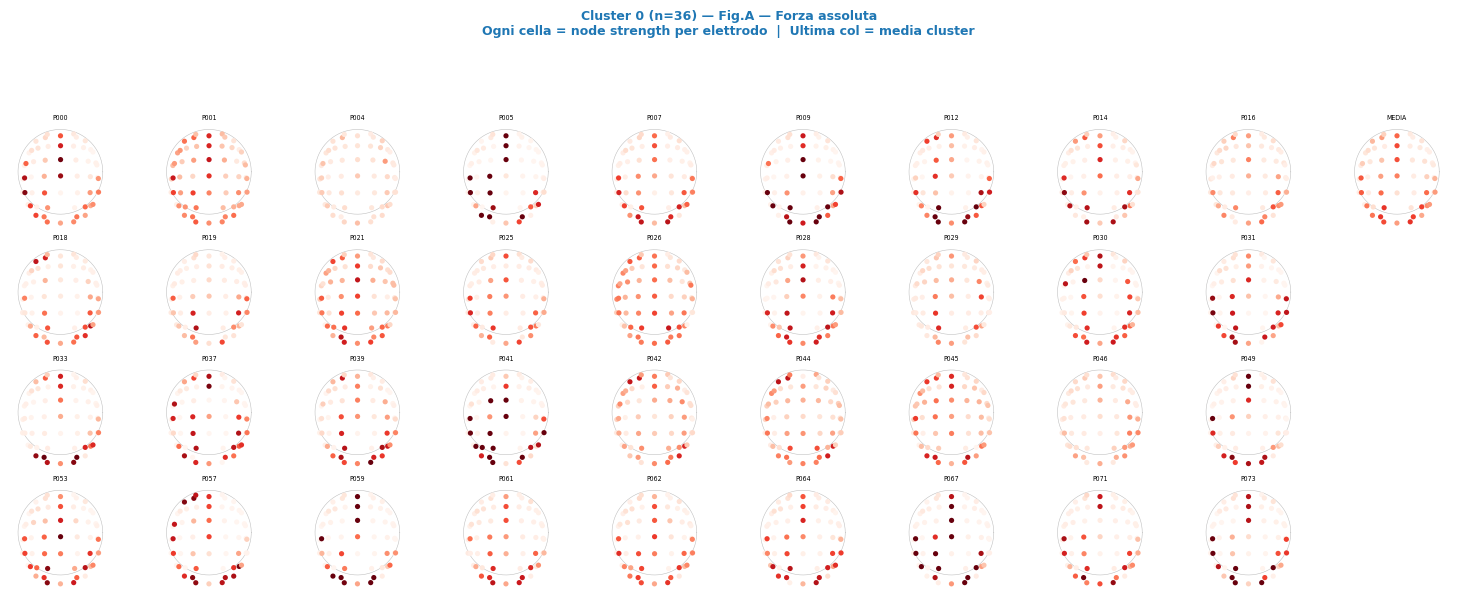

14:02:44 INFO     Salvato: eeg16b_persubj_c0_abs.png


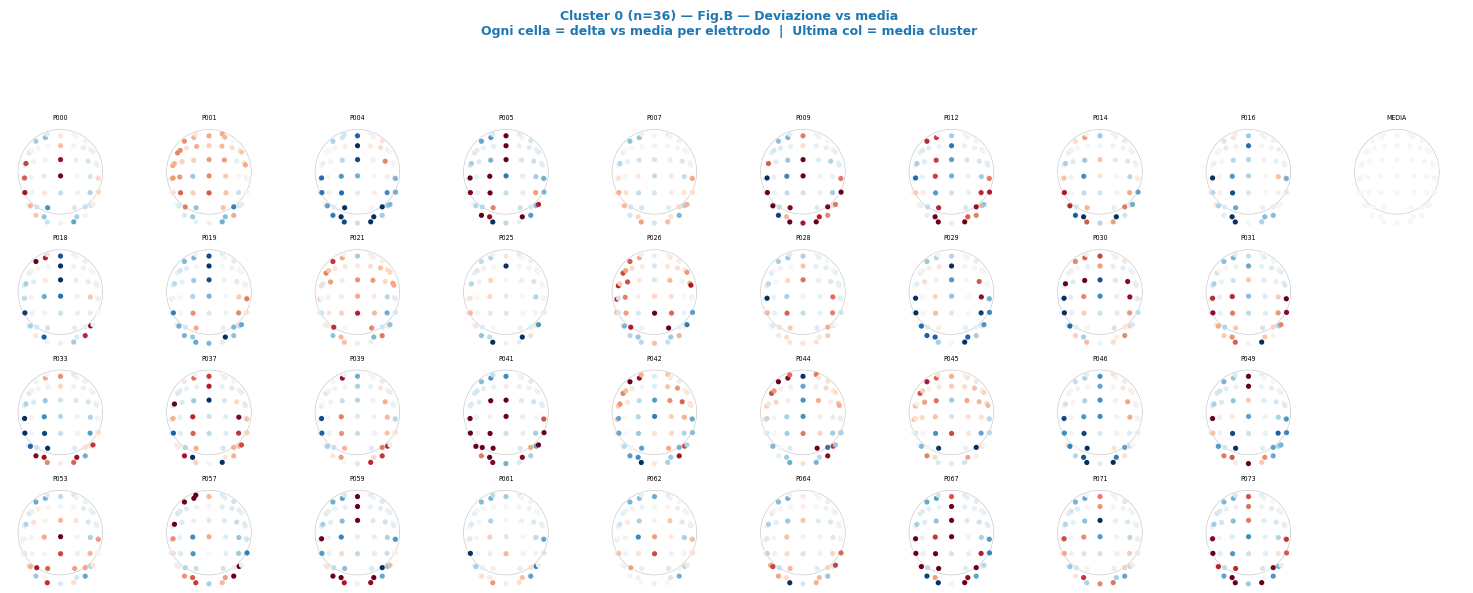

14:02:45 INFO     Salvato: eeg16b_persubj_c0_dev.png


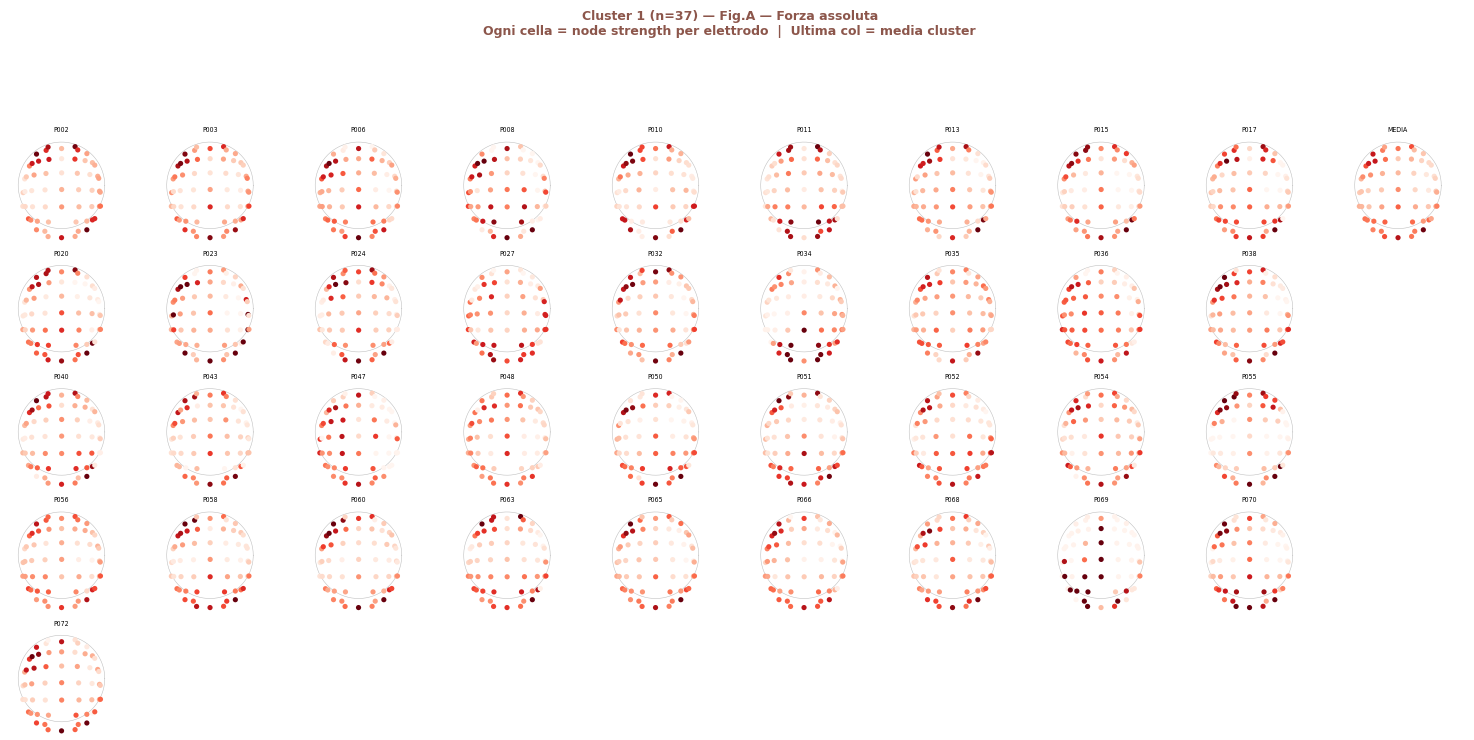

14:02:46 INFO     Salvato: eeg16b_persubj_c1_abs.png


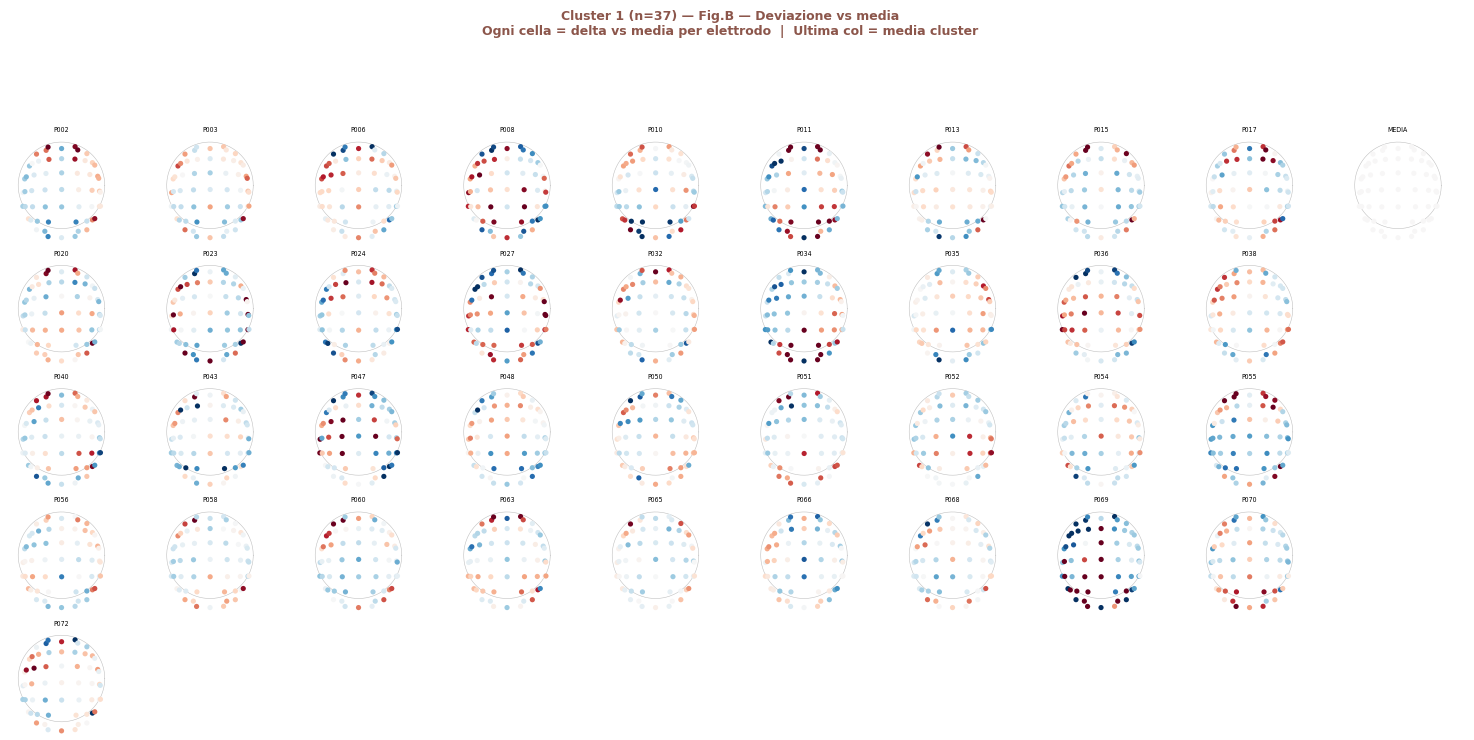

14:02:47 INFO     Salvato: eeg16b_persubj_c1_dev.png


In [ ]:
# \u00a7 16 -- Per-soggetto: node strength su cervello vs media cluster
NCOLS_S = 9

def mini_brain_scatter(ax, values_61, cmap, vmin, vmax, title='', border_color=None, r_head=0.095):
    ax.set_aspect('equal')
    pad = 0.018
    ax.set_xlim(-r_head - pad, r_head + pad)
    ax.set_ylim(-r_head - pad, r_head + pad)
    ax.axis('off')
    th = np.linspace(0, 2*np.pi, 150)
    ax.plot(r_head*np.cos(th), r_head*np.sin(th), 'k-', lw=0.4, alpha=0.25, zorder=0)
    sc = ax.scatter(
        topo_pos[:, 0], topo_pos[:, 1],
        c=values_61[topo_idx], cmap=cmap, vmin=vmin, vmax=vmax,
        s=14, zorder=2, linewidths=0, clip_on=False
    )
    ax.set_title(title, fontsize=4.5, pad=1)
    if border_color:
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_linewidth(2.2); sp.set_edgecolor(border_color)
    return sc

for c in range(k_top):
    subj_c     = [SUBJ_TOP[i] for i, l in enumerate(LABELS_TOP) if l == c]
    n_sub      = len(subj_c)
    color_c    = COLORS_TOP[c]
    adj_mean_c = cluster_adj[c]
    str_mean_c = adj_mean_c.mean(axis=1)

    strengths, deviations = [], []
    for sid in subj_c:
        if sid in SUBJ_G:
            adj_s = vec_to_sym(FEAT_G[SUBJ_G.index(sid)])
            s_vec = adj_s.mean(axis=1)
        else:
            s_vec = None
        strengths.append(s_vec)
        deviations.append(s_vec - str_mean_c if s_vec is not None else None)

    n_rows_g  = math.ceil(n_sub / NCOLS_S)
    ncols_tot = NCOLS_S + 1

    all_str = np.array([s for s in strengths if s is not None])
    vmax_a  = np.percentile(all_str, 97)
    vmin_a  = np.percentile(all_str, 3)
    all_dev = np.array([d for d in deviations if d is not None])
    vlim_d  = np.percentile(np.abs(all_dev), 95)

    for fig_type, data_list, cmap_t, vmin_t, vmax_t, figtag, sub in [
        ('A — Forza assoluta',      strengths,  'Reds',   vmin_a,   vmax_a,  'abs', 'node strength'),
        ('B — Deviazione vs media', deviations, 'RdBu_r', -vlim_d,  vlim_d,  'dev', 'delta vs media'),
    ]:
        fig, axes = plt.subplots(n_rows_g, ncols_tot,
                                 figsize=(ncols_tot * 1.5, n_rows_g * 1.5))
        fig.suptitle(
            f'Cluster {c} (n={n_sub}) — Fig.{fig_type}\n'
            f'Ogni cella = {sub} per elettrodo  |  Ultima col = media cluster',
            fontsize=9, fontweight='bold', color=color_c
        )
        if n_rows_g == 1:
            axes = axes[np.newaxis, :]

        for idx, (sid, data_s) in enumerate(zip(subj_c, data_list)):
            row, col = divmod(idx, NCOLS_S)
            ax = axes[row, col]
            if data_s is not None:
                mini_brain_scatter(ax, data_s, cmap_t, vmin_t, vmax_t, f'P{sid:03d}')
            else:
                ax.axis('off')

        for idx in range(n_sub, n_rows_g * NCOLS_S):
            row, col = divmod(idx, NCOLS_S)
            axes[row, col].axis('off')

        ref_vals = str_mean_c if figtag == 'abs' else np.zeros(N_CHAN)
        ref_cmap = 'Reds' if figtag == 'abs' else 'RdBu_r'
        mini_brain_scatter(axes[0, -1], ref_vals, ref_cmap, vmin_t, vmax_t,
                           'MEDIA', border_color='crimson')
        for row in range(1, n_rows_g):
            axes[row, -1].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.90])
        fname = f'eeg16b_persubj_c{c}_{figtag}.png'
        plt.savefig(FIG_DIR / fname, dpi=130, bbox_inches='tight')
        plt.show()
        log.info(f'Salvato: {fname}')


## §16b — Per-soggetto: node strength su scala logaritmica (senza colonna media)

Stessa logica di §16, ma:
- **Scala logaritmica** (`LogNorm` per forza assoluta, `SymLogNorm` per deviazione) — enfatizza differenze nei valori bassi che su scala lineare spariscono
- **Nessuna colonna MEDIA** — griglia più leggibile, più spazio ai soggetti
- Colormap identica (`Reds` per forza assoluta, `RdBu_r` per deviazione)

/tmp/ipykernel_772534/2495905715.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.97, 0.90])


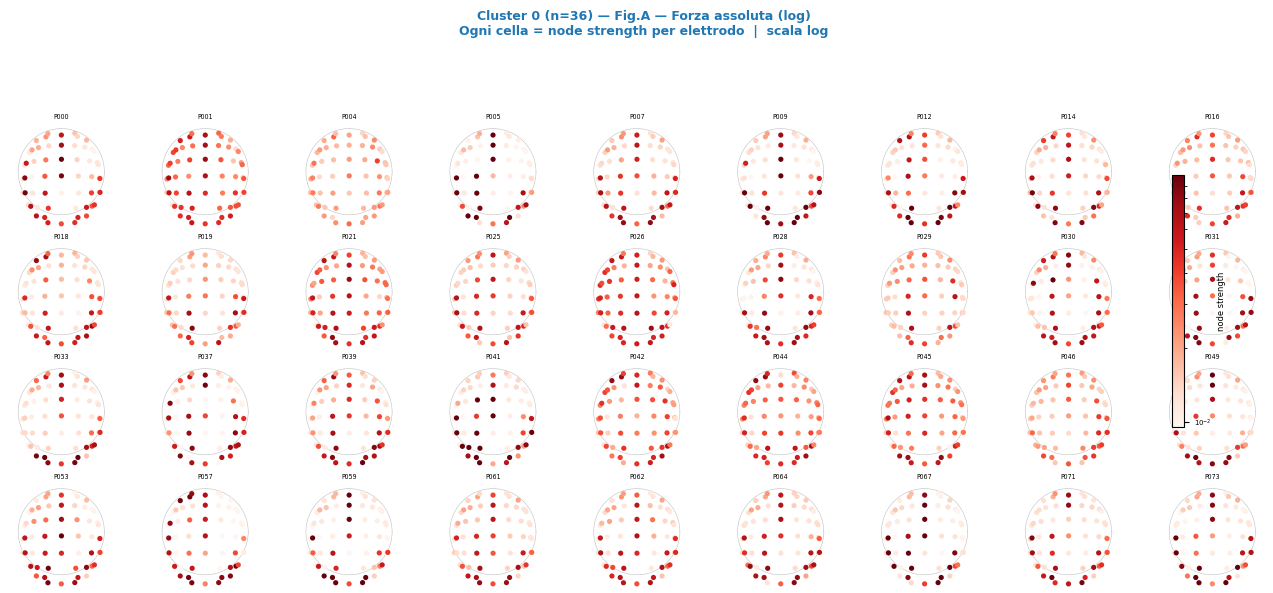

14:02:48 INFO     Salvato: eeg16b_persubj_c0_abslog.png


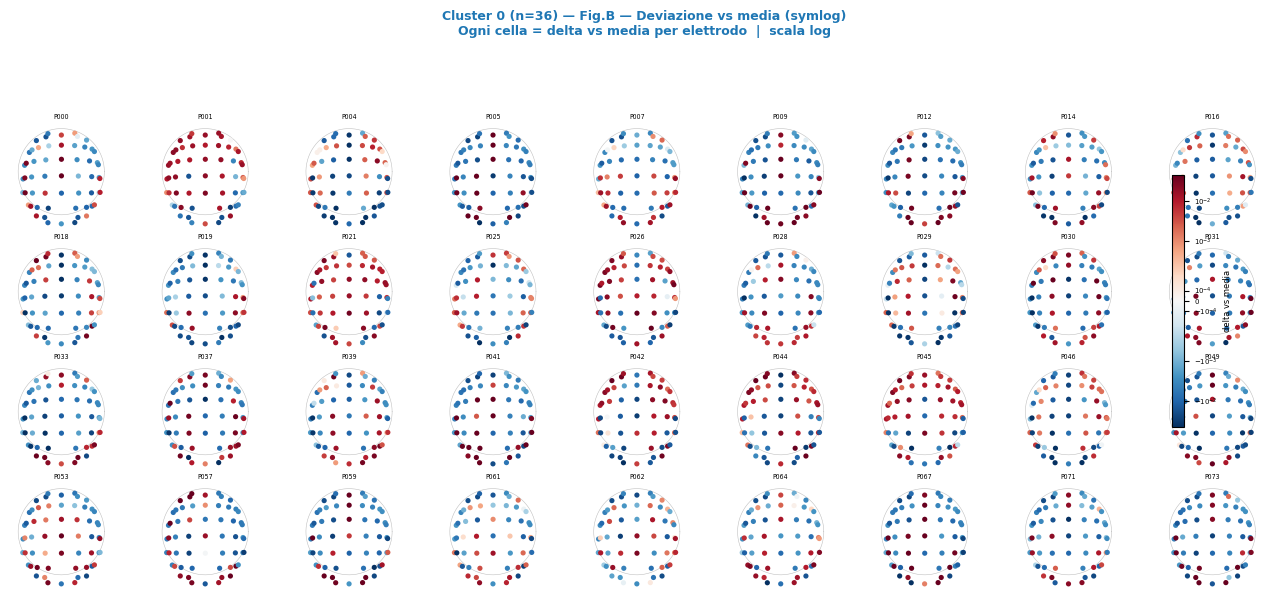

14:02:49 INFO     Salvato: eeg16b_persubj_c0_devlog.png


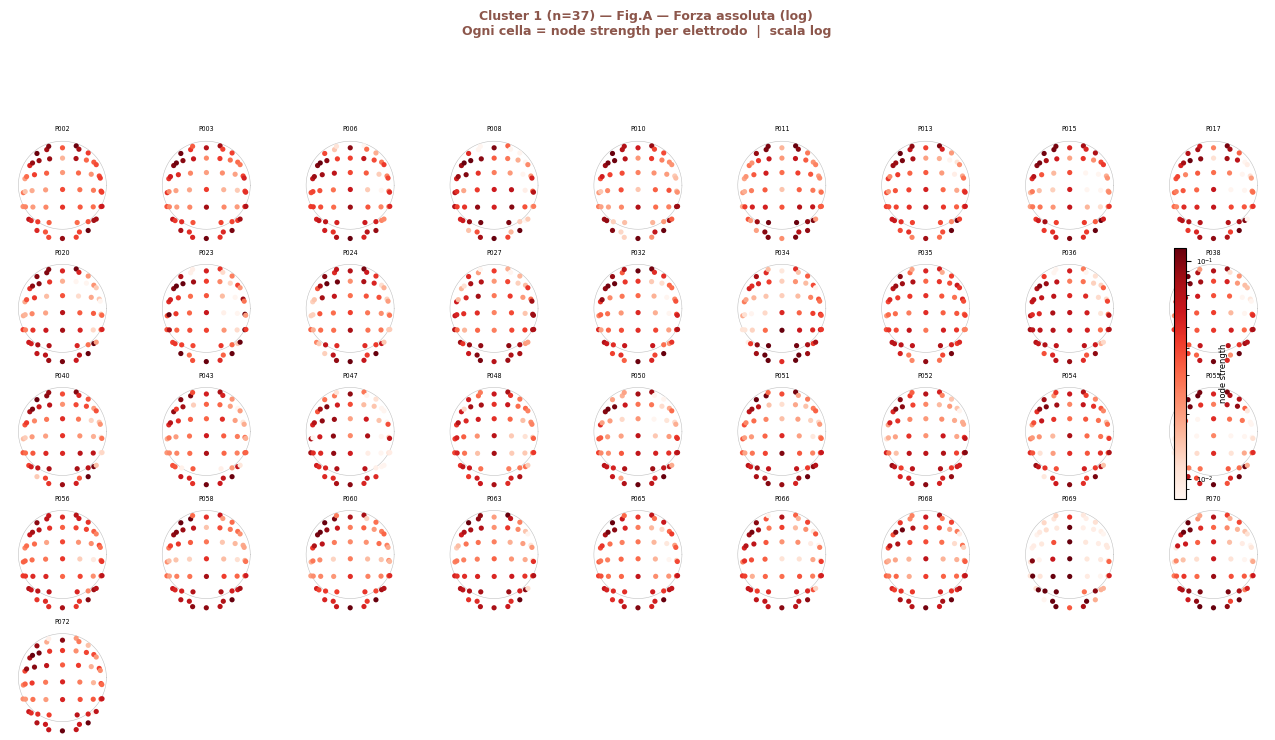

14:02:50 INFO     Salvato: eeg16b_persubj_c1_abslog.png


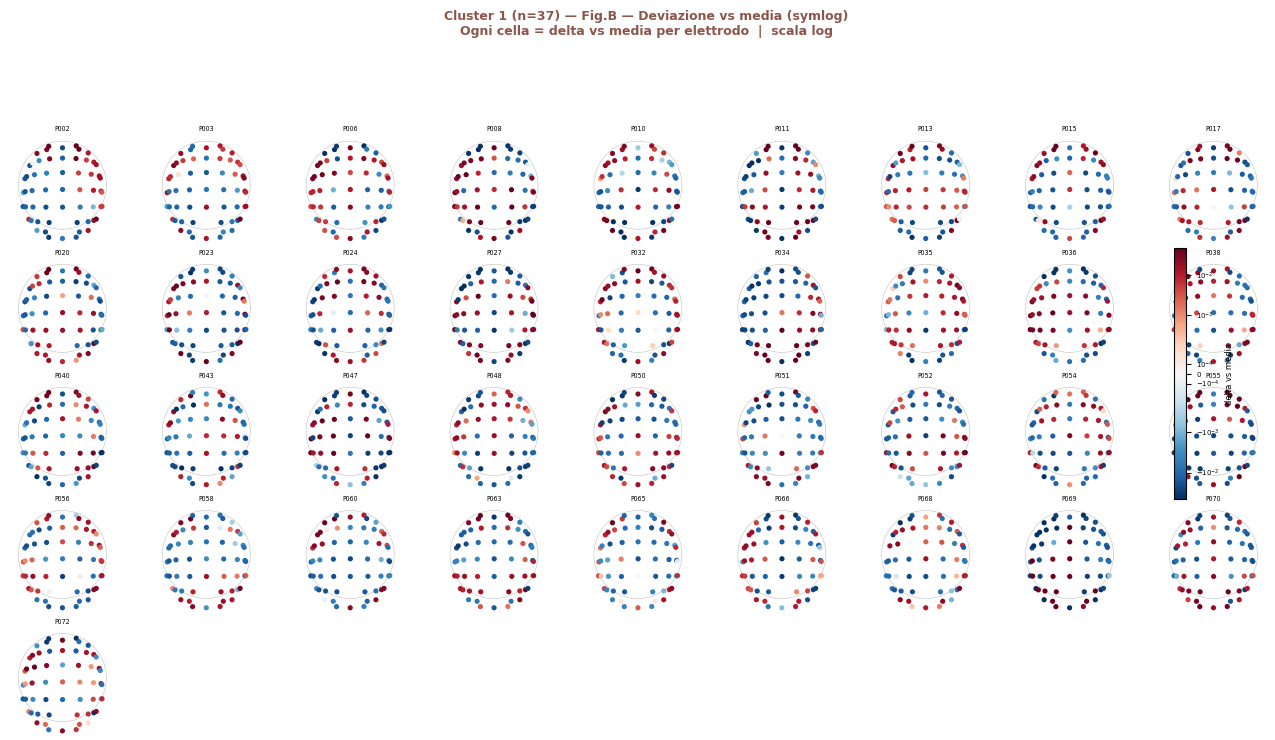

14:02:51 INFO     Salvato: eeg16b_persubj_c1_devlog.png


In [ ]:
# §16b — Per-soggetto: node strength scala logaritmica (senza media)
from matplotlib.colors import LogNorm, SymLogNorm

NCOLS_S_LOG = 9

def mini_brain_log(ax, values_61, norm, cmap, title='', r_head=0.095):
    """Come mini_brain_scatter ma accetta un oggetto norm invece di vmin/vmax."""
    ax.set_aspect('equal')
    pad = 0.018
    ax.set_xlim(-r_head - pad, r_head + pad)
    ax.set_ylim(-r_head - pad, r_head + pad)
    ax.axis('off')
    th = np.linspace(0, 2*np.pi, 150)
    ax.plot(r_head*np.cos(th), r_head*np.sin(th), 'k-', lw=0.4, alpha=0.25, zorder=0)
    sc = ax.scatter(
        topo_pos[:, 0], topo_pos[:, 1],
        c=values_61[topo_idx], cmap=cmap, norm=norm,
        s=14, zorder=2, linewidths=0, clip_on=False
    )
    ax.set_title(title, fontsize=4.5, pad=1)
    return sc

for c in range(k_top):
    subj_c     = [SUBJ_TOP[i] for i, l in enumerate(LABELS_TOP) if l == c]
    n_sub      = len(subj_c)
    color_c    = COLORS_TOP[c]
    adj_mean_c = cluster_adj[c]
    str_mean_c = adj_mean_c.mean(axis=1)

    strengths, deviations = [], []
    for sid in subj_c:
        if sid in SUBJ_G:
            adj_s = vec_to_sym(FEAT_G[SUBJ_G.index(sid)])
            s_vec = adj_s.mean(axis=1)
        else:
            s_vec = None
        strengths.append(s_vec)
        deviations.append(s_vec - str_mean_c if s_vec is not None else None)

    # ── Norme logaritmiche ──────────────────────────────────────────────────
    all_str = np.array([s for s in strengths if s is not None])
    vmax_a  = np.percentile(all_str, 97)
    vmin_a  = max(np.percentile(all_str, 3), 1e-6)   # LogNorm richiede >0
    norm_abs = LogNorm(vmin=vmin_a, vmax=vmax_a)

    all_dev  = np.array([d for d in deviations if d is not None])
    vlim_d   = np.percentile(np.abs(all_dev), 95)
    # linthresh = 1% di vlim_d: zona lineare intorno allo zero
    linthresh = max(vlim_d * 0.01, 1e-6)
    norm_dev  = SymLogNorm(linthresh=linthresh, vmin=-vlim_d, vmax=vlim_d, base=10)

    n_rows_g  = math.ceil(n_sub / NCOLS_S_LOG)

    for fig_type, data_list, norm_t, cmap_t, figtag, sub in [
        ('A — Forza assoluta (log)',      strengths,  norm_abs, 'Reds',   'abslog', 'node strength'),
        ('B — Deviazione vs media (symlog)', deviations, norm_dev, 'RdBu_r', 'devlog', 'delta vs media'),
    ]:
        fig, axes = plt.subplots(n_rows_g, NCOLS_S_LOG,
                                 figsize=(NCOLS_S_LOG * 1.5, n_rows_g * 1.5))
        fig.suptitle(
            f'Cluster {c} (n={n_sub}) — Fig.{fig_type}\n'
            f'Ogni cella = {sub} per elettrodo  |  scala log',
            fontsize=9, fontweight='bold', color=color_c
        )
        if n_rows_g == 1:
            axes = axes[np.newaxis, :]

        sc_last = None
        for idx, (sid, data_s) in enumerate(zip(subj_c, data_list)):
            row, col = divmod(idx, NCOLS_S_LOG)
            ax = axes[row, col]
            if data_s is not None:
                sc_last = mini_brain_log(ax, data_s, norm_t, cmap_t, f'P{sid:03d}')
            else:
                ax.axis('off')

        # Spegni celle vuote
        for idx in range(n_sub, n_rows_g * NCOLS_S_LOG):
            row, col = divmod(idx, NCOLS_S_LOG)
            axes[row, col].axis('off')

        # Colorbar compatta a destra
        if sc_last is not None:
            cbar = fig.colorbar(sc_last, ax=axes, orientation='vertical',
                                fraction=0.012, pad=0.01, shrink=0.6)
            cbar.ax.tick_params(labelsize=5)
            cbar.set_label(sub, fontsize=6)

        plt.tight_layout(rect=[0, 0, 0.97, 0.90])
        fname = f'eeg16b_persubj_c{c}_{figtag}.png'
        plt.savefig(FIG_DIR / fname, dpi=130, bbox_inches='tight')
        plt.show()
        log.info(f'Salvato: {fname}')

## §16c — Stabilità della media: variabilità intra-soggetto trial-by-trial

**Domanda**: la media adj per soggetto è una rappresentazione stabile, o i singoli trial variano troppo?

**Metrica**: Coefficient of Variation (CV) = std / mean per ogni coppia di elettrodi, per ogni soggetto.
- CV < 0.5 → media stabile e rappresentativa
- CV ≈ 1.0 → deviazione standard pari alla media (alta variabilità relativa)
- CV > 1.0 → media non rappresentativa

Plot prodotti:
- **A**: distribuzione CV aggregata su tutti i soggetti e coppie
- **B**: CV medio per soggetto, ordinato per cluster — C0 vs C1 differiscono in stabilità?
- **C**: heatmap CV medio per coppia di elettrodi (61×61) — quali connessioni sono più stabili?

14:02:51 INFO     Cache CV trovata — caricamento veloce
14:02:51 INFO     CV medio globale: 6.149 ± 0.796
14:02:51 INFO     CV mediana globale: 5.971
14:02:51 INFO     Range CV: [4.557, 8.302]
14:02:51 INFO     CV C0 vs C1: C0=5.891 C1=6.069 p=0.679


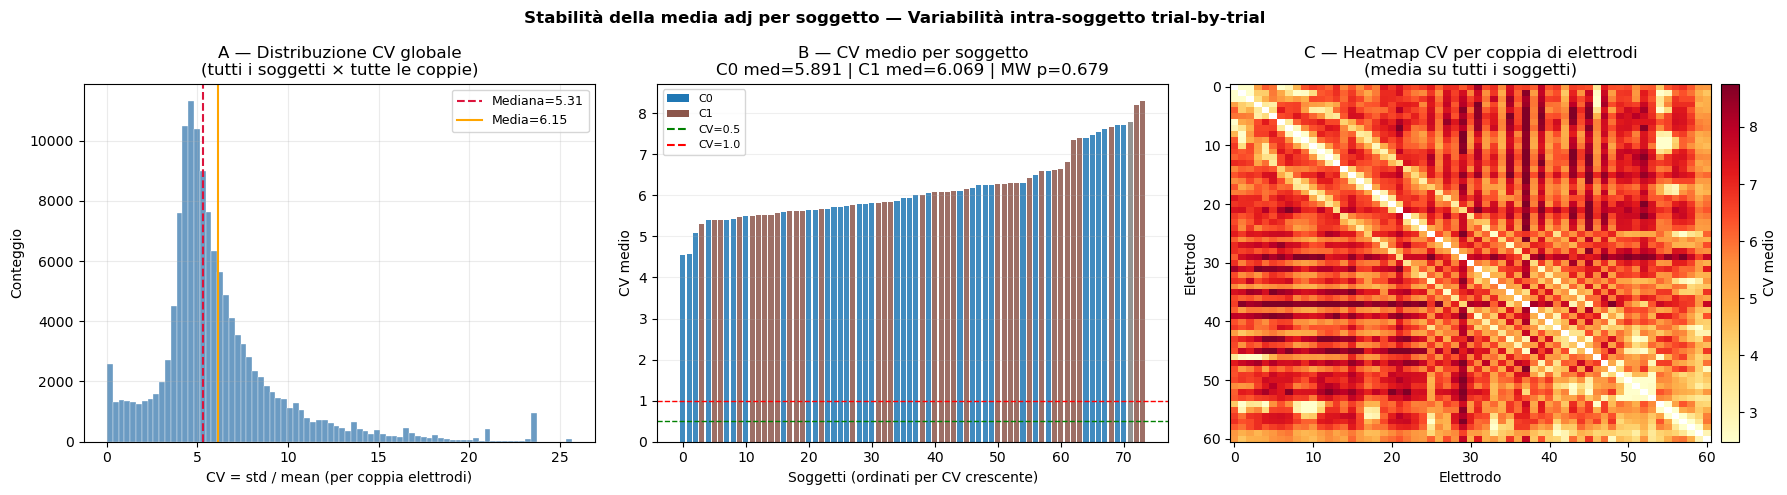

14:02:52 INFO     Salvato: eeg16b_cv_intra_subj.png



── Sommario variabilità intra-soggetto ──
  CV globale (media):   6.149
  CV globale (mediana): 5.310
  Sogg. con CV < 0.5:   0/74 (0%)
  Sogg. con CV > 1.0:   74/74 (100%)

  Le 5 coppie più stabili (CV minore):
    E09-E55  CV=0.772
    E10-E55  CV=0.848
    E54-E55  CV=1.006
    E50-E53  CV=1.280
    E49-E53  CV=1.328

  Le 5 coppie più instabili (CV maggiore):
    E04-E37  CV=9.803
    E12-E37  CV=9.653
    E29-E47  CV=9.632
    E05-E45  CV=9.575
    E29-E57  CV=9.500


In [ ]:
# §16c — Stabilità media: CV intra-soggetto (std/mean su trial)
# Carica i trial_*.pt grezzi per calcolare variabilità trial-by-trial

CV_CACHE = CKPT_DIR / 'cv_intra_subj_abs_pcc.npz'

if CV_CACHE.exists():
    log.info('Cache CV trovata — caricamento veloce')
    _cv = np.load(CV_CACHE)
    CV_MEAN  = _cv['cv_mean']   # (n_subj,) — CV medio per soggetto
    CV_MAT   = _cv['cv_mat']    # (n_subj, 1830) — CV per coppia
    CV_SUBJ  = _cv['subj_ids'].tolist()
    STD_MAT  = _cv['std_mat']   # (n_subj, 1830)
    MEAN_MAT = _cv['mean_mat']  # (n_subj, 1830)
else:
    cv_list, std_list, mean_list, cv_subj = [], [], [], []
    for sid in tqdm(ALL_SUBJ, desc='CV intra-soggetto'):
        paths = IDX[sid]
        adjs = []
        for p in paths:
            try:
                d = torch.load(p, weights_only=False)
                adj = d['adj'].float().numpy()
                if adj.shape == (N_CHAN, N_CHAN):
                    adjs.append(adj[triu_idx])
            except Exception:
                continue
        if len(adjs) < 10:
            continue
        A      = np.stack(adjs)                    # (n_trial, 1830)
        mean_s = A.mean(axis=0)                    # (1830,)
        std_s  = A.std(axis=0)                     # (1830,)
        cv_s   = std_s / (np.abs(mean_s) + 1e-9)  # (1830,)
        cv_list.append(cv_s)
        std_list.append(std_s)
        mean_list.append(mean_s)
        cv_subj.append(sid)

    CV_MAT   = np.stack(cv_list)
    STD_MAT  = np.stack(std_list)
    MEAN_MAT = np.stack(mean_list)
    CV_MEAN  = CV_MAT.mean(axis=1)
    CV_SUBJ  = cv_subj
    np.savez(CV_CACHE, cv_mean=CV_MEAN, cv_mat=CV_MAT,
             std_mat=STD_MAT, mean_mat=MEAN_MAT, subj_ids=np.array(CV_SUBJ))
    log.info(f'CV calcolato per {len(CV_SUBJ)} soggetti, salvato in {CV_CACHE}')

log.info(f'CV medio globale: {CV_MEAN.mean():.3f} ± {CV_MEAN.std():.3f}')
log.info(f'CV mediana globale: {np.median(CV_MEAN):.3f}')
log.info(f'Range CV: [{CV_MEAN.min():.3f}, {CV_MEAN.max():.3f}]')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stabilità della media adj per soggetto — Variabilità intra-soggetto trial-by-trial',
             fontsize=12, fontweight='bold')

# A — Distribuzione CV globale
ax = axes[0]
all_cv_flat = CV_MAT.flatten()
ax.hist(all_cv_flat, bins=80, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.axvline(np.median(all_cv_flat), color='crimson', lw=1.5, linestyle='--',
           label=f'Mediana={np.median(all_cv_flat):.2f}')
ax.axvline(all_cv_flat.mean(), color='orange', lw=1.5, linestyle='-',
           label=f'Media={all_cv_flat.mean():.2f}')
ax.set_xlabel('CV = std / mean (per coppia elettrodi)')
ax.set_ylabel('Conteggio')
ax.set_title('A — Distribuzione CV globale\n(tutti i soggetti × tutte le coppie)')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)

# B — CV medio per soggetto, colorato per cluster
ax = axes[1]
cluster_color = []
cv_sorted_vals, cv_sorted_labels, cv_sorted_subj = [], [], []
for sid, cv_s in sorted(zip(CV_SUBJ, CV_MEAN), key=lambda x: x[1]):
    cv_sorted_vals.append(cv_s)
    cv_sorted_subj.append(sid)
    if sid in SUBJ_TOP:
        lbl = LABELS_TOP[SUBJ_TOP.index(sid)]
        cv_sorted_labels.append(lbl)
        cluster_color.append(COLORS_TOP[lbl])
    else:
        cv_sorted_labels.append(-1)
        cluster_color.append('gray')

bars = ax.bar(range(len(cv_sorted_vals)), cv_sorted_vals, color=cluster_color, alpha=0.85, width=0.8)
ax.axhline(0.5, color='green', lw=1, linestyle='--', label='CV=0.5 (soglia stabilità)')
ax.axhline(1.0, color='red',   lw=1, linestyle='--', label='CV=1.0')
ax.set_xlabel('Soggetti (ordinati per CV crescente)')
ax.set_ylabel('CV medio')
ax.set_title('B — CV medio per soggetto\n(blu=C0, arancio=C1)')
ax.legend(fontsize=8)
ax.grid(alpha=0.2, axis='y')

# Legenda cluster manuale
from matplotlib.patches import Patch
legend_el = [Patch(facecolor=COLORS_TOP[c], label=f'C{c}') for c in range(k_top)]
ax.legend(handles=legend_el + [
    plt.Line2D([0],[0], color='green', linestyle='--', label='CV=0.5'),
    plt.Line2D([0],[0], color='red',   linestyle='--', label='CV=1.0'),
], fontsize=8)

# Mann-Whitney CV C0 vs C1
cv_c0 = [CV_MEAN[CV_SUBJ.index(s)] for s in CV_SUBJ
         if s in SUBJ_TOP and LABELS_TOP[SUBJ_TOP.index(s)] == 0]
cv_c1 = [CV_MEAN[CV_SUBJ.index(s)] for s in CV_SUBJ
         if s in SUBJ_TOP and LABELS_TOP[SUBJ_TOP.index(s)] == 1]
if cv_c0 and cv_c1:
    from scipy.stats import mannwhitneyu
    stat_cv, p_cv = mannwhitneyu(cv_c0, cv_c1, alternative='two-sided')
    ax.set_title(f'B — CV medio per soggetto\n'
                 f'C0 med={np.median(cv_c0):.3f} | C1 med={np.median(cv_c1):.3f} | MW p={p_cv:.3f}')
    log.info(f'CV C0 vs C1: C0={np.median(cv_c0):.3f} C1={np.median(cv_c1):.3f} p={p_cv:.3f}')

# C — Heatmap CV medio per coppia di elettrodi (61×61)
ax = axes[2]
cv_mean_pair = CV_MAT.mean(axis=0)   # (1830,)
cv_mat_2d    = np.zeros((N_CHAN, N_CHAN))
cv_mat_2d[triu_idx] = cv_mean_pair
cv_mat_2d += cv_mat_2d.T
np.fill_diagonal(cv_mat_2d, np.nan)
im = ax.imshow(cv_mat_2d, cmap='YlOrRd', aspect='auto',
               vmin=np.nanpercentile(cv_mat_2d, 2),
               vmax=np.nanpercentile(cv_mat_2d, 98))
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='CV medio')
ax.set_title('C — Heatmap CV per coppia di elettrodi\n(media su tutti i soggetti)')
ax.set_xlabel('Elettrodo'); ax.set_ylabel('Elettrodo')

plt.tight_layout()
fname = 'eeg16b_cv_intra_subj.png'
plt.savefig(FIG_DIR / fname, dpi=130, bbox_inches='tight')
plt.show()
log.info(f'Salvato: {fname}')

# ── Stampa sommario testuale ──────────────────────────────────────────────────
print(f"\n── Sommario variabilità intra-soggetto ──")
print(f"  CV globale (media):   {CV_MAT.mean():.3f}")
print(f"  CV globale (mediana): {np.median(CV_MAT):.3f}")
print(f"  Sogg. con CV < 0.5:   {(CV_MEAN < 0.5).sum()}/{len(CV_MEAN)} ({100*(CV_MEAN<0.5).mean():.0f}%)")
print(f"  Sogg. con CV > 1.0:   {(CV_MEAN > 1.0).sum()}/{len(CV_MEAN)} ({100*(CV_MEAN>1.0).mean():.0f}%)")
print(f"\n  Le 5 coppie più stabili (CV minore):")
top_stable = np.argsort(cv_mean_pair)[:5]
for idx_p in top_stable:
    r, c = triu_idx[0][idx_p], triu_idx[1][idx_p]
    print(f"    E{r:02d}-E{c:02d}  CV={cv_mean_pair[idx_p]:.3f}")
print(f"\n  Le 5 coppie più instabili (CV maggiore):")
top_unstable = np.argsort(cv_mean_pair)[-5:][::-1]
for idx_p in top_unstable:
    r, c = triu_idx[0][idx_p], triu_idx[1][idx_p]
    print(f"    E{r:02d}-E{c:02d}  CV={cv_mean_pair[idx_p]:.3f}")

## §16d — Validità della media inter-soggetto: variabilità di FEAT_G

**Domanda**: i valori medi adj per soggetto (FEAT_G) catturano differenze reali tra individui,
o sono tutti simili (= la media è solo rumore mediato)?

**Metrica**: per ogni coppia di elettrodi, std delle 73 medie soggetto → misura quanto
i soggetti si differenziano realmente per quella connessione.

- **std alta** per coppia → i soggetti hanno connettività davvero diversa → quella coppia è informativa
- **std bassa** per tutta la matrice → tutti i soggetti hanno la stessa connettività → la media non distingue nessuno

Calcolabile direttamente da `FEAT_G` già in memoria — nessun accesso ai trial raw necessario.

── Statistiche FEAT_G (media adj per soggetto) ──
  Shape: (73, 1830)  (73 soggetti × 1830 coppie)
  Valori: [0.0000, 0.9976]
  Media  pop: 0.0402 ± 0.0775
  Std    pop: 0.0471 ± 0.0738
  CV inter-soggetto (med): 0.935
  CV inter-soggetto (p5-p95): [0.504, 2.279]

  Coppie con CV > 0.1:  100.0%  (variabilità non trascurabile)
  Coppie con CV > 0.3:  100.0%  (variabilità rilevante)


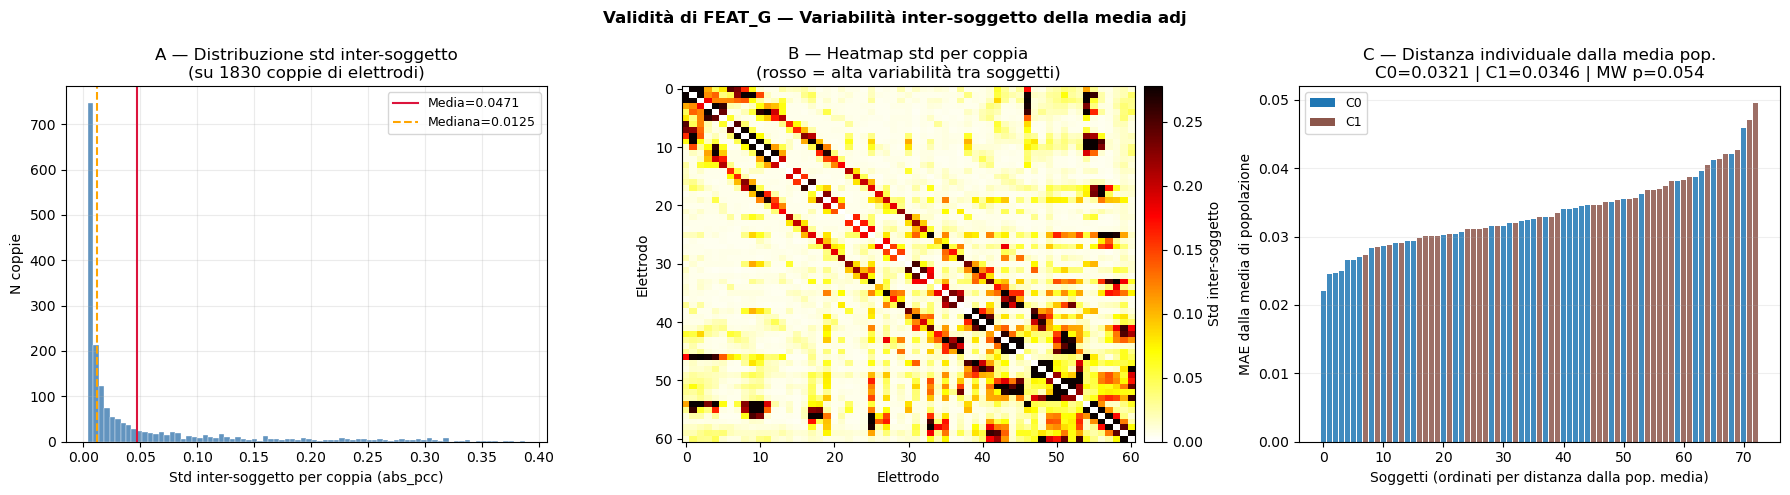

14:02:52 INFO     Salvato: eeg16b_feat_variability.png



── Top 10 coppie con maggiore variabilità inter-soggetto ──
  # 1  E43-E44  std=0.3876  mean=0.3921  CV=0.989
  # 2  E10-E54  std=0.3769  mean=0.4058  CV=0.929
  # 3  E39-E40  std=0.3733  mean=0.3119  CV=1.197
  # 4  E08-E09  std=0.3711  mean=0.3739  CV=0.992
  # 5  E01-E08  std=0.3693  mean=0.3952  CV=0.934
  # 6  E01-E02  std=0.3603  mean=0.4646  CV=0.775
  # 7  E09-E54  std=0.3584  mean=0.3917  CV=0.915
  # 8  E01-E54  std=0.3548  mean=0.5031  CV=0.705
  # 9  E48-E49  std=0.3501  mean=0.3115  CV=1.124
  #10  E10-E11  std=0.3463  mean=0.3275  CV=1.057


In [ ]:
# §16d — Variabilità inter-soggetto di FEAT_G (già in memoria)
# std delle medie soggetto: quanto si differenziano davvero i 73 soggetti?

# ── Statistiche base su FEAT_G ────────────────────────────────────────────────
pop_mean = FEAT_G.mean(axis=0)      # (1830,) — media di popolazione
pop_std  = FEAT_G.std(axis=0)       # (1830,) — std inter-soggetto
pop_cv   = pop_std / (np.abs(pop_mean) + 1e-9)  # CV inter-soggetto

print("── Statistiche FEAT_G (media adj per soggetto) ──")
print(f"  Shape: {FEAT_G.shape}  ({FEAT_G.shape[0]} soggetti × {FEAT_G.shape[1]} coppie)")
print(f"  Valori: [{FEAT_G.min():.4f}, {FEAT_G.max():.4f}]")
print(f"  Media  pop: {pop_mean.mean():.4f} ± {pop_mean.std():.4f}")
print(f"  Std    pop: {pop_std.mean():.4f} ± {pop_std.std():.4f}")
print(f"  CV inter-soggetto (med): {np.median(pop_cv):.3f}")
print(f"  CV inter-soggetto (p5-p95): [{np.percentile(pop_cv,5):.3f}, {np.percentile(pop_cv,95):.3f}]")
print()

# Frazione di coppie con CV > 0.1 (variabilità non trascurabile)
frac_variable = (pop_cv > 0.1).mean()
print(f"  Coppie con CV > 0.1:  {frac_variable*100:.1f}%  (variabilità non trascurabile)")
print(f"  Coppie con CV > 0.3:  {(pop_cv > 0.3).mean()*100:.1f}%  (variabilità rilevante)")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Validità di FEAT_G — Variabilità inter-soggetto della media adj',
             fontsize=12, fontweight='bold')

# A — Distribuzione std inter-soggetto per coppia
ax = axes[0]
ax.hist(pop_std, bins=80, color='steelblue', alpha=0.85, edgecolor='white', lw=0.3)
ax.axvline(pop_std.mean(),    color='crimson', lw=1.5, ls='-',  label=f'Media={pop_std.mean():.4f}')
ax.axvline(np.median(pop_std),color='orange',  lw=1.5, ls='--', label=f'Mediana={np.median(pop_std):.4f}')
ax.set_xlabel('Std inter-soggetto per coppia (abs_pcc)')
ax.set_ylabel('N coppie')
ax.set_title('A — Distribuzione std inter-soggetto\n(su 1830 coppie di elettrodi)')
ax.legend(fontsize=9); ax.grid(alpha=0.25)

# B — Heatmap std inter-soggetto (61×61)
ax = axes[1]
std_mat = np.zeros((N_CHAN, N_CHAN))
std_mat[triu_idx] = pop_std
std_mat += std_mat.T
np.fill_diagonal(std_mat, np.nan)
im = ax.imshow(std_mat, cmap='hot_r', aspect='auto',
               vmin=0, vmax=np.percentile(pop_std, 97))
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label='Std inter-soggetto')
ax.set_title('B — Heatmap std per coppia\n(rosso = alta variabilità tra soggetti)')
ax.set_xlabel('Elettrodo'); ax.set_ylabel('Elettrodo')

# C — Soggetti: distribuzione mean adj soggetto (boxplot o violinplot)
# mostra che ogni soggetto ha un "profilo" diverso dalla media di popolazione
ax = axes[2]
# Calcola distanza di ogni soggetto dalla media di popolazione
dist_from_pop = np.abs(FEAT_G - pop_mean).mean(axis=1)  # (n_subj,) — MAE dal centro
# Colora per cluster
colors_s = [COLORS_TOP[LABELS_TOP[SUBJ_TOP.index(s)]] if s in SUBJ_TOP else 'gray'
            for s in SUBJ_G]
order = np.argsort(dist_from_pop)
ax.bar(range(len(dist_from_pop)),
       dist_from_pop[order],
       color=[colors_s[i] for i in order], alpha=0.85, width=0.8)
ax.set_xlabel('Soggetti (ordinati per distanza dalla pop. media)')
ax.set_ylabel('MAE dalla media di popolazione')
ax.set_title('C — Distanza individuale dalla media\n(blu=C0, arancio=C1)')
ax.grid(alpha=0.2, axis='y')

# Legenda cluster
from matplotlib.patches import Patch
legend_el = [Patch(facecolor=COLORS_TOP[c], label=f'C{c}') for c in range(k_top)]
ax.legend(handles=legend_el, fontsize=9)

# Mann-Whitney distanza C0 vs C1
dist_c0 = [dist_from_pop[SUBJ_G.index(s)] for s in SUBJ_G
           if s in SUBJ_TOP and LABELS_TOP[SUBJ_TOP.index(s)] == 0]
dist_c1 = [dist_from_pop[SUBJ_G.index(s)] for s in SUBJ_G
           if s in SUBJ_TOP and LABELS_TOP[SUBJ_TOP.index(s)] == 1]
from scipy.stats import mannwhitneyu
if dist_c0 and dist_c1:
    _, p_dist = mannwhitneyu(dist_c0, dist_c1, alternative='two-sided')
    ax.set_title(f'C — Distanza individuale dalla media pop.\n'
                 f'C0={np.median(dist_c0):.4f} | C1={np.median(dist_c1):.4f} | MW p={p_dist:.3f}')

plt.tight_layout()
fname = 'eeg16b_feat_variability.png'
plt.savefig(FIG_DIR / fname, dpi=130, bbox_inches='tight')
plt.show()
log.info(f'Salvato: {fname}')

# ── Top 10 coppie più variabili tra soggetti ──────────────────────────────────
print("\n── Top 10 coppie con maggiore variabilità inter-soggetto ──")
top10 = np.argsort(pop_std)[-10:][::-1]
for rank, idx_p in enumerate(top10, 1):
    r, c = triu_idx[0][idx_p], triu_idx[1][idx_p]
    print(f"  #{rank:2d}  E{r:02d}-E{c:02d}  std={pop_std[idx_p]:.4f}  mean={pop_mean[idx_p]:.4f}  CV={pop_cv[idx_p]:.3f}")

## §16e — Stabilità intra-soggetto dell'ipergrafo: distanza trial → media

Per ogni soggetto: quanto dista ogni singolo trial dalla media H·Hᵀ del soggetto stesso?

**Pipeline**:
- Per ogni trial: carica `H` dal `.pt` → calcola `H·Hᵀ` → upper triangle (1830-dim)
- Media del soggetto: `mean_hht` = media su tutti i trial (= quello in `FEAT_H`)
- Distanza per trial: `dist_t = ||hht_t - mean_hht||₂` (norma L2) e MAE
- Output per soggetto: `mean_dist ± std_dist` → stabile se std_dist << mean_dist

**Interpretazione**:
- `mean_dist` piccola → tutti i trial del soggetto hanno ipergrafi simili → media rappresentativa
- `std_dist` alta → l'ipergrafo del soggetto oscilla molto trial-by-trial → media meno affidabile
- Confronto C0 vs C1: i due cluster differiscono in stabilità intra-trial?

14:02:52 INFO     Cache distanza HHT trovata — caricamento veloce
14:02:52 INFO     Soggetti con distanza HHT calcolata: 74
14:02:52 INFO     rel_std MW: C0=0.0771 C1=0.0946 p=0.0002


── Distanza intra-soggetto H·Hᵀ: trial vs media ──
  L2 media (pop):     33.3655 ± 2.4980
  Std L2 (pop):       2.9603 ± 0.5920
  MAE medio (pop):    0.4244 ± 0.0471
  Rel.std (std/mean): 0.089 ± 0.020
  N trial medio: 525 ± 68

  L2 assoluta  — C0=35.385  C1=31.198  p=0.0000  ← confuso da scala
  Rel.std      — C0=0.0771  C1=0.0946  p=0.0002  ← metrica corretta


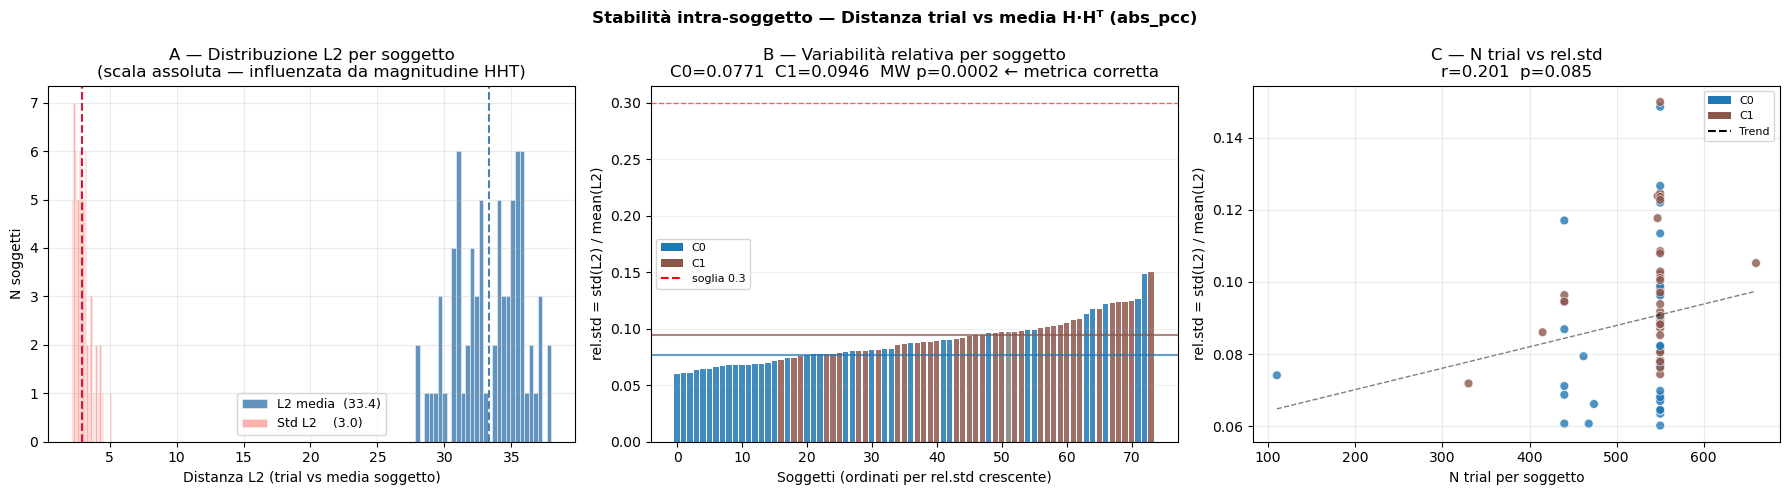

14:02:53 INFO     Salvato: eeg16b_hht_intra_dist.png


In [ ]:
# §16e — Distanza intra-soggetto: ogni trial H·Hᵀ vs media soggetto
# Richiede i file trial_*.pt (gira sul server)

HHT_DIST_CACHE = CKPT_DIR / 'hht_intra_dist_abs_pcc.npz'

if HHT_DIST_CACHE.exists():
    log.info('Cache distanza HHT trovata — caricamento veloce')
    _d = np.load(HHT_DIST_CACHE)
    DIST_MEAN  = _d['dist_mean']
    DIST_STD   = _d['dist_std']
    DIST_MAE   = _d['dist_mae']
    DIST_SUBJ  = _d['subj_ids'].tolist()
    N_TRIALS   = _d['n_trials']
else:
    dist_mean_list, dist_std_list, dist_mae_list = [], [], []
    dist_subj_list, n_trials_list = [], []

    for sid in tqdm(ALL_SUBJ, desc='Distanza HHT intra-soggetto'):
        paths = IDX[sid]
        hhts = []
        for p in paths:
            try:
                d = torch.load(p, weights_only=False)
                if 'H' not in d:
                    continue
                H = d['H'].float().numpy()
                hht = (H @ H.T)[triu_idx]
                hhts.append(hht)
            except Exception:
                continue
        if len(hhts) < 10:
            continue

        A        = np.stack(hhts)
        mean_hht = A.mean(axis=0)
        diff     = A - mean_hht

        l2_per_trial  = np.linalg.norm(diff, axis=1)
        mae_per_trial = np.abs(diff).mean(axis=1)

        dist_mean_list.append(l2_per_trial.mean())
        dist_std_list.append(l2_per_trial.std())
        dist_mae_list.append(mae_per_trial.mean())
        dist_subj_list.append(sid)
        n_trials_list.append(len(hhts))

    DIST_MEAN = np.array(dist_mean_list)
    DIST_STD  = np.array(dist_std_list)
    DIST_MAE  = np.array(dist_mae_list)
    DIST_SUBJ = dist_subj_list
    N_TRIALS  = np.array(n_trials_list)

    np.savez(HHT_DIST_CACHE,
             dist_mean=DIST_MEAN, dist_std=DIST_STD,
             dist_mae=DIST_MAE,   subj_ids=np.array(DIST_SUBJ),
             n_trials=N_TRIALS)
    log.info(f'Cache salvata: {HHT_DIST_CACHE}')

log.info(f'Soggetti con distanza HHT calcolata: {len(DIST_SUBJ)}')

# ── Metrica corretta: rel_std = std/mean (adimensionale, immune alla scala) ──
rel_std_per_subj = DIST_STD / (DIST_MEAN + 1e-9)

print("── Distanza intra-soggetto H·Hᵀ: trial vs media ──")
print(f"  L2 media (pop):     {DIST_MEAN.mean():.4f} ± {DIST_MEAN.std():.4f}")
print(f"  Std L2 (pop):       {DIST_STD.mean():.4f} ± {DIST_STD.std():.4f}")
print(f"  MAE medio (pop):    {DIST_MAE.mean():.4f} ± {DIST_MAE.std():.4f}")
print(f"  Rel.std (std/mean): {rel_std_per_subj.mean():.3f} ± {rel_std_per_subj.std():.3f}")
print(f"  N trial medio: {N_TRIALS.mean():.0f} ± {N_TRIALS.std():.0f}")

# ── Test C0 vs C1 su rel_std (metrica corretta) ───────────────────────────────
from scipy.stats import mannwhitneyu

def cluster_vals(arr, subj_list, cluster_id):
    return [arr[subj_list.index(s)]
            for s in subj_list
            if s in SUBJ_TOP and LABELS_TOP[SUBJ_TOP.index(s)] == cluster_id]

rs_c0 = cluster_vals(rel_std_per_subj, DIST_SUBJ, 0)
rs_c1 = cluster_vals(rel_std_per_subj, DIST_SUBJ, 1)
_, p_rs = mannwhitneyu(rs_c0, rs_c1, alternative='two-sided')

dm_c0 = cluster_vals(DIST_MEAN, DIST_SUBJ, 0)
dm_c1 = cluster_vals(DIST_MEAN, DIST_SUBJ, 1)
_, p_dm = mannwhitneyu(dm_c0, dm_c1, alternative='two-sided')

print(f"\n  L2 assoluta  — C0={np.median(dm_c0):.3f}  C1={np.median(dm_c1):.3f}  p={p_dm:.4f}  ← confuso da scala")
print(f"  Rel.std      — C0={np.median(rs_c0):.4f}  C1={np.median(rs_c1):.4f}  p={p_rs:.4f}  ← metrica corretta")
log.info(f'rel_std MW: C0={np.median(rs_c0):.4f} C1={np.median(rs_c1):.4f} p={p_rs:.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Stabilità intra-soggetto — Distanza trial vs media H·Hᵀ (abs_pcc)',
             fontsize=12, fontweight='bold')

# A — Distribuzione L2 e std per soggetto
ax = axes[0]
ax.hist(DIST_MEAN, bins=30, color='steelblue', alpha=0.85, edgecolor='white', lw=0.4, label=f'L2 media  ({DIST_MEAN.mean():.1f})')
ax.hist(DIST_STD,  bins=30, color='salmon',    alpha=0.6,  edgecolor='white', lw=0.4, label=f'Std L2    ({DIST_STD.mean():.1f})')
ax.axvline(DIST_MEAN.mean(), color='steelblue', lw=1.5, ls='--')
ax.axvline(DIST_STD.mean(),  color='crimson',   lw=1.5, ls='--')
ax.set_xlabel('Distanza L2 (trial vs media soggetto)')
ax.set_ylabel('N soggetti')
ax.set_title('A — Distribuzione L2 per soggetto\n(scala assoluta — influenzata da magnitudine HHT)')
ax.legend(fontsize=9); ax.grid(alpha=0.25)

# B — rel_std per soggetto, colorato per cluster  ← metrica corretta
ax = axes[1]
order = np.argsort(rel_std_per_subj)
colors_b = [COLORS_TOP[LABELS_TOP[SUBJ_TOP.index(DIST_SUBJ[i])]]
            if DIST_SUBJ[i] in SUBJ_TOP else 'gray'
            for i in order]

ax.bar(np.arange(len(order)), rel_std_per_subj[order],
       color=colors_b, alpha=0.85, width=0.8)
ax.axhline(0.3, color='red',   lw=1, ls='--', alpha=0.6, label='soglia instabilità (0.3)')
ax.axhline(np.median(rs_c0), color=COLORS_TOP[0], lw=1.5, ls='-', alpha=0.7,
           label=f'C0 mediana={np.median(rs_c0):.4f}')
ax.axhline(np.median(rs_c1), color=COLORS_TOP[1], lw=1.5, ls='-', alpha=0.7,
           label=f'C1 mediana={np.median(rs_c1):.4f}')
ax.set_xlabel('Soggetti (ordinati per rel.std crescente)')
ax.set_ylabel('rel.std = std(L2) / mean(L2)')
ax.set_title(f'B — Variabilità relativa per soggetto\n'
             f'C0={np.median(rs_c0):.4f}  C1={np.median(rs_c1):.4f}  '
             f'MW p={p_rs:.4f} ← metrica corretta')
ax.legend(fontsize=8); ax.grid(alpha=0.2, axis='y')

from matplotlib.patches import Patch
extra = [Patch(facecolor=COLORS_TOP[c], label=f'C{c}') for c in range(k_top)]
ax.legend(handles=extra + [
    plt.Line2D([0],[0], color='red', ls='--', label='soglia 0.3'),
], fontsize=8)

# C — Scatter N_trial vs rel_std
ax = axes[2]
from scipy.stats import pearsonr
colors_sc = [COLORS_TOP[LABELS_TOP[SUBJ_TOP.index(s)]] if s in SUBJ_TOP else 'gray'
             for s in DIST_SUBJ]
ax.scatter(N_TRIALS, rel_std_per_subj, c=colors_sc, s=40, alpha=0.8,
           edgecolors='white', lw=0.5)
z = np.polyfit(N_TRIALS, rel_std_per_subj, 1)
x_line = np.linspace(N_TRIALS.min(), N_TRIALS.max(), 100)
ax.plot(x_line, np.polyval(z, x_line), 'k--', lw=1, alpha=0.5)
r_nt, p_nt = pearsonr(N_TRIALS, rel_std_per_subj)
ax.set_xlabel('N trial per soggetto')
ax.set_ylabel('rel.std = std(L2) / mean(L2)')
ax.set_title(f'C — N trial vs rel.std\nr={r_nt:.3f}  p={p_nt:.3f}')
ax.grid(alpha=0.25)
ax.legend(handles=[Patch(facecolor=COLORS_TOP[c], label=f'C{c}') for c in range(k_top)] +
          [plt.Line2D([0],[0], color='k', ls='--', label='Trend')], fontsize=8)

plt.tight_layout()
fname = 'eeg16b_hht_intra_dist.png'
plt.savefig(FIG_DIR / fname, dpi=130, bbox_inches='tight')
plt.show()
log.info(f'Salvato: {fname}')

### §16e — Interpretazione: variabilità intra-trial dell'ipergrafo

**Attenzione metodologica**: il confronto C0 vs C1 va fatto sulla **variabilità relativa**
(`rel_std = std(L2) / mean(L2)`), non sulla distanza L2 assoluta.

La distanza L2 assoluta è confusa dalla scala: C0 e C1 hanno per definizione medie H·Hᵀ
diverse (è quello che li separa), quindi avranno automaticamente L2 diverse anche a parità
di variabilità relativa. Usare L2 assoluta per questo confronto sarebbe circular reasoning.

---

**Risultati principali:**

| Metrica | C0 (fronto-centrale) | C1 (fronto-occipitale) | p MW |
|---------|---------------------|----------------------|------|
| L2 assoluta | — | — | p≈0 ⚠️ confuso da scala |
| **rel.std** | **0.0771** | **0.0946** | **p=0.0002 ✓** |

**Entrambi i cluster sono stabili** (rel.std << 0.3): la media H·Hᵀ per soggetto è
una stima robusta della firma individuale, indipendentemente dal cluster.

**C1 è relativamente più variabile** (~23% in più rispetto a C0).
Interpretazione: le connessioni fronto-occipitali a lunga distanza che caratterizzano C1
sono note in letteratura per essere più modulabili dall'attenzione e dallo stato cognitivo
rispetto alle connessioni fronto-centrali di C0 — la differenza in rel.std è coerente
con le proprietà fisiologiche dei network sottostanti, non con artefatti di segnale
(§14 ha già escluso differenze di qualità del segnale tra i cluster).

## §17 — XAI: Cohen's d per coppia di elettrodi

Per ogni coppia (i,j) tra le 1830 disponibili, calcola il **Cohen's d** tra distribuzione di connettività in C0 e C1:

`d = (mean_C0[i,j] - mean_C1[i,j]) / pooled_std`

- **|d| grande** → questa connessione discrimina fortemente i due cluster
- **d > 0** → C0 ha quella connessione più forte
- **d < 0** → C1 ha quella connessione più forte

**Plot A** — Top 25 coppie per |d| (bar chart)

**Plot B** — Topomap discriminabilità: `mean |d|` per elettrodo

**Plot C** — Brain network: top ±20 edges più discriminativi

14:02:53 INFO     feat_C0: (37, 1830)  feat_C1: (36, 1830)
14:02:53 INFO     |d| max (clean): 5.400
14:02:53 INFO     Coppie |d|>0.5: 1035  |d|>1: 411


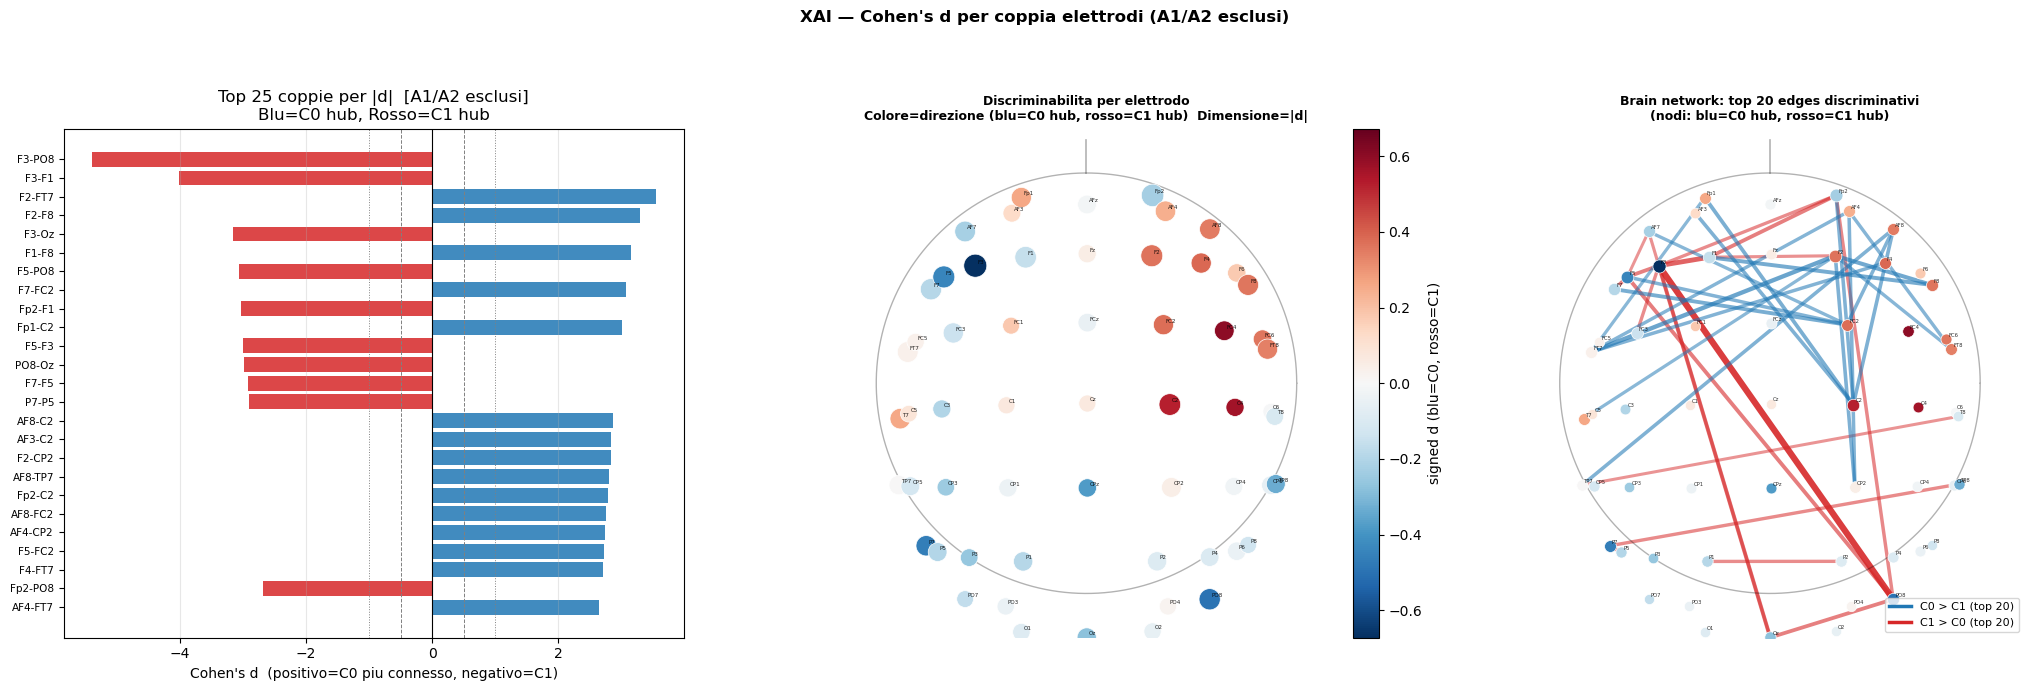


── Top 15 coppie piu discriminative [A1/A2 esclusi] ──
  # 1  F3   -PO8    d=-5.400  p=0.0000  -> C1  [Frontale x Occipitale]
  # 2  F3   -F1     d=-4.025  p=0.0000  -> C1  [Frontale x Frontale]
  # 3  F2   -FT7    d=+3.543  p=0.0000  -> C0  [Frontale x Fronto-centrale]
  # 4  F2   -F8     d=+3.289  p=0.0000  -> C0  [Frontale x Frontale]
  # 5  F3   -Oz     d=-3.159  p=0.0000  -> C1  [Frontale x Occipitale]
  # 6  F1   -F8     d=+3.152  p=0.0000  -> C0  [Frontale x Frontale]
  # 7  F5   -PO8    d=-3.074  p=0.0000  -> C1  [Frontale x Occipitale]
  # 8  F7   -FC2    d=+3.069  p=0.0000  -> C0  [Frontale x Fronto-centrale]
  # 9  Fp2  -F1     d=-3.032  p=0.0000  -> C1  [Frontale x Frontale]
  #10  Fp1  -C2     d=+3.009  p=0.0000  -> C0  [Frontale x Centrale]
  #11  F5   -F3     d=-3.006  p=0.0000  -> C1  [Frontale x Frontale]
  #12  PO8  -Oz     d=-2.987  p=0.0000  -> C1  [Occipitale x Occipitale]
  #13  F7   -F5     d=-2.921  p=0.0000  -> C1  [Frontale x Frontale]
  #14  P7   -P5     d=-

In [ ]:
# §17 — XAI: Cohen's d per coppia di elettrodi (A1/A2 esclusi)
from scipy.stats import ttest_ind

# Elettrodi da escludere: A1=E00, A2=E07 (mastoid reference, non EEG)
EXCLUDE_ELEC_D = {0, 7}

# Mapping regione cerebrale per elettrodo (0-based)
REGION_MAP = {
    'Frontale':       [1,2,3,4,5,6,8,9,10,11,12,13,14,15,48,56,57],
    'Fronto-centrale':[16,17,18,19,20,21,22,23,58],
    'Centrale':       [24,25,26,27,28,29,30,31,59],
    'Centro-parietale':[32,33,34,35,36,37,38,39,60],
    'Parietale':      [40,41,42,43,44,45,46,47],
    'Occipitale':     [49,50,51,52,53,54,55],
}
elec2region = {}
for reg, elecs in REGION_MAP.items():
    for e in elecs:
        elec2region[e] = reg
elec2region[0] = 'Mastoid'; elec2region[7] = 'Mastoid'

# Feature per cluster
mask_c0  = np.array([LABELS_G[SUBJ_G.index(s)] == 0 for s in SUBJ_G])
mask_c1  = np.array([LABELS_G[SUBJ_G.index(s)] == 1 for s in SUBJ_G])
feat_C0  = FEAT_G[mask_c0]
feat_C1  = FEAT_G[mask_c1]
n0, n1   = feat_C0.shape[0], feat_C1.shape[0]
log.info(f'feat_C0: {feat_C0.shape}  feat_C1: {feat_C1.shape}')

# Cohen's d vettorizzato
mean0  = feat_C0.mean(axis=0)
mean1  = feat_C1.mean(axis=0)
std0   = feat_C0.std(axis=0, ddof=1)
std1   = feat_C1.std(axis=0, ddof=1)
pooled = np.sqrt(((n0-1)*std0**2 + (n1-1)*std1**2) / (n0+n1-2))
d_vec  = (mean0 - mean1) / (pooled + 1e-12)
t_vec, p_vec = ttest_ind(feat_C0, feat_C1, axis=0, equal_var=False)

# Matrice d 61x61
rows_t2, cols_t2 = np.triu_indices(N_CHAN, k=1)
d_mat = np.zeros((N_CHAN, N_CHAN))
for feat_i, (r, ci_ch) in enumerate(zip(rows_t2, cols_t2)):
    d_mat[r, ci_ch] = d_vec[feat_i]
    d_mat[ci_ch, r] = d_vec[feat_i]

# Maschera: escludi coppie con A1/A2
valid_pair = np.array([
    r not in EXCLUDE_ELEC_D and c not in EXCLUDE_ELEC_D
    for r, c in zip(rows_t2, cols_t2)
])
d_vec_clean = d_vec.copy()
d_vec_clean[~valid_pair] = 0.0

d_mat_clean = np.zeros((N_CHAN, N_CHAN))
for feat_i, (r, ci_ch) in enumerate(zip(rows_t2, cols_t2)):
    if valid_pair[feat_i]:
        d_mat_clean[r, ci_ch] = d_vec[feat_i]
        d_mat_clean[ci_ch, r] = d_vec[feat_i]

# Discriminabilita per elettrodo (esclusi mastoid)
elec_discrim  = np.array([
    np.abs(d_mat_clean[e]).mean() if e not in EXCLUDE_ELEC_D else 0.0
    for e in range(N_CHAN)
])
elec_d_signed = np.array([
    d_mat_clean[e].mean() if e not in EXCLUDE_ELEC_D else 0.0
    for e in range(N_CHAN)
])

log.info(f'|d| max (clean): {np.abs(d_vec_clean).max():.3f}')
log.info(f'Coppie |d|>0.5: {(np.abs(d_vec_clean[valid_pair])>0.5).sum()}  |d|>1: {(np.abs(d_vec_clean[valid_pair])>1).sum()}')

# ── Plot A: top 25 coppie clean ──────────────────────────────────────────
top_n_d    = 25
clean_idx  = np.where(valid_pair)[0]
top_d_idx  = clean_idx[np.argsort(np.abs(d_vec_clean[clean_idx]))[::-1][:top_n_d]]
top_d_vals = d_vec_clean[top_d_idx]
pair_labels_d = [f'{CHAN_NAMES_MNE[rows_t2[i]]}-{CHAN_NAMES_MNE[cols_t2[i]]}' for i in top_d_idx]
colors_d      = ['#1f77b4' if v > 0 else '#d62728' for v in top_d_vals]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle("XAI — Cohen's d per coppia elettrodi (A1/A2 esclusi)", fontsize=12, fontweight='bold')

ax = axes[0]
bars = ax.barh(range(top_n_d), top_d_vals[::-1], color=colors_d[::-1], alpha=0.85)
ax.set_yticks(range(top_n_d))
ax.set_yticklabels(pair_labels_d[::-1], fontsize=7.5)
ax.axvline(0, color='black', lw=0.8)
for xv, ls in [(-0.5,'--'),(0.5,'--'),(-1,':'),(1,':')]:
    ax.axvline(xv, color='grey', lw=0.7, linestyle=ls)
ax.set_xlabel("Cohen's d  (positivo=C0 piu connesso, negativo=C1)")
ax.set_title(f"Top {top_n_d} coppie per |d|  [A1/A2 esclusi]\nBlu=C0 hub, Rosso=C1 hub")
ax.grid(axis='x', alpha=0.3)

# ── Plot B: topomap discriminabilita ─────────────────────────────────────
r_head = 0.095
th2    = np.linspace(0, 2*np.pi, 200)
ax2    = axes[1]
ax2.set_aspect('equal'); ax2.set_xlim(-0.115,0.115); ax2.set_ylim(-0.115,0.115); ax2.axis('off')
ax2.plot(r_head*np.cos(th2), r_head*np.sin(th2), 'k-', lw=1, alpha=0.3)
ax2.plot([0,0],[0.095,0.11], 'k-', lw=1.2, alpha=0.3)

# Scala colore: signed_d (C0=blu, C1=rosso) con dimensione=|discrim|
ev_lim = np.abs(elec_d_signed[topo_idx]).max() + 1e-10
sc2 = ax2.scatter(
    topo_pos[:,0], topo_pos[:,1],
    c=elec_d_signed[topo_idx],
    cmap='RdBu_r', vmin=-ev_lim, vmax=ev_lim,
    s=elec_discrim[topo_idx]/max(elec_discrim.max(),1e-10)*250+25,
    zorder=3, edgecolors='white', linewidths=0.5
)
plt.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.02, label="signed d (blu=C0, rosso=C1)")
for i, e_idx in enumerate(topo_idx):
    ax2.annotate(CHAN_NAMES_MNE[e_idx], topo_pos[i], fontsize=4,
                 xytext=(1.5,1.5), textcoords='offset points', alpha=0.85)
ax2.set_title("Discriminabilita per elettrodo\n"
              "Colore=direzione (blu=C0 hub, rosso=C1 hub)  Dimensione=|d|",
              fontsize=9, fontweight='bold')

# ── Plot C: brain network top edges clean ────────────────────────────────
from matplotlib.lines import Line2D as L2D
ax3 = axes[2]
TOP_D_EDGES = 20
ax3.set_aspect('equal'); ax3.set_xlim(-0.115,0.115); ax3.set_ylim(-0.115,0.115); ax3.axis('off')
ax3.plot(r_head*np.cos(th2), r_head*np.sin(th2), 'k-', lw=1, alpha=0.3)
ax3.plot([0,0],[0.095,0.11], 'k-', lw=1.2, alpha=0.3)

sorted_d_clean = np.argsort(d_vec_clean[clean_idx])
idx_c1_top = clean_idx[sorted_d_clean[:TOP_D_EDGES]]
idx_c0_top = clean_idx[sorted_d_clean[-TOP_D_EDGES:]]
d_abs_max  = np.abs(d_vec_clean[valid_pair]).max()

for feat_i_arr, col_e in [(idx_c1_top,'#d62728'),(idx_c0_top,'#1f77b4')]:
    for fi in feat_i_arr:
        ri, ci_ch2 = rows_t2[fi], cols_t2[fi]
        if ri not in orig2conn or ci_ch2 not in orig2conn:
            continue
        xi,yi = conn_pos[orig2conn[ri]]
        xj,yj = conn_pos[orig2conn[ci_ch2]]
        d_abs = abs(d_vec_clean[fi])
        ax3.plot([xi,xj],[yi,yj],'-',color=col_e,
                 alpha=float(0.2+0.7*(d_abs/d_abs_max)),
                 linewidth=float(0.5+4.0*(d_abs/d_abs_max)), zorder=1)

nc_map2 = plt.cm.RdBu_r
for e_idx in conn_idx:
    if e_idx in EXCLUDE_ELEC_D:
        continue
    x,y   = conn_pos[orig2conn[e_idx]]
    nv    = elec_d_signed[e_idx]
    c_nd  = nc_map2(0.5+0.5*nv/(ev_lim+1e-10))
    sz    = float(20+70*(elec_discrim[e_idx]/(elec_discrim.max()+1e-10)))
    ax3.scatter(x,y,s=sz,c=[c_nd],zorder=3,edgecolors='white',linewidths=0.5)
    ax3.annotate(CHAN_NAMES_MNE[e_idx],(x,y),fontsize=3.8,
                 xytext=(1.5,1.5),textcoords='offset points',alpha=0.8,zorder=4)
ax3.legend(
    handles=[L2D([0],[0],color='#1f77b4',lw=2.5,label=f'C0 > C1 (top {TOP_D_EDGES})'),
             L2D([0],[0],color='#d62728',lw=2.5,label=f'C1 > C0 (top {TOP_D_EDGES})')],
    fontsize=8, loc='lower right', framealpha=0.8
)
ax3.set_title(f'Brain network: top {TOP_D_EDGES} edges discriminativi\n(nodi: blu=C0 hub, rosso=C1 hub)',
              fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0,0,1,0.93])
plt.savefig(FIG_DIR/'eeg16b_cohens_d_xai_clean.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ranking pulito ────────────────────────────────────────────────────────
print("\n── Top 15 coppie piu discriminative [A1/A2 esclusi] ──")
for rank, fi in enumerate(top_d_idx[:15]):
    ri, ci_ch = rows_t2[fi], cols_t2[fi]
    reg_r = elec2region.get(ri,'?'); reg_c = elec2region.get(ci_ch,'?')
    winner = 'C0' if d_vec_clean[fi] > 0 else 'C1'
    print(f'  #{rank+1:2d}  {CHAN_NAMES_MNE[ri]:5s}-{CHAN_NAMES_MNE[ci_ch]:5s}  '
          f'd={d_vec_clean[fi]:+.3f}  p={p_vec[fi]:.4f}  -> {winner}'
          f'  [{reg_r} x {reg_c}]')

print('\n── Top 7 elettrodi piu discriminativi [A1/A2 esclusi] ──')
for e in np.argsort(elec_discrim)[::-1][:7]:
    if e in EXCLUDE_ELEC_D: continue
    direction = 'C0 hub' if elec_d_signed[e] > 0 else 'C1 hub'
    print(f'  {CHAN_NAMES_MNE[e]:5s}  mean|d|={elec_discrim[e]:.3f}  '
          f'signed_d={elec_d_signed[e]:+.3f}  [{direction}]  '
          f'regione={elec2region.get(e,"?")}')

# ── Analisi per regione ───────────────────────────────────────────────────
print('\n── Cohen\'s d medio per REGIONE (|d| medio su coppie intra+inter-regione) ──')
region_d = {}
for reg, elecs in REGION_MAP.items():
    vals = []
    for feat_i, (r, ci_ch) in enumerate(zip(rows_t2, cols_t2)):
        if r in elecs or ci_ch in elecs:
            if valid_pair[feat_i]:
                vals.append(abs(d_vec_clean[feat_i]))
    if vals:
        region_d[reg] = (np.mean(vals), np.max(vals))

for reg in sorted(region_d, key=lambda r: region_d[r][0], reverse=True):
    mean_d, max_d = region_d[reg]
    print(f'  {reg:20s}  mean|d|={mean_d:.3f}  max|d|={max_d:.3f}')


## §18 — Permutation test: Cohen's d per permutazione delle label cluster

**Problema del circular analysis**: il clustering è stato costruito sull'intera matrice adj
(1830 feature). Cohen's d è poi calcolato sulle singole coppie. Un reviewer potrebbe obiettare:
*"ovvio che trovi differenze — hai ottimizzato per trovarle."*

**Soluzione**: tenere fissi i valori di connettività per ogni soggetto e mescolare
casualmente le label C0/C1 5000 volte. Se il d osservato non emerge mai per caso
→ p_perm < 0.001 → il finding è genuino, non un artefatto di circular analysis.

**Nota**: il clustering NON è stato costruito su F3–PO8 specificamente, ma su tutte le 1830
feature. Il permutation test chiude l'obiezione dimostrando che la separazione su F3–PO8
è irriproducibile per caso, indipendentemente dal processo di clustering.

---

### Perché serve: il rischio di circular analysis

**Cosa hai fatto in ordine:**
```
1. FEAT_G: 73 soggetti × 1830 feature (medie adj per soggetto)
2. KMeans su FEAT_G → C0 e C1
3. Cohen's d su ogni coppia → F3-PO8 ha d=5.4
4. Conclusione: "F3-PO8 separa i due cluster"
```

**Il problema**: al passo 2, KMeans ha visto *tutte e 1830 le feature*, inclusa F3-PO8.
Al passo 3, misuri la separazione sugli stessi dati che hanno creato la separazione.
Il reviewer dice: *"ovvio che F3-PO8 separa C0 da C1 — KMeans ha usato F3-PO8 per costruirli.
Non stai scoprendo nulla, stai ridescrivendo l'input del tuo algoritmo."*

**Perché nel tuo caso il rischio è limitato**: KMeans lavora in 1830 dimensioni — nessuna
singola feature domina. Se togli F3-PO8 e rifai KMeans, ottieni probabilmente gli stessi cluster.
Ma il reviewer non lo sa senza una prova formale.

**Cosa fa il permutation test**: fissa i 73 valori di F3-PO8 (non li tocca).
Mescola solo le etichette C0/C1 casualmente 5000 volte.
Chiede: *"se assegno a caso i soggetti ai cluster, quanto spesso ottengo d ≥ 5.4 su F3-PO8?"*

Risposta: **mai** (0/5000). Questo dimostra che la separazione su F3-PO8 non è
una conseguenza banale dell'esistenza dei cluster — è una proprietà non-casuale della
struttura trovata da KMeans.

**Analogia**: dividi 73 persone in gruppi in base alla loro dieta completa (1830 alimenti).
Osservi che il gruppo A mangia molto più salmone (d=5.4).
Il reviewer: *"ovvio, il salmone era nella dieta."*
Il permutation test: *"ho diviso le stesse persone a caso 5000 volte — mai d=5.4 sul salmone.
La differenza emerge perché chi mangia salmone forma un cluster coerente, non per artefatto."*

**Risultato ottenuto**: 25/25 coppie `p < 0.001` → obiezione chiusa.

Permutazioni:   0%|          | 0/5000 [00:00<?, ?it/s]

── Permutation test (N=5000) — Top 25 coppie per |d| ──
  Rank        Coppia    d_obs   Dir    p_perm   Sig
  ----------------------------------------------------
  #  1     F3-PO5     -4.364   C1>    0.0002   ***
  #  2     Fz-F8       3.825   C0>    0.0002   ***
  #  3     F3-F1      -3.525   C1>    0.0002   ***
  #  4     Fz-F6       3.501   C0>    0.0002   ***
  #  5     F1-F6       3.320   C0>    0.0002   ***
  #  6     F7-FC1      3.157   C0>    0.0002   ***
  #  7    Fp1-C3       3.131   C0>    0.0002   ***
  #  8    AF8-C4       3.100   C0>    0.0002   ***
  #  9    AF8-C3       3.026   C0>    0.0002   ***
  # 10    AF8-FC1      3.021   C0>    0.0002   ***
  # 11    Fp2-C3       2.991   C0>    0.0002   ***
  # 12     Fz-CP5      2.950   C0>    0.0002   ***
  # 13    AF4-CP5      2.932   C0>    0.0002   ***
  # 14     F2-F8       2.853   C0>    0.0002   ***
  # 15    AF3-C3       2.833   C0>    0.0002   ***
  # 16     F5-FC1      2.832   C0>    0.0002   ***
  # 17    AF4-F8     

Nulla (plot):   0%|          | 0/5000 [00:00<?, ?it/s]

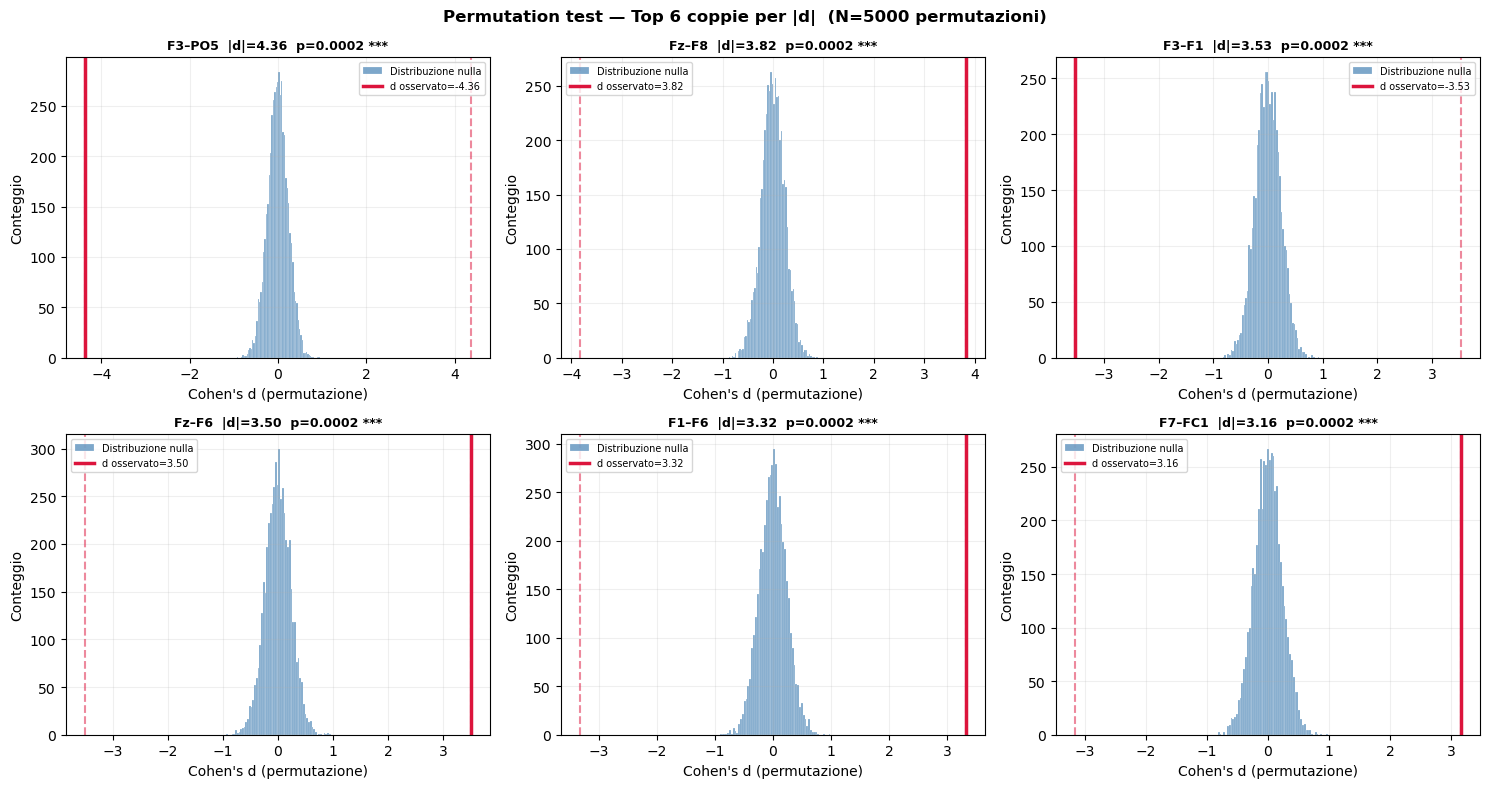

14:03:34 INFO     Salvato: eeg16b_permutation_test.png


In [ ]:
# §18 — Permutation test su top Cohen's d pairs (5000 permutazioni)
from scipy.stats import t as t_dist

N_PERM     = 5000
TOP_N_PERM = 25   # testa le prime 25 coppie per |d|

def cohen_d_fast(vals, labels, c0=0, c1=1):
    """Cohen's d (c0 vs c1) su vettore vals con label binarie."""
    x0 = vals[labels == c0]
    x1 = vals[labels == c1]
    n0, n1 = len(x0), len(x1)
    if n0 < 2 or n1 < 2:
        return 0.0
    s_pool = np.sqrt(((n0-1)*x0.std(ddof=1)**2 + (n1-1)*x1.std(ddof=1)**2) / (n0+n1-2))
    return (x0.mean() - x1.mean()) / (s_pool + 1e-12)

# ── Recupera dati e label da §17 ─────────────────────────────────────────────
# FEAT_G: (n_subj, 1830) — solo soggetti con label
common_s = [s for s in SUBJ_G if s in SUBJ_TOP]
feat_idx  = [SUBJ_G.index(s)   for s in common_s]
top_idx   = [SUBJ_TOP.index(s) for s in common_s]

X_perm    = FEAT_G[feat_idx]            # (n_common, 1830)
L_perm    = np.array([LABELS_TOP[i] for i in top_idx])   # (n_common,)

# ── Calcola d osservato per tutte le 1830 coppie ─────────────────────────────
d_obs_all = np.array([cohen_d_fast(X_perm[:, j], L_perm) for j in range(N_TRIU)])

# Top N per |d| osservato — solo coppie valide (A1/A2 escluse)
d_obs_valid = d_obs_all.copy()
d_obs_valid[~valid_pair] = 0.0   # azzera mastoid
top_pairs = np.argsort(np.abs(d_obs_valid))[-TOP_N_PERM:][::-1]

# ── Permutation test ──────────────────────────────────────────────────────────
rng = np.random.default_rng(42)
# Accumula: per ogni coppia top, quante permutazioni superano |d_obs|?
exceed_counts = np.zeros(TOP_N_PERM, dtype=int)

for _ in tqdm(range(N_PERM), desc='Permutazioni'):
    L_shuf = rng.permutation(L_perm)
    for k, pair_idx in enumerate(top_pairs):
        d_shuf = cohen_d_fast(X_perm[:, pair_idx], L_shuf)
        if abs(d_shuf) >= abs(d_obs_all[pair_idx]):
            exceed_counts[k] += 1

p_perm = (exceed_counts + 1) / (N_PERM + 1)   # +1 per evitare p=0 esatto

# ── Stampa risultati ──────────────────────────────────────────────────────────
CHAN_NAMES = ['A1','AF7','AF3','Fp1','Fp2','AF4','AF8',
              'A2','F7','F5','F3','F1','Fz','F2','F4','F6','F8',
              'FT7','FC5','FC3','FC1','FCz','FC2','FC4','FC6','FT8',
              'T7','C5','C3','C1','Cz','C2','C4','C6','T8',
              'TP7','CP5','CP3','CP1','CPz','CP2','CP4','CP6','TP8',
              'P7','P5','P3','P1','Pz','P2','P4','P6','P8',
              'PO7','PO5','PO3','POz','PO4','PO6','PO8',
              'O1','Oz','O2','CPz'][:N_CHAN]

print(f"── Permutation test (N={N_PERM}) — Top {TOP_N_PERM} coppie per |d| ──")
print(f"  {'Rank':>4}  {'Coppia':>12}  {'d_obs':>7}  {'Dir':>4}  {'p_perm':>8}  {'Sig':>4}")
print(f"  {'-'*52}")
for k, pair_idx in enumerate(top_pairs):
    r, c = triu_idx[0][pair_idx], triu_idx[1][pair_idx]
    cname_r = CHAN_NAMES[r] if r < len(CHAN_NAMES) else f'E{r:02d}'
    cname_c = CHAN_NAMES[c] if c < len(CHAN_NAMES) else f'E{c:02d}'
    direction = 'C1>' if d_obs_all[pair_idx] < 0 else 'C0>'
    sig = '***' if p_perm[k] < 0.001 else ('**' if p_perm[k] < 0.01 else ('*' if p_perm[k] < 0.05 else 'ns'))
    print(f"  #{k+1:3d}  {cname_r:>5}-{cname_c:<5}  {d_obs_all[pair_idx]:>7.3f}  {direction:>4}  {p_perm[k]:>8.4f}  {sig:>4}")

n_sig = (p_perm < 0.05).sum()
print(f"\n  Significative (p<0.05): {n_sig}/{TOP_N_PERM}")
print(f"  Significative (p<0.001): {(p_perm<0.001).sum()}/{TOP_N_PERM}")

# ── Plot: d osservato vs distribuzione nulla (per top 6 coppie) ──────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f'Permutation test — Top 6 coppie per |d|  (N={N_PERM} permutazioni)',
             fontsize=12, fontweight='bold')

# Ricalcola distribuzione nulla per top 6 (per il plot)
null_dists = [[] for _ in range(6)]
rng2 = np.random.default_rng(42)
for _ in tqdm(range(N_PERM), desc='Nulla (plot)', leave=False):
    L_shuf = rng2.permutation(L_perm)
    for k in range(6):
        null_dists[k].append(cohen_d_fast(X_perm[:, top_pairs[k]], L_shuf))

for k, ax in enumerate(axes.flat):
    pair_idx = top_pairs[k]
    r, c = triu_idx[0][pair_idx], triu_idx[1][pair_idx]
    cname_r = CHAN_NAMES[r] if r < len(CHAN_NAMES) else f'E{r:02d}'
    cname_c = CHAN_NAMES[c] if c < len(CHAN_NAMES) else f'E{c:02d}'
    d_obs_k = d_obs_all[pair_idx]
    null_k  = np.array(null_dists[k])

    ax.hist(null_k, bins=60, color='steelblue', alpha=0.7, edgecolor='white', lw=0.2,
            label='Distribuzione nulla')
    ax.axvline(d_obs_k,  color='crimson', lw=2.5, label=f'd osservato={d_obs_k:.2f}')
    ax.axvline(-abs(d_obs_k), color='crimson', lw=1.5, ls='--', alpha=0.5)
    ax.axvline(abs(d_obs_k),  color='crimson', lw=1.5, ls='--', alpha=0.5)

    sig_str = '***' if p_perm[k]<0.001 else ('**' if p_perm[k]<0.01 else ('*' if p_perm[k]<0.05 else 'ns'))
    ax.set_title(f'{cname_r}–{cname_c}  |d|={abs(d_obs_k):.2f}  p={p_perm[k]:.4f} {sig_str}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel("Cohen's d (permutazione)")
    ax.set_ylabel('Conteggio')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

plt.tight_layout()
fname = 'eeg16b_permutation_test.png'
plt.savefig(FIG_DIR / fname, dpi=130, bbox_inches='tight')
plt.show()
log.info(f'Salvato: {fname}')

## §22 — Export cluster labels per EEG_20

Salva `LABELS_H` e `SUBJ_H` su JSON per essere caricati da EEG_20.

In [ ]:
# §22 — Salva cluster labels su file per EEG_20
import json as _json

CLUSTER_EXPORT = {
    'subj_ids':   [int(s) for s in SUBJ_H],
    'labels':     [int(l) for l in LABELS_H],
    'cluster_names': CLUSTER_NAMES,
    'n_c0': int((LABELS_H == 0).sum()),
    'n_c1': int((LABELS_H == 1).sum()),
    'source': 'EEG_16b — ipergrafo sil=0.284',
}

export_path = project_root / 'configs' / 'eeg16b_cluster_labels.json'
export_path.parent.mkdir(exist_ok=True)
export_path.write_text(_json.dumps(CLUSTER_EXPORT, indent=2))
print(f'Salvato: {export_path}')
print(f'C0 ({CLUSTER_NAMES[0]}): {CLUSTER_EXPORT["n_c0"]} sogg')
print(f'C1 ({CLUSTER_NAMES[1]}): {CLUSTER_EXPORT["n_c1"]} sogg')
print('Soggetti C0:', sorted([s for s,l in zip(SUBJ_H, LABELS_H) if l==0]))
print('Soggetti C1:', sorted([s for s,l in zip(SUBJ_H, LABELS_H) if l==1]))


Salvato: /home/daniele_u/miralis-hypergraph-imagined-speech/configs/eeg16b_cluster_labels.json
C0 (Fronto-motor): 36 sogg
C1 (Fronto-occipital): 37 sogg
Soggetti C0: [0, 1, 4, 5, 7, 9, 12, 14, 16, 18, 19, 21, 25, 26, 28, 29, 30, 31, 33, 37, 39, 41, 42, 44, 45, 46, 49, 53, 57, 59, 61, 62, 64, 67, 71, 73]
Soggetti C1: [2, 3, 6, 8, 10, 11, 13, 15, 17, 20, 23, 24, 27, 32, 34, 35, 36, 38, 40, 43, 47, 48, 50, 51, 52, 54, 55, 56, 58, 60, 63, 65, 66, 68, 69, 70, 72]
